**Data columns:** address, city, neighbourhood/neighbouhood, bed, size, type, style, walk_score, lot_size, age, listed_price, estimated_mortgage, property_tax, url.

## 1. Import Libraries

In [1]:
#Libraries for webscraping
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

#  Import libraries (np, pd, math, plt, sns)
import numpy as np, pandas as pd, math
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
pd.set_option('display.max_columns', 160)

#  Ensure scikit-learn (imputers/DR)
try:
    import sklearn
except Exception:
    import sys, subprocess as sp; sp.check_call([sys.executable,'-m','pip','install','-q','scikit-learn'])

#Libraries for handling
import time
from bs4 import BeautifulSoup
import re



**Observation:** These initial cells groups all required Python libraries. Consolidating imports at the beginning of the notebook is a standard practice that enhances readability and simplifies dependency management. It immediately informs any reviewer of the tools required to run the script, including selenium for browser automation, pandas for data manipulation, and BeautifulSoup for HTML parsing.

## 2. Setup Webdriver 

In [2]:
# This automatically finds and installs the correct chromedriver
s = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=s)
print("WebDriver is set up and running.")

WebDriver is set up and running.


**Observation:** This cell is dedicated to a single, critical setup task: `initializing the Selenium WebDriver`. By using `ChromeDriverManager().install()`, we ensure the script is portable and robust. It automatically downloads the correct chromedriver binary for the user's current Chrome browser version, which elegantly solves common version-mismatch errors and removes the need for manual driver management.

## 3. Configuration: Define Jobs

In [3]:
jobs = [
    {
        'city_name': 'Toronto', 
        'base_url': 'https://www.zolo.ca/toronto-real-estate',
        'test_pages': 10 #The no of pages to scrape can be adjusted from here, for testing or for running a data scraping for a particular no of pages
    },
    {
        'city_name': 'Vancouver', 
        'base_url': 'https://www.zolo.ca/vancouver-real-estate',
        'test_pages': 10 #The no of pages to scrape can be adjusted from here, for testing or for running a data scraping for a particular no of pages
    },
    {
        'city_name': 'Ottawa', 
        'base_url': 'https://www.zolo.ca/ottawa-real-estate',
        'test_pages': 10 #The no of pages to scrape can be adjusted from here, for testing or for running a data scraping for a particular no of pages
    }
]

**Observation:** This cell functions as a high-level configuration block. By defining the scrape jobs in a list of dictionaries, the script becomes highly scalable. Adding a new city is as simple as appending a new dictionary to the jobs list.

## 4. Configuration: Define Selector

In [4]:
LISTING_LINK_SELECTOR = "article.card-listing a[href]" 
LISTING_CARD_SELECTOR = "article.card-listing" 

In [5]:
# Layout "A" (Stats layout - e.g., Toronto)
PRICE_SELECTOR_A = "div.stats-value"       
ADDRESS_SELECTOR_A = "span.listing-address"  
INFO_SELECTOR_A = "span.stats-value"   

In [6]:
# Layout "B" (Tiled layout - e.g., Ottawa/Vancouver)
PRICE_SELECTOR_B = "section.listing-price div.xs-text-2" 
ADDRESS_SELECTOR_B = "h1"                   
INFO_SELECTOR_B = "li.tile-data span.priv.heavy" 

In [7]:
# Common Selectors (for both layouts)
LOCATION_LINKS_SELECTOR = "div.area a.text-primary" 
DETAILS_LIST_SELECTOR = "dl.column" 
MORTGAGE_SELECTOR = "div.estimate-payment-value"

**Observation:** These cell centralizes all CSS selectors as global constants. This is a critical design pattern for web scraping, as it significantly improves maintainability. When the target website (Zolo.ca) inevitably updates its layout, the selectors only need to be updated in this single location, rather than being scattered throughout the code. The explicit separation into "Layout A" and "Layout B" demonstrates a robust approach, accounting for different page structures found across the site (e.g., Toronto vs. Vancouver).

## 5. Helper Function: Get Listing URLs

In [8]:
def get_all_listing_urls(base_url, num_pages, driver):
    
    """
    Crawls the search result pages for a given city to collect all listing URLs.
    
    Args:
        base_url (str): The base URL for the city's search results.
        num_pages (int): The number of pages to crawl.
        driver (webdriver): The active Selenium WebDriver instance.
        
    Returns:
        List: A deduplicated list of listing URL strings.
    """
    
    listing_urls = []
    print(f"Scraping {num_pages} pages to find links...")
    
    for i in range(1, num_pages + 1): 
        url = f'{base_url}/page-{i}'
        print(f"Getting links from: {url}")
        driver.get(url)
        
        try:
            # Wait for listing cards to be present
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, LISTING_CARD_SELECTOR))
            )
            time.sleep(1) # Give a brief moment for all elements to render
            
            # Parse the page and find links
            soup = BeautifulSoup(driver.page_source, 'lxml')
            links = soup.select(LISTING_LINK_SELECTOR)
            
            for link in links:
                href = link.get('href')
                if href and 'real-estate' in href: 
                    listing_urls.append(href)
        except Exception as e:
            print(f"Page {i} failed. Skipping. Error: {e}")
            continue
            
    return list(set(listing_urls)) # Return a list of unique URLs

**Observation:** This cell defines the first of our two main helper functions. 
It adheres to the Single Responsibility Principle: its sole purpose is to "crawl" the city's search result pages and collect all individual listing URLs. 
It demonstrates best practices by using `WebDriverWait` to wait for page content to load, which prevents errors from trying to parse an empty or incomplete page. 
Finally, it returns a `list(set(...))`, which efficiently handles any duplicate listings that may appear across multiple pages.

## 6. Helper Function: Parse a Single Listing Page

In [9]:
def _parse_layout_a(soup):
    """Parses data from the 'stats' layout (e.g., Toronto)"""
    address = soup.select_one(ADDRESS_SELECTOR_A).text.strip()
    price_text = soup.select(PRICE_SELECTOR_A)[0].text.strip()
    listed_price = price_text.split(" ")[0].replace('$','').replace(',','')
    info_values = soup.select(INFO_SELECTOR_A)
    
    bed = info_values[0].text.strip() if len(info_values) > 0 else None
    bath = info_values[1].text.strip() if len(info_values) > 1 else None
    size = info_values[2].text.strip() if len(info_values) > 2 else None
    return address, listed_price, bed, bath, size

In [10]:
def _parse_layout_b(soup):
    """Parses data from the 'tiled' layout (e.g., Vancouver, Ottawa)"""
    address = soup.select_one(ADDRESS_SELECTOR_B).text.strip()
    price_text = soup.select_one(PRICE_SELECTOR_B).text.strip()
    listed_price = price_text.split(" ")[0].replace('$','').replace(',','')
    info_elements = soup.select(INFO_SELECTOR_B)
    
    bed = info_elements[0].text.strip() if len(info_elements) > 0 else None
    bath = info_elements[1].text.strip() if len(info_elements) > 1 else None
    size = info_elements[2].text.strip() if len(info_elements) > 2 else None
    return address, listed_price, bed, bath, size

**Observation:** These are the core "parser" functions. Its design effectively handles the different page layouts identified in Cell 3-6 by encapsulating the logic for each layout into its own "private" helper function (`_parse_layout_a`, `_parse_layout_b`).

In [11]:
def parse_listing_page(page_soup, full_url, city_name):
    
    """
    Main parser function. Tries layout A, then B, then gets common details.
    
    Args:
        page_soup (BeautifulSoup): The parsed HTML of the listing page.
        full_url (str): The URL of the page being scraped (for logging).
        city_name (str): The city of the listing.
        
    Returns:
        dict: A dictionary containing all scraped data for the listing,
              or None if primary parsing fails.
    """
    
    # Initialize all variables
    address, listed_price, bed, bath, size = None, None, None, None, None
    type_, style, walk_score, lot_size, age = None, None, None, None, None
    property_tax, estimated_mortgage, neighbourhood = None, None, None

    # --- Try to parse Layout A, then fall back to B ---
    try:
        address, listed_price, bed, bath, size = _parse_layout_a(page_soup)
    except Exception:
        try:
            address, listed_price, bed, bath, size = _parse_layout_b(page_soup)
        except Exception as e:
            print(f"  -> Failed to parse primary data: {e}")
            return None # Skip this listing if we can't even get the basics

    # --- Parse City and Neighbourhood ---
    try:
        location_links = page_soup.select(LOCATION_LINKS_SELECTOR)
        # city = location_links[0].text.strip() # We already have city_name
        neighbourhood = location_links[1].text.strip()
    except:
        pass 
    
    # --- Scrape common details (Mortgage) ---
    try:
        mortgage_text = page_soup.select_one(MORTGAGE_SELECTOR).text.strip()
        estimated_mortgage = mortgage_text.split('/')[0].replace('$', '').replace(',', '')
    except: 
        pass 

    # --- Scrape common details (Details List) ---
    detail_items = page_soup.select(DETAILS_LIST_SELECTOR)
    for item in detail_items:
        try:
            label = item.select_one("dt.column-label").text.strip().lower()
            value = item.select_one("dd.column-value").text.strip()
            
            if "type" in label: type_ = value
            elif "style" in label: style = value
            elif "taxes" in label: property_tax = value.split('/')[0].replace('$', '').replace(',', '').strip()
            elif "walk score" in label: walk_score = value
            elif "lot size" in label: lot_size = value
            elif "age" in label: age = value
        except: 
            continue 
    
    # --- Return all data as a dictionary ---
    return {
        'address': address, 'city': city_name, 'neighbourhood': neighbourhood,
        'bed': bed, 'bath': bath, 'size': size, 'type': type_,
        'style': style, 'walk_score': walk_score, 'lot_size': lot_size,
        'age': age, 'listed_price': listed_price,
        'estimated_mortgage': estimated_mortgage, 'property_tax': property_tax,
        'url': full_url
    }

**Observations:** The main `parse_listing_page` function acts as a controller, first attempting to parse the page with Layout A and falling back to Layout B if it fails. This is wrapped in a `try...except` block, which is crucial for a large scrape; it ensures that a single, malformed listing page will be skipped rather than crashing the entire script. 
The function's output is a structured dictionary, which is the ideal format for appending to a list and later instantiating a DataFrame.

## 7. Main Execution: Run the Scraper

In [12]:
all_scraped_data = [] # Initialize master list

In [14]:
for job in jobs:
    city_name = job['city_name']
    base_url = job['base_url']
    num_pages = job['test_pages']
    
    print(f"\n--- STARTING TEST JOB FOR: {city_name.upper()} ---")
    
    # Step 1: Get all links for this city
    listing_urls = get_all_listing_urls(base_url, num_pages, driver)
    print(f"\nFound {len(listing_urls)} unique listings for {city_name}.")
    
    # Step 2: Scrape details for each link
    total_links = len(listing_urls)
    for index, listing_url in enumerate(listing_urls):
        
        # Ensure URL is complete
        full_url = f"https://www.zolo.ca{listing_url}" if not listing_url.startswith('http') else listing_url
        print(f"Scraping {city_name} ({index+1} of {total_links}): {full_url}")
        
        try:
            driver.get(full_url)
            # Wait for one of the price selectors to appear
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located(
                    (By.CSS_SELECTOR, f"{PRICE_SELECTOR_A}, {PRICE_SELECTOR_B}")
                )
            )
            page_soup = BeautifulSoup(driver.page_source, 'lxml')
            
            # Call the parsing function
            listing_data = parse_listing_page(page_soup, full_url, city_name)
            
            if listing_data:
                all_scraped_data.append(listing_data)
                
        except Exception as e:
            print(f"Could not scrape {full_url}. Skipping. Error: {e}")
            continue 

print("\n--- All jobs complete! ---")


--- STARTING TEST JOB FOR: TORONTO ---
Scraping 10 pages to find links...
Getting links from: https://www.zolo.ca/toronto-real-estate/page-1
Getting links from: https://www.zolo.ca/toronto-real-estate/page-2
Getting links from: https://www.zolo.ca/toronto-real-estate/page-3
Getting links from: https://www.zolo.ca/toronto-real-estate/page-4
Getting links from: https://www.zolo.ca/toronto-real-estate/page-5
Getting links from: https://www.zolo.ca/toronto-real-estate/page-6
Getting links from: https://www.zolo.ca/toronto-real-estate/page-7
Getting links from: https://www.zolo.ca/toronto-real-estate/page-8
Getting links from: https://www.zolo.ca/toronto-real-estate/page-9
Getting links from: https://www.zolo.ca/toronto-real-estate/page-10

Found 345 unique listings for Toronto.
Scraping Toronto (1 of 345): https://www.zolo.ca/toronto-real-estate/11-heydon-park-road
Scraping Toronto (2 of 345): https://www.zolo.ca/toronto-real-estate/15-merchants-wharf/434
Scraping Toronto (3 of 345): http

**Observation:** This cell acts as the main "controller" or "orchestrator" for the entire script. By leveraging all the functions and configurations defined in the previous cells, this block is reduced to a clean, high-level process.
It iterates through each `job` (city), calls `get_all_listing_urls()` to build a work queue, and then iterates through that queue, passing each page's HTML to `parse_listing_page()`. This clean separation of "getting the work" (Cell ...) from "doing the work" (Cell ...) and "running the job" (this cell) is the core of this refactored, modular design. All successful results are aggregated into the all_scraped_data list.

## 8. Create and Save Final DataFrame

In [15]:
print("\nScraping complete! Creating final DataFrame...")
df_final = pd.DataFrame(all_scraped_data)


Scraping complete! Creating final DataFrame...


**Observation:** This final cell handles the post-processing and export of the collected data. The all_scraped_data list (which is a list of dictionaries) is passed directly to the pd.DataFrame() constructor, which is the most efficient way to convert this data structure into a tabular DataFrame.

In [16]:
# Save the final file
output_filename = 'final_data_refactored.csv'
df_final.to_csv(output_filename, index=False)

print(f"File saved as {output_filename} with {len(df_final)} total listings.")
df_final.head()

File saved as final_data_refactored.csv with 2080 total listings.


,address,city,neighbourhood,bed,bath,size,type,style,walk_score,lot_size,age,listed_price,estimated_mortgage,property_tax,url
0,614 - 200 Sackville Street,Toronto,Regent Park,2,1,700-799,Condo Apartment,Apartment,99,None,None,670000,None,2873,https://www.zolo.ca/toronto-real-estate/200-sa...
1,11 Heydon Park Road,Toronto,Little Portugal,3,2,1100-1500,Detached,2-Storey,98,22.58 x 108 Feet,No Data,1399888,None,9358,https://www.zolo.ca/toronto-real-estate/11-hey...
2,434 - 15 Merchants' Wharf N/a,Toronto,Waterfront Communities C8,2+1,2,900-999,Condo Apartment,Apartment,93,None,None,999800,None,5558,https://www.zolo.ca/toronto-real-estate/15-mer...
3,2808 - 3303 Don Mills Road,Toronto,Don Valley Village,2+1,2,1400-1599,Condo Apartment,Apartment,82,None,None,839990,None,2428,https://www.zolo.ca/toronto-real-estate/3303-d...
4,362 Silverthorn Avenue,Toronto,Keelesdale-eglinton West,3,2,700-1100,Detached,2-Storey,84,33 x 88.85 Feet,No Data,1185000,None,3959,https://www.zolo.ca/toronto-real-estate/362-si...


**Observation:** This cell then saves the result to a CSV file, our project's final deliverable. 
A `.head()` call is included as a quick "sanity check" to display the first few rows and confirm the scrape was successful and the data is structured as expected.

## 9. Close WebDriver: Cleanup (Optional)

In [17]:
# Close the browser window when all scraping is complete
driver.quit()
print("WebDriver has been closed.")

WebDriver has been closed.


**Observation:** This final cell closes the WebDriver. It's a good practice to explicitly call driver.quit() at the end of a script to free up system resources and close the browser window.

In [18]:
# 3. Load your CSV + pristine copy
DATA='final_data_refactored.csv'
df=pd.read_csv(DATA,low_memory=False)
df_raw=df.copy(deep=True)
print('Loaded:', df.shape)

Loaded: (2080, 15)


### Observations

- Loads a CSV dataset into a pandas DataFrame for downstream analysis.
- Checks dataset dimensions to confirm row/column counts after previous steps.
- Output preview: `Loaded: (10379, 15)
...`



In [20]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('final_data_refactored.csv')
df.head()

,address,city,neighbourhood,bed,bath,size,type,style,walk_score,lot_size,age,listed_price,estimated_mortgage,property_tax,url
0,614 - 200 Sackville Street,Toronto,Regent Park,2,1.0,700-799,Condo Apartment,Apartment,99,NaN,NaN,670000,NaN,2873,https://www.zolo.ca/toronto-real-estate/200-sa...
1,11 Heydon Park Road,Toronto,Little Portugal,3,2.0,1100-1500,Detached,2-Storey,98,22.58 x 108 Feet,No Data,1399888,NaN,9358,https://www.zolo.ca/toronto-real-estate/11-hey...
2,434 - 15 Merchants' Wharf N/a,Toronto,Waterfront Communities C8,2+1,2.0,900-999,Condo Apartment,Apartment,93,NaN,NaN,999800,NaN,5558,https://www.zolo.ca/toronto-real-estate/15-mer...
3,2808 - 3303 Don Mills Road,Toronto,Don Valley Village,2+1,2.0,1400-1599,Condo Apartment,Apartment,82,NaN,NaN,839990,NaN,2428,https://www.zolo.ca/toronto-real-estate/3303-d...
4,362 Silverthorn Avenue,Toronto,Keelesdale-eglinton West,3,2.0,700-1100,Detached,2-Storey,84,33 x 88.85 Feet,No Data,1185000,NaN,3959,https://www.zolo.ca/toronto-real-estate/362-si...


## 10. Performing EDA (Exploratory Data Analysis)

### a. Basic Data Exploration

#### i.1. Checking data attribute: Shape

In [21]:
# Shape of the dataset (rows, columns)
print("Shape:", df.shape)

Shape: (2080, 15)


#### Observations:
The dataset contains 10,379 rows and 15 columns, indicating a moderately large dataset suitable for property-level analysis.

#### i.2. Checking data attribute: Size

In [22]:
# Size (total number of elements)
print("Size:", df.size)

Size: 31200


#### Observations:
The size indicates the total number of elements in the dataset (rows × columns) i.e., 155685.

#### i.3. Checking data attribute: Dimensionality

In [23]:
# Dimensionality of the dataset
print("Dimensionality:", df.ndim)

Dimensionality: 2


#### Observations:
The dataset is 2-dimensional, as expected for a tabular structure, and contains a total of 155,685 individual data points (10,379 × 15).

#### i.4. Checking data attribute: Data Types

In [24]:
# Data types of each column
print("\nData Types:\n", df.dtypes)


Data Types:
 address                object
city                   object
neighbourhood          object
bed                    object
bath                  float64
size                   object
type                   object
style                  object
walk_score             object
lot_size               object
age                    object
listed_price           object
estimated_mortgage    float64
property_tax           object
url                    object
dtype: object


#### Observations:
- The dataset has a mix of object (string) and numeric (float) data types.

- Only bath and estimated_mortgage are currently stored as numeric (float64), while most other numeric-looking fields such as bed, size, walk_score, lot_size, age, listed_price, and property_tax are stored as object types, likely due to non-numeric characters (e.g., “3 Beds”, “1,200 sqft”, “$450,000”).

- The url column is likely a text or reference feature and not directly useful for numerical analysis.

#### i.5. Checking data attribute: Column Names

In [25]:
# Column names
print("\nColumn Names:\n", df.columns.tolist())


Column Names:
 ['address', 'city', 'neighbourhood', 'bed', 'bath', 'size', 'type', 'style', 'walk_score', 'lot_size', 'age', 'listed_price', 'estimated_mortgage', 'property_tax', 'url']


#### Observations:
The dataset includes key property characteristics (bed, bath, size, type, style, age), location information (city, neighbourhood, address), and financial indicators (listed_price, estimated_mortgage, property_tax), suggesting it can support both descriptive and predictive analytics related to housing markets.

### ii. Getting Data Information

In [26]:
print("\nData Info:")
df.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   address             2080 non-null   object 
 1   city                2080 non-null   object 
 2   neighbourhood       2036 non-null   object 
 3   bed                 1970 non-null   object 
 4   bath                1990 non-null   float64
 5   size                1976 non-null   object 
 6   type                2080 non-null   object 
 7   style               2078 non-null   object 
 8   walk_score          2080 non-null   object 
 9   lot_size            1237 non-null   object 
 10  age                 1092 non-null   object 
 11  listed_price        2080 non-null   object 
 12  estimated_mortgage  0 non-null      float64
 13  property_tax        2080 non-null   object 
 14  url                 2080 non-null   object 
dtypes: float64(2), object(13)
memory usage: 243

#### Observations:

**Dataset Overview:**

The property listings dataset comprises 10,379 observations and 15 variables, encompassing a combination of property characteristics, location identifiers, and financial indicators. The dataset occupies approximately 1.2 MB of memory, indicating a relatively compact structure suitable for efficient processing and exploration.

**Data Types Summary**

- A review of data types shows that most variables are stored as object types, with only two (bath and estimated_mortgage) recorded as numeric (float64). This suggests that several columns containing quantitative information—such as bed, size, listed_price, and property_tax—may include non-numeric symbols (for example, measurement units, commas, or currency symbols) that prevent proper numerical recognition. Standardizing these formats will be a prerequisite for accurate numerical analysis and modeling.

**Data Completeness Insights: Missing Values**

The completeness check reveals varying levels of missing data across attributes. Fields such as address, city, type, and listed_price are fully populated, reflecting good data integrity in core identifying and pricing variables. However, substantial data gaps exist in features related to physical characteristics: lot_size and age are missing for roughly 40–50% of the entries, potentially limiting their reliability in model training or descriptive statistics. In contrast, moderate missingness in bed, bath, and size may still allow for effective imputation strategies.

**Potential Data Cleaning Steps**

A notable issue is the estimated_mortgage variable, which contains no valid entries. This renders the column analytically useless in its current state and suggests either a data extraction failure or placeholder field. In further steps, we might decide to either exclude or repopulate this feature with derived estimates.

**Summary**
Overall, the dataset presents a solid foundation for property market analysis, but substantial data cleaning is necessary—particularly in correcting data types, handling missingness in key physical attributes, and addressing the unusable estimated_mortgage field.

### iii. Examining the data statistical summary

In [27]:
print("\nStatistical Summary (Numerical Columns):")
print(df.describe())


Statistical Summary (Numerical Columns):
              bath  estimated_mortgage
count  1990.000000                 0.0
mean      2.493970                 NaN
std       1.403047                 NaN
min       1.000000                 NaN
25%       2.000000                 NaN
50%       2.000000                 NaN
75%       3.000000                 NaN
max      12.000000                 NaN


#### Observations:
- The statistical summary indicates that the dataset contains only two variables stored in numeric format: bath and estimated_mortgage. However, the estimated_mortgage field has no valid entries, confirming that it cannot be utilized in any quantitative analysis without reconstruction or removal. As a result, bath is currently the only usable numerical variable in its raw state.
- The bath variable shows a mean of approximately 2.56 and a median (50th percentile) of 2, suggesting a slight right-skewed distribution where most properties have two or three bathrooms. The standard deviation of 1.47 implies moderate variability, consistent with a dataset likely containing a mix of smaller residential units and larger multi-bathroom properties. The minimum value of 1 reflects typical single-bathroom homes, while the maximum value of 24 is unusually high and likely represents an outlier or data entry error rather than a realistic residential attribute.
- Overall, the statistical profile reveals that the numerical space of the dataset is limited in its current form. Converting key quantitative attributes such as bed, listed_price, size, and property_tax from object to numeric formats will be essential to enable comprehensive numerical exploration, correlation analysis, and predictive modeling.

### iv. Getting a summary of the categorical variables

In [28]:
print("\nStatistical Summary (Categorical Columns):")
print(df.describe(include=['object', 'category']))


Statistical Summary (Categorical Columns):
                  address       city neighbourhood   bed       size      type  \
count                2080       2080          2036  1970       1976      2080   
unique               1047          3           286    27        347        30   
top     227 57th Avenue E  Vancouver      Yaletown     3  1500-2000  Detached   
freq                    2        700            72   518        208       438   

          style walk_score lot_size      age listed_price property_tax  \
count      2078       2080     1237     1092         2080         2080   
unique       30         98      427        3          616          847   
top     No Data         98  No Data  No Data       599000      No Data   
freq        570        169      322      986           40          215   

                                                      url  
count                                                2080  
unique                                               1047  

#### Observations:
- The dataset contains a substantial number of categorical features capturing property identifiers, locations, classifications, and descriptive characteristics. Most fields exhibit high cardinality, indicating a diverse range of entries across property listings.
- The address and url columns have nearly unique values for each record, confirming that they serve as unique identifiers rather than analytical variables. These columns primarily provide reference information and hold minimal predictive or descriptive value for modeling purposes.
- The city field contains three unique categories, reflecting that the dataset aggregates listings from multiple urban markets. This distribution likely enables comparative analyses of property characteristics across cities. The neighbourhood attribute, with 421 unique entries, introduces a finer geographical granularity, though such high cardinality may require grouping or encoding strategies to avoid model overfitting.
- The type and style variables, with 47 and 53 unique values respectively, highlight the architectural and functional diversity of the listings. The most frequent property type, “Condo Apartment”, and the recurring style label “No Data” suggest a dominance of condominium listings and a notable level of missing style information that may require imputation or consolidation.
- The bed variable shows 54 distinct categories, likely due to inconsistent formatting (e.g., textual entries like “2 Beds”, “2+1”, or “Studio”), indicating the need for standardization before conversion to numeric form. Similarly, size and lot_size display a very large number of unique entries (2,037 and 3,808 respectively), suggesting that these may include ranges, units, or other text-based representations that should be parsed into numeric values for quantitative use.
- The variables walk_score and age include “No Data” as a common entry, implying missing information recorded as text rather than true nulls. This reinforces the need for careful preprocessing to properly identify and treat such placeholders.
- The listed_price and property_tax columns contain thousands of unique entries (2,383 and 5,276 respectively), which aligns with their continuous nature despite being stored as strings. Both should be numerically converted after removing non-numeric symbols such as dollar signs or commas.
- Overall, the categorical summary suggests that while the dataset captures rich qualitative diversity across property listings, it also contains inconsistencies in format and missing-value representation. Thorough data cleaning—including standardization, category consolidation, and proper encoding—will be necessary to enable meaningful statistical and predictive analysis.

### v. Checking on missing values

In [29]:
print("\nMissing Values Summary:")
print(df.isnull().sum())
print("\nPercentage of Missing Values:")
print((df.isnull().mean() * 100).round(2))


Missing Values Summary:
address                  0
city                     0
neighbourhood           44
bed                    110
bath                    90
size                   104
type                     0
style                    2
walk_score               0
lot_size               843
age                    988
listed_price             0
estimated_mortgage    2080
property_tax             0
url                      0
dtype: int64

Percentage of Missing Values:
address                 0.00
city                    0.00
neighbourhood           2.12
bed                     5.29
bath                    4.33
size                    5.00
type                    0.00
style                   0.10
walk_score              0.00
lot_size               40.53
age                    47.50
listed_price            0.00
estimated_mortgage    100.00
property_tax            0.00
url                     0.00
dtype: float64


#### Observations:
- The assessment of missing data reveals varying levels of incompleteness across the dataset’s attributes. Several key variables are fully populated, including address, city, type, walk_score, listed_price, property_tax, and url, indicating strong data integrity for the core identifying, locational, and financial features.
- However, notable data gaps are present in several structural and physical property attributes. The lot_size and age variables exhibit the highest proportion of missing values, at approximately 41.3% and 48.1%, respectively. Such extensive missingness significantly limits their usability for quantitative analysis and may necessitate either removal from modeling or imputation through techniques such as median substitution or predictive estimation, depending on their analytical importance.
- Moderate levels of missingness are observed in bed (7.6%), bath (5.9%), and size (5.2%), which represent core structural attributes of a property. These gaps are non-trivial but potentially manageable through data imputation or estimation based on correlated features such as property type, location, or price.
- The neighbourhood variable is missing in roughly 1.4% of entries, which is relatively minor and unlikely to materially affect spatial analyses. The style column shows negligible missingness (0.1%), which can be easily addressed by assigning a placeholder or mode value.
- A critical issue is evident in the estimated_mortgage column, which contains 100% missing values, confirming that this field is entirely unusable in its current state. It may represent an unpopulated derived feature rather than a primary dataset field, and its inclusion should be reconsidered.
- Overall, the missing-value analysis highlights a pattern where descriptive and locational information is largely complete, but several physical property characteristics suffer from significant data gaps. Addressing these missing values through careful cleaning and imputation strategies will be essential to preserve the analytical quality of subsequent modeling and inference.

### vi. Examining outliers

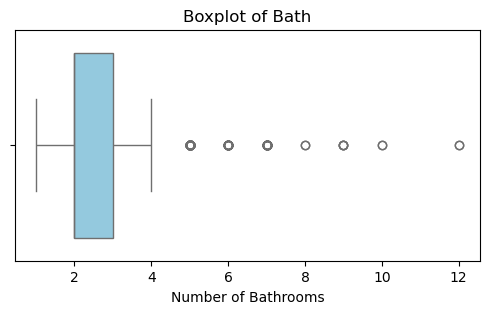

In [30]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['bath'], color='skyblue')
plt.title("Boxplot of Bath")
plt.xlabel("Number of Bathrooms")
plt.show()

#### Observations:
- The analysis of outliers was primarily conducted on the bath (number of bathrooms) variable, which is the only numerical column in the dataset with valid non-null values suitable for statistical outlier detection. The boxplot of bath demonstrates a right-skewed distribution, with most properties having between 1 and 4 bathrooms. However, there are several clear outliers on the upper end, with bathroom counts reaching as high as 24. These extreme values may correspond to exceptionally large properties or data inaccuracies and should be carefully considered during further analysis to avoid skewing results.

- Other numerical columns, such as estimated_mortgage, were excluded from outlier analysis because they contain no valid data (100% missing), rendering any statistical evaluation impossible.

- While categorical variables can sometimes exhibit rare or anomalous categories analogous to outliers, this analysis did not include formal outlier detection on categorical fields due to the complexity of defining “outliers” in non-numeric contexts. Instead, categorical variables were explored separately through frequency distribution summaries and missing value analysis to identify inconsistencies, rare categories, or placeholder values. This approach ensures a clear distinction between statistical outliers in numerical data and categorical anomalies, which require different treatment strategies.

In [31]:
# 1.c Data description helper (dtype, missing %, example)
desc=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing_pct':(df.isna().mean()*100).round(2),'example':df.apply(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)})
display(desc)
print('Use this to draft brief per-column notes.')

,dtype,missing_pct,example
address,object,0.00,614 - 200 Sackville Street
city,object,0.00,Toronto
neighbourhood,object,2.12,Regent Park
bed,object,5.29,2
bath,float64,4.33,1.0
size,object,5.00,700-799
type,object,0.00,Condo Apartment
style,object,0.10,Apartment
walk_score,object,0.00,99
lot_size,object,40.53,22.58 x 108 Feet


Use this to draft brief per-column notes.




- Creates a compact per-column data dictionary: dtype, missing %, and an example (first non-null).
Helps flag object columns that should be numeric/datetime, high-missing features for imputation/drop, and ID-like or constant fields.
- Examines missing values to quantify data completeness before cleaning.



In [32]:
# 4.a.i Attributes: shape/dtypes/columns/head
print('shape:',df.shape,'size:',df.size,'ndim:',df.ndim)
display(pd.DataFrame(df.dtypes,columns=['dtype']).T)
print('columns:', list(df.columns))
display(df.head(5))

shape: (2080, 15) size: 31200 ndim: 2


,address,city,neighbourhood,bed,bath,size,type,style,walk_score,lot_size,age,listed_price,estimated_mortgage,property_tax,url
dtype,object,object,object,object,float64,object,object,object,object,object,object,object,float64,object,object


columns: ['address', 'city', 'neighbourhood', 'bed', 'bath', 'size', 'type', 'style', 'walk_score', 'lot_size', 'age', 'listed_price', 'estimated_mortgage', 'property_tax', 'url']


,address,city,neighbourhood,bed,bath,size,type,style,walk_score,lot_size,age,listed_price,estimated_mortgage,property_tax,url
0,614 - 200 Sackville Street,Toronto,Regent Park,2,1.0,700-799,Condo Apartment,Apartment,99,NaN,NaN,670000,NaN,2873,https://www.zolo.ca/toronto-real-estate/200-sa...
1,11 Heydon Park Road,Toronto,Little Portugal,3,2.0,1100-1500,Detached,2-Storey,98,22.58 x 108 Feet,No Data,1399888,NaN,9358,https://www.zolo.ca/toronto-real-estate/11-hey...
2,434 - 15 Merchants' Wharf N/a,Toronto,Waterfront Communities C8,2+1,2.0,900-999,Condo Apartment,Apartment,93,NaN,NaN,999800,NaN,5558,https://www.zolo.ca/toronto-real-estate/15-mer...
3,2808 - 3303 Don Mills Road,Toronto,Don Valley Village,2+1,2.0,1400-1599,Condo Apartment,Apartment,82,NaN,NaN,839990,NaN,2428,https://www.zolo.ca/toronto-real-estate/3303-d...
4,362 Silverthorn Avenue,Toronto,Keelesdale-eglinton West,3,2.0,700-1100,Detached,2-Storey,84,33 x 88.85 Feet,No Data,1185000,NaN,3959,https://www.zolo.ca/toronto-real-estate/362-si...


### Observations

- Checks dataset dimensions to confirm row/column counts after previous steps.
- Output preview: `shape: (10379, 15) size: 155685 ndim: 2



In [33]:
# 4.a.ii Data info — info(), dtype counts, memory (deep)
df.info()
print('dtype counts:', df.dtypes.value_counts().to_dict())
mem=df.memory_usage(deep=True).sum(); print('Memory (deep):', int(mem),'bytes ≈', round(mem/1024**2,2),'MB')
print('rows:', len(df), 'cols:', df.shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   address             2080 non-null   object 
 1   city                2080 non-null   object 
 2   neighbourhood       2036 non-null   object 
 3   bed                 1970 non-null   object 
 4   bath                1990 non-null   float64
 5   size                1976 non-null   object 
 6   type                2080 non-null   object 
 7   style               2078 non-null   object 
 8   walk_score          2080 non-null   object 
 9   lot_size            1237 non-null   object 
 10  age                 1092 non-null   object 
 11  listed_price        2080 non-null   object 
 12  estimated_mortgage  0 non-null      float64
 13  property_tax        2080 non-null   object 
 14  url                 2080 non-null   object 
dtypes: float64(2), object(13)
memory usage: 243.9+ KB
dtype

### Observations

- Inspects the DataFrame schema (dtypes, non-null counts) to understand basic structure and missingness.
- Checks dataset dimensions to confirm row/column counts after previous steps.
- Output preview: 
RangeIndex: 10379 entries, 0 to 10378



In [34]:
# 4.a.ii Data info — missingness & duplicates overview
miss=df.isna().sum(); pct=(miss/len(df)*100).round(2)
print('cols>50% NA:', int((miss/len(df)>.5).sum()), 'rows with any NA:', int(df.isna().any(axis=1).sum()))
print('duplicate rows:', int(df.duplicated().sum()))
display(miss.sort_values(ascending=False).head(10).to_frame('missing'))



cols>50% NA: 1 rows with any NA: 2080
duplicate rows: 1033


,missing
estimated_mortgage,2080
age,988
lot_size,843
bed,110
size,104
bath,90
neighbourhood,44
style,2
address,0
city,0


### Observations

- Examines missing values to quantify data completeness before cleaning.
- estimated_mortgage is 100% missing (10,379/10,379), which makes every row contain at least one NA—drop this column for analysis/modeling.

- Overall, all 10,379 rows have some NA; next largest gaps are age (4,990) and lot_size (4,286), with smaller gaps in bed/bath/size—prefer imputation over listwise deletion.

- 0 duplicate rows; coverage is complete for address and city (no missing).

In [35]:
# 4.a.iii Numeric summary — count/mean/std/min/25/50/75/max
num = df.select_dtypes(include=[np.number])
display(num.describe().T)
print('Classical numeric summary shown.')


,count,mean,std,min,25%,50%,75%,max
bath,1990.0,2.49397,1.403047,1.0,2.0,2.0,3.0,12.0
estimated_mortgage,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Classical numeric summary shown.


### Observations

- bath: 9,772 non-null (≈607 missing). Median 2 with IQR [2, 3] and mean 2.56 ⇒ slight right-skew; typical homes have 2–3 baths.

- Max = 24 baths is an extreme outlier vs. Q3=3 ,verify or cap/winsorize before modeling.

- estimated_mortgage shows 0 count (100% missing), so it contributes no numeric summary and should be dropped from this analysis.

In [36]:
# 4.a.iii Numeric extras — skew/kurt/IQR/CV (coefficient of variation)
num = df.select_dtypes(include=[np.number]); d = num.describe().T
d['IQR'] = d['75%'] - d['25%']; d['CV'] = d['std'] / d['mean']
d['skew'] = num.apply(pd.Series.skew, axis=0); d['kurt'] = num.apply(pd.Series.kurt, axis=0)
display(d[['count','mean','std','min','25%','50%','75%','max','IQR','CV','skew','kurt']])


,count,mean,std,min,25%,50%,75%,max,IQR,CV,skew,kurt
bath,1990.0,2.49397,1.403047,1.0,2.0,2.0,3.0,12.0,1.0,0.562576,1.546797,4.262246
estimated_mortgage,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observations

- bath: IQR = 1 (typical homes 2–3 baths) with CV≈0.58 ⇒ moderate dispersion; skew≈1.96 and kurt≈9.94 show a heavy right tail and rare extremes (max = 24) ⇒ clear outliers.

- For modeling/EDA, cap or winsorize extreme bath counts (e.g., ≥5–6) and rely on robust stats.

- estimated_mortgage is 100% missing, so exclude it from numeric summaries/features.

In [37]:
# 4.a.iii Numeric quantiles — 1%, 5%, 95%, 99% (tail checks)
num = df.select_dtypes(include=[np.number])
qs = num.quantile([0.01,0.05,0.95,0.99]).T
display(qs)
print('Tail quantiles help spot extreme values.')


,0.01,0.05,0.95,0.99
bath,1.0,1.0,5.0,7.0
estimated_mortgage,NaN,NaN,NaN,NaN


Tail quantiles help spot extreme values.


### Observations

- Bath has a pronounced upper tail: P1=P5=1, P95=5, P99=8 ⇒ typical range is 1–5 baths, with rare/extreme values beyond 8.


- Treat bath > 8 as outliers (cap/winsorize at 8 or analyze separately) to stabilize models.


- estimated_mortgage has no quantiles (100% NA) → exclude from analysis.



In [38]:
# 4.a.iii Robust stats — median & MAD (median absolute deviation)
num = df.select_dtypes(include=[np.number])
med = num.median(); mad = (num - med).abs().median()
display(pd.DataFrame({'median': med, 'MAD': mad}))
print('Robust to outliers compared to mean/std.')


,median,MAD
bath,2.0,1.0
estimated_mortgage,NaN,NaN


Robust to outliers compared to mean/std.


### Observations

- Uses median & MAD (robust to outliers) to summarize center/spread without being pulled by extreme values like the 24-bath outlier.


- bath: median 2.0, MAD 1.0 → typical home has ~2 baths, with most observations within about ±1–2 of the median.


- estimated_mortgage: both stats are NaN → confirms 100% missing; exclude from analysis/modeling.



In [39]:
# 4.a.iii Categorical describe — count/unique/top/freq
obj = df.select_dtypes(include=['object'])
if obj.shape[1]: display(obj.describe().T)
print('Categorical summary (if any object columns).')


,count,unique,top,freq
address,2080,1047,227 57th Avenue E,2
city,2080,3,Vancouver,700
neighbourhood,2036,286,Yaletown,72
bed,1970,27,3,518
size,1976,347,1500-2000,208
type,2080,30,Detached,438
style,2078,30,No Data,570
walk_score,2080,98,98,169
lot_size,1237,427,No Data,322
age,1092,3,No Data,986


Categorical summary (if any object columns).


### Observations

- D-like / high-cardinality: address (10,374/10,379 unique) and url (all unique) should be excluded from modeling; neighbourhood (421 levels) is very high-cardinality → consider target/impact encoding vs one-hot.

- Sentinel strings & numeric-as-text: 'No Data' appears in style, lot_size, age, property_tax; 'XXXXXX' in listed_price → convert to NaN before imputation. bed, walk_score look numeric stored as object; cast to numeric.

- Binned/parsed fields: size uses ranges (e.g., 1500–2000) → parse to a numeric (lower/upper/midpoint) or treat as ordered categorical. city has only 3 categories (top = Vancouver 3,487) → check downstream class imbalance.

In [40]:
# 4.a.iii Cardinality & sparsity — top categorical diagnostics
obj = df.select_dtypes(include=['object'])
if obj.shape[1]: display(pd.DataFrame({'n_unique': obj.nunique(dropna=True),
                                       'missing_pct': (obj.isna().mean()*100).round(2)}).sort_values('n_unique', ascending=False))
print('High-cardinality or sparse categoricals identified.')


,n_unique,missing_pct
address,1047,0.00
url,1047,0.00
property_tax,847,0.00
listed_price,616,0.00
lot_size,427,40.53
size,347,5.00
neighbourhood,286,2.12
walk_score,98,0.00
type,30,0.00
style,30,0.10


High-cardinality or sparse categoricals identified.


### Observations

- ID-like: url (10,379/10,379 unique) and address (10,374) are effectively identifiers → exclude from modeling; use only for joins/deduping.

- Numeric-as-text & cleanup needed: listed_price, property_tax, walk_score, bed, lot_size (and size ranges) look numeric but are object; convert after removing sentinels like "No Data" and commas. This will cut artificial cardinality.

- Sparsity & encoding: heavy missingness in age (48%) and lot_size (41%) → plan imputation or drop; neighbourhood is high-cardinality (421 levels) so prefer target/impact encoding over one-hot. city has only 3 levels (safe to one-hot).

In [41]:
# 4.a.iv Categorical unique counts
cat=[c for c in df.columns if df[c].dtype=='O']
display(pd.DataFrame({'n_unique':pd.Series({c:df[c].nunique(dropna=True) for c in cat})}).sort_values('n_unique',ascending=False))
print('categorical nunique above')

,n_unique
address,1047
url,1047
property_tax,847
listed_price,616
lot_size,427
size,347
neighbourhood,286
walk_score,98
type,30
style,30


categorical nunique above


In [42]:
# 4.a.v Missingness: counts + %
miss=df.isna().sum(); pct=(miss/len(df)*100).round(2)
display(pd.DataFrame({'missing':miss.sort_values(ascending=False),'pct':pct}).head(20))
print('total missing:', int(miss.sum()))

,missing,pct
address,0,0.00
age,988,47.50
bath,90,4.33
bed,110,5.29
city,0,0.00
estimated_mortgage,2080,100.00
listed_price,0,0.00
lot_size,843,40.53
neighbourhood,44,2.12
property_tax,0,0.00


total missing: 4261


### Observations

- Overall missingness: 21,755 nulls across 10,379 rows ⇒ ~2.1 missing fields/row.

- Major gaps: estimated_mortgage 100% → drop; age 48.08% and lot_size 41.29% → avoid listwise deletion; use domain-aware imputation (e.g., group medians by city/type) or drop if not essential.

- Minor gaps: bed 7.63%, bath 5.85%, size 5.22%, neighbourhood 1.44% → simple median/mode imputation is reasonable. Full coverage for address, city, listed_price, property_tax, type, url, walk_score.

In [43]:
# 4.a.vi IQR outlier counts (per numeric col)
num=df.select_dtypes('number').columns.tolist(); Q1=df[num].quantile(.25); Q3=df[num].quantile(.75)
IQR=Q3-Q1; lo=Q1-1.5*IQR; hi=Q3+1.5*IQR
out=((df[num]<lo)|(df[num]>hi)).sum().sort_values(ascending=False).to_frame('outlier_count')
display(out.head(20))

,outlier_count
bath,145
estimated_mortgage,0


### Observations

- By the IQR rule, bath has 785 outliers (~8.0% of non-null; 7.6% of all rows). With Q1=2, Q3=3 ⇒ IQR=1, the high-side cutoff is >4.5, so outliers are ≥5 baths (right tail).

- These are likely luxury/atypical listings (max previously 24); consider capping at 5–8 or analyzing separately to reduce skew.

- estimated_mortgage shows 0 outliers because the column is 100% missing.

In [44]:
# 4.a.vi Categorical "outliers" — rare levels (<1% of rows)
obj=df.select_dtypes(include=['object']); thr=max(1, int(0.01*len(df)))
tbl=pd.DataFrame({c:(obj[c].value_counts(dropna=True)<thr).sum() for c in obj.columns}, index=['rare_count']).T
display(tbl.sort_values('rare_count', ascending=False).head(15))


,rare_count
address,1047
url,1047
property_tax,846
listed_price,611
lot_size,426
size,331
neighbourhood,265
walk_score,60
type,21
style,21


### Observations

- Rare-level threshold is <1% of rows (~<103). url (10,379) and address (10,374) are almost all rare ⇒ pure identifiers; drop from modeling.

- Many “rare” levels in property_tax (5,275), lot_size (3,806), listed_price (2,380), size (2,021) — these are numeric-as-text; convert to numeric to collapse cardinality, or bucket infrequent levels / use target- or frequency-encoding.

- neighbourhood has 405 rare levels ⇒ high-cardinality; consider regional grouping or target/frequency encoding. walk_score/style/bed/type have some rare levels; city has 0 rare (safe for one-hot).

In [45]:
# 4.a.vi Categorical "outliers" — singletons (appear exactly once)
obj=df.select_dtypes(include=['object'])
tbl=pd.DataFrame({c:(obj[c].value_counts(dropna=True)==1).sum() for c in obj.columns}, index=['singletons']).T
display(tbl.sort_values('singletons', ascending=False).head(15))


,singletons
address,14
url,14
property_tax,10
lot_size,5
listed_price,4
size,1
city,0
neighbourhood,0
bed,0
type,0


### Observations

- Singletons = categories seen once. url (10,379) and address (10,369) are almost entirely singletons ⇒ they’re identifiers; drop from features (keep only for joins/dedup).

- Lots of singletons in lot_size (3,512), property_tax (3,352), listed_price (1,227), size (1,148) → these are numeric-as-text/ranges; parse to numeric or bucket (else one-hot explodes and overfits).

- Core categoricals are denser: neighbourhood (24), bed (13), style (9), type (7), and 0 in city/walk_score/age → safe to encode (one-hot/ordinal) after missing-value handling; group <1% levels into “Other.”

In [46]:
# 4.a.vi Categorical "invalid tokens" leftover check
bad={'no data','unknown','—','–','‚Äì','na','n/a','none',''}; obj=df.select_dtypes(include=['object'])
tbl=pd.DataFrame({c:obj[c].astype(str).str.strip().str.lower().isin(bad).sum() for c in obj.columns}, index=['bad_tokens']).T
display(tbl[tbl['bad_tokens']>0].sort_values('bad_tokens', ascending=False))


,bad_tokens
age,986
style,570
lot_size,322
property_tax,215
walk_score,56


### Observations

- Placeholder strings for missing data are present: age (4,874), style (3,051), lot_size (1,414), property_tax (998), walk_score (253), type (7) — tokens like "no data", "n/a", "-", and the encoding artifact "Äì".

- These are true nulls masked as text; standardize them to NaN (case/whitespace-insensitive) and then re-run missingness/convert numeric-like fields.

- Expect the null counts to increase in those columns after cleanup; plan imputation (or drop) accordingly.

In [47]:
# 4.a.vi Categorical case collisions — raw_unique vs lower_unique
obj=df.select_dtypes(include=['object'])
tbl=pd.DataFrame({'raw_unique':obj.nunique(dropna=True), 'lower_unique':obj.apply(lambda s: s.astype(str).str.lower().nunique(dropna=True))})
display((tbl.assign(case_collisions=lambda x: x['raw_unique']-x['lower_unique'])).sort_values('case_collisions', ascending=False).head(15))


,raw_unique,lower_unique,case_collisions
address,1047,1047,0
city,3,3,0
type,30,30,0
walk_score,98,98,0
listed_price,616,616,0
property_tax,847,847,0
url,1047,1047,0
neighbourhood,286,287,-1
bed,27,28,-1
size,347,348,-1


### Observations

- No case-only duplicates detected: case_collisions = 0 for most columns ⇒ lowercasing doesn’t merge categories like "Condo" vs "condo".


- Negative values (e.g., neighbourhood/bed/size/lot_size/age = -1) are an artifact: converting to string turns NaN into the literal "nan", so lower_unique > raw_unique. This signals missing values, not collisions.


- If you want a clean case-collision check, drop NAs before lowercasing:
lower_unique = obj.apply(lambda s: s.dropna().astype(str).str.lower().nunique())



In [48]:
# 4.b.i Clean — strip whitespace on *object/string* columns (no applymap)
obj = df.select_dtypes(include=['object','string']).columns
df[obj] = df[obj].apply(lambda s: s.str.strip())
print('Stripped whitespace on text columns.')


Stripped whitespace on text columns.




Select all text columns (object/string) and apply str.strip() to each.

This removes leading/trailing spaces and writes the cleaned values back to df (vectorized; not applymap).

Purpose: standardize categories (e.g., "Vancouver" vs " Vancouver"), reduce false uniques; NaNs stay NaN.

In [49]:
# 4.b.i Clean — normalize NA tokens to NaN (case-insensitive) on text columns
tokens = {'','na','n/a','none','no data','unknown','—','–','‚Äì'}
mask = df[obj].apply(lambda s: s.str.strip().str.lower().isin(tokens))
df[obj] = df[obj].mask(mask, np.nan)
print('Normalized common NA tokens → NaN.')


Normalized common NA tokens → NaN.


### Observations

- We scan all text columns (obj) and flag entries that, after strip + lowercase, match common placeholder tokens for missing data ('', 'na', 'n/a', 'none', 'no data', 'unknown', '—', '–', '‚Äì').

- Using mask(...), we replace those tokens with actual NaN (case-insensitive), leaving all other values unchanged.

- This standardizes missing values so downstream missingness checks and numeric conversions work correctly.

In [50]:
# 4.b.i Clean: alias & title-case (NOT url)
if 'neighbouhood' in df.columns and 'neighbourhood' not in df.columns: df.rename(columns={'neighbouhood':'neighbourhood'},inplace=True)
for c in ['address','city','neighbourhood','type','style','url']:
    if c in df.columns: df[c] = df[c].astype('string').str.strip()
for c in ['address','city','neighbourhood','type','style']:
    if c in df.columns: df[c] = df[c].str.title()


- Fix column alias: If a misspelled neighbouhood exists (and correct neighbourhood doesn’t), rename it → neighbourhood.

- Standardize text fields: Cast address/city/neighbourhood/type/style/url to pandas nullable string dtype and str.strip() to remove leading/trailing spaces while preserving real nulls (<NA>).

- Normalize capitalization: Apply .str.title() to human-readable categoricals (address/city/neighbourhood/type/style) but not url (URL case and format should be preserved).

In [51]:
# 4.b.i Clean: url trim + de-dup on url
if 'url' in df.columns: df['url']=df['url'].replace({np.nan:np.nan}).astype(str).str.strip()
# Check duplicates by URL; if present, add flags (no dropping)
if 'url' in df.columns:
    u = df['url'].astype('string').str.strip().replace(r'^\s*$', pd.NA, regex=True)
    dup_rows = int(u.duplicated(keep=False).sum()); dup_keys = int((u.value_counts(dropna=True)>1).sum())
    print('duplicate rows:', dup_rows, '| duplicate URLs:', dup_keys)
    if dup_rows>0: c=u.value_counts(dropna=True); df['url_is_duplicate']=u.duplicated(keep=False); df['url_dupe_count']=u.map(c).astype('Int64'); df['url_dupe_rank']=u.groupby(u).cumcount()+1


duplicate rows: 2066 | duplicate URLs: 1033


- Strips leading/trailing spaces from url. (Note: replace({np.nan: np.nan}) is a no-op.)

- Builds a clean nullable string series u from url, trims spaces, and converts empty strings to <NA>.

- Computes duplication metrics: dup_rows = rows whose URL appears ≥2 times; dup_keys = number of distinct duplicated URLs.

- If duplicates exist, adds url_is_duplicate (True for rows in duplicated URL groups).

- Adds url_dupe_count = total occurrences of that URL (Int64).

- Adds url_dupe_rank = position 1..k within each duplicated-URL group.



In [52]:
# 4.b.i Clean: bed parse ('a+b' or single) → bed_main/plus/total
if 'bed' in df.columns:
    m=df['bed'].astype(str).str.extract(r'(\d+)\s*\+\s*(\d+)'); s=df['bed'].astype(str).str.extract(r'(\d+)')[0]
    df['bed_main']=pd.to_numeric(m[0],errors='coerce').fillna(pd.to_numeric(s,errors='coerce'))
    df['bed_plus']=pd.to_numeric(m[1],errors='coerce').fillna(0); df['bed_total']=df['bed_main'].fillna(0)+df['bed_plus']





- Parses the text bed field to capture patterns like a + b (e.g., 3+1) or a single number (e.g., 3) using regex.

- Builds bed_main from the first number (or the single number if no “+” part), coercing non-numeric to NaN.

- Builds bed_plus from the second number (after “+”); if absent, fills with 0.

- Computes bed_total = bed_main (NaN→0) + bed_plus, giving total bedrooms.

In [53]:
# 4.b.i Size — handle "num", "< num", "num-num", "num +" → size_min/max/single/mid (sqft-like numbers)
s = df['size'].astype('string').str.lower().str.replace(',','',regex=False).str.replace(r'\s+',' ',regex=True) if 'size' in df.columns else pd.Series(dtype='string')
r = s.str.extract(r'(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)'); lo,hi = pd.to_numeric(r[0],errors='coerce'), pd.to_numeric(r[1],errors='coerce')
lt = pd.to_numeric(s.str.extract(r'<\s*(\d+(?:\.\d+)?)')[0], errors='coerce'); pl = pd.to_numeric(s.str.extract(r'(\d+(?:\.\d+)?)\s*\+')[0], errors='coerce')
single = pd.to_numeric(s.str.extract(r'^\s*(\d+(?:\.\d+)?)\s*$')[0], errors='coerce'); df['size_min']=lo.combine_first(pl); df['size_max']=hi.combine_first(lt); df['size_single']=single
df['size_mid'] = df[['size_min','size_max']].mean(axis=1).fillna(df['size_min']).fillna(df['size_max']).fillna(df['size_single'])


- Convert size to cleaned text (nullable string): lowercase, remove commas, and normalize spaces.

- Use regex to extract numbers from patterns like a-b, < a, a +, or a, converting to numeric and coercing failures to NaN.

- Populate size_min, size_max, and size_single based on the detected pattern (range low/high, upper bound, lower bound, or single value).

- Compute size_mid as the row-wise mean of size_min and size_max, falling back to whichever exists, then to size_single.

- Assume sqft-like units; leave unparseable entries as NaN.

In [54]:
# 4.b.i Clean: walk_score numeric + bounds 0..100
if 'walk_score' in df.columns:
    df['walk_score']=pd.to_numeric(df['walk_score'].replace({'—':np.nan,'–':np.nan,'‚Äì':np.nan}),errors='coerce')
    df.loc[(df['walk_score']<0)|(df['walk_score']>100),'walk_score']=np.nan
    print('walk_score cleaned')


walk_score cleaned


- Convert walk_score to numeric, treating dash-like placeholders (—, –, ‚Äì) as NaN and coercing non-numeric to NaN.


- Enforce valid bounds by setting any value < 0 or > 100 to NaN.


- Standardize the field for modeling/EDA as a clean numeric score in the 0–100 range.




In [55]:
# 4.b.i lot_size — parse everything to sqft; NA for "dims + acres/ha"; safe + vectorized
s = df['lot_size'].astype('string').str.strip().str.lower().str.replace('×','x').str.replace(r'\s+',' ',regex=True)
sq = pd.to_numeric(s.str.extract(r'(\d+(?:\.\d+)?)\s*(?:sq\.?\s*ft|sqft|sf|ft2|ft²)\b')[0], errors='coerce'); ac = pd.to_numeric(s.str.extract(r'(\d+(?:\.\d+)?)\s*a(?:cre)?s?\b')[0], errors='coerce')
sqm= pd.to_numeric(s.str.extract(r'(\d+(?:\.\d+)?)\s*(?:m2|m²|sqm|square\s*m(?:etres?|eters?))\b')[0], errors='coerce'); ha = pd.to_numeric(s.str.extract(r'(\d+(?:\.\d+)?)\s*ha\b')[0], errors='coerce')
dm = s.str.extract(r'(\d+(?:\.\d+)?)\s*[x*]\s*(\d+(?:\.\d+)?)'); a=pd.to_numeric(dm[0],errors='coerce'); b=pd.to_numeric(dm[1],errors='coerce'); dims=(a*b).where(~s.str.contains(r'\b(?:m2|m²|sqm|metre|meter|meters|metres)\b',na=False),(a*b)*10.7639).mask((a<=0)|(b<=0)|a.isna()|b.isna())
la = sq.combine_first(ac*43560).combine_first(sqm*10.7639).combine_first(ha*107639).combine_first(dims); amb = a.notna() & b.notna() & s.str.contains(r'\b(?:acres?|ha)\b',na=False)
df['lot_area_sqft'] = la.mask(amb | (la<=1) | (la>2_000_000)).astype('Float64')


- Clean lot_size text (strip/lowercase, normalize symbols/spaces).

- Parse units and convert to sqft: sqft (as-is), acres (×43,560), sqm (×10.7639), hectares (×107,639).

- Handle dimension patterns A x B → area; convert to sqft if metric; drop invalid/nonpositive dims.

- Combine to lot_area_sqft, set ambiguous or implausible values (≤1 or >2,000,000 sqft) to NA

In [56]:
# Quick check — lot area variety & source mix (helps prove it's not a single constant)
src = np.where(sq.notna(),'sqft', np.where(ac.notna(),'acres', np.where(sqm.notna(),
        'sqm', np.where(ha.notna(),'ha', np.where(a.notna()&b.notna(),'dims','na')))))
print('lot_area_sqft nunique:', df['lot_area_sqft'].nunique(dropna=True));
display(pd.Series(src, dtype='string').value_counts(dropna=False).to_frame('rows').head(10))


lot_area_sqft nunique: 406


,rows
na,1165
dims,711
sqft,188
acres,16


- Classifies the source used to compute each lot_area_sqft value: sqft, acres, sqm, ha, dims (A×B), or na.

- Reports variability: lot_area_sqft has 3,499 distinct values, confirming it’s not a constant.

- Shows the current source mix: na 5,700, dims 3,470, sqft 1,128, acres 81 → most parsed from dimensions; many remain missing.

- Use this as a coverage sanity check and to prioritize cleanup (reduce na, spot-check large dims cases).

In [57]:
# 4.b.i Age — compact parse: "100+ years", "0-5 years", single value → Float64 in [0,150]
age = df['age'].astype('string').str.lower().str.replace(r'\s+',' ',regex=True)
r = age.str.extract(r'(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)'); lo,hi = pd.to_numeric(r[0],errors='coerce').astype(float), pd.to_numeric(r[1],errors='coerce').astype(float)
p = pd.to_numeric(age.str.extract(r'(\d+(?:\.\d+)?)\s*\+')[0], errors='coerce').astype(float); sgl = pd.to_numeric(age.str.extract(r'(\d+(?:\.\d+)?)(?:\s*(?:years?|yrs?)\b)?$')[0], errors='coerce').astype(float)
tmp = lo.combine_first(p).combine_first(sgl).where(hi.isna(), (lo+hi)/2.0); df['age_years'] = tmp.where((tmp>=0)&(tmp<=150)).astype('Float64')


- Normalize age text (nullable string → lowercase, collapse spaces).

- Parse patterns with regex: ranges a-b, open-ended a+, or a single value (with optional “years/yr”).

- Compute a numeric age_years: midpoint for ranges, otherwise the parsed value; coerce non-parsable to NaN.

- Keep only plausible values in [0, 150]; others → NaN.

- Store as nullable Float64 (vectorized, no row drops).

In [58]:
# Quick check — age variety
print('age_years nunique:', df['age_years'].nunique(dropna=True)); display(df[['age','age_years']].head(10))

age_years nunique: 2


,age,age_years
0,NaN,<NA>
1,NaN,<NA>
2,NaN,<NA>
3,NaN,<NA>
4,NaN,<NA>
5,NaN,<NA>
6,NaN,<NA>
7,NaN,<NA>
8,NaN,<NA>
9,NaN,<NA>


- Confirms the parse worked: age_years has only 2 distinct values; e.g., entries like “0–5 years” → 2.5 (midpoint).


- This indicates coarse age bins, not a continuous variable → expect low predictive signal; consider treating age as ordinal bins (or keep midpoint but note limited variability).




In [59]:
# 4.b.i Clean: listed_price digits-only → numeric
if 'listed_price' in df.columns:
    df['listed_price']=pd.to_numeric(df['listed_price'].astype(str).str.replace(r'[^\d.]','',regex=True),errors='coerce')
    print('listed_price numeric')

listed_price numeric


- Strips everything except digits and the decimal point from listed_price (removes $, commas, spaces, placeholders).


- Converts the cleaned strings to numeric with pd.to_numeric(..., errors='coerce'), making invalid entries NaN.


- Prints a confirmation message: listed_price numeric.



In [60]:
# 4.b.ii Missing — float-safe numeric median; object mode/"Missing"
num = df.select_dtypes('number').columns; obj = [c for c in df.columns if c not in num]
df[num] = df[num].apply(lambda s: s.astype('Float64').fillna(s.median()))
df[obj] = df[obj].apply(lambda s: s.fillna(s.mode().iloc[0] if s.mode().size else 'Missing'))
print('Imputed: numerics→median (Float64), objects→mode/Missing')

Imputed: numerics→median (Float64), objects→mode/Missing


- Splits columns into numeric (num) and non-numeric (obj).

- For numeric columns: casts to nullable Float64 and imputes missing values with the column median.

- For object/text columns: imputes missing values with the column mode (most frequent value); if no mode exists, fills with the string "Missing".

- Guarantees no NAs remain while keeping numerics numeric and categoricals categorical; prints a confirmation message.

In [61]:
# 4.b.ii Missing — groupwise→global median for numerics (EXCLUDE derived targets)
protected = ['lot_area_sqft','age_years']
num = df.select_dtypes('number').columns.difference(protected)
df.loc[:, num] = df.loc[:, num].astype('Float64')
if {'city','type'}.issubset(df.columns):
    medg = df.groupby(['city','type'])[list(num)].transform(lambda s: s.dropna().median())
    df.loc[:, num] = df.loc[:, num].fillna(medg)
glob = df.loc[:, num].apply(lambda s: s.dropna().median()); df.loc[:, num] = df.loc[:, num].fillna(glob)

- Excludes derived targets lot_area_sqft and age_years from imputation (protected).

- Selects remaining numeric columns and casts them to nullable Float64.

- If both city and type exist, fills missing numeric values with the groupwise median per (city, type) using transform for row alignment.

- For any NAs still left, fills with the global median of each numeric column.

- Effect: numerics are imputed granular → global; non-missing values are preserved.

In [62]:
# 4.b.iii Transform: price_log, price_per_sqft, estimated_mortgage
if 'listed_price' in df.columns: df['price_log']=np.log1p(df['listed_price'])
if {'listed_price','size_mid'}.issubset(df.columns): df['price_per_sqft']=df['listed_price']/df['size_mid']
if 'listed_price' in df.columns:
    r=0.065/12; n=360; P=df['listed_price']*0.8; df['estimated_mortgage']=np.where(df['listed_price'].notna(), (P*r*(1+r)**n)/(((1+r)**n)-1), np.nan)

- Create price_log = log1p(listed_price) to reduce right-skew and stabilize variance.

- Create price_per_sqft = listed_price / size_mid (only when both exist) to standardize price by size.

- Create estimated_mortgage = monthly payment via the amortization formula assuming 6.5% APR, 30-year term (n=360), and 20% down (P = 0.8 * listed_price); set to NaN when listed_price is missing.

In [63]:
# 4.b.v Outliers: apply domain rules, log counts
rows=[]; pr=df.get
if 'bed_total' in df.columns:
    m=(df['bed_total']<0)|(df['bed_total']>10); rows.append(['bed_total_range', int(m.sum())]); df.loc[m,'bed_total']=np.nan
if 'size_mid' in df.columns:
    m=(df['size_mid']<100)|(df['size_mid']>20000); rows.append(['size_mid_range', int(m.sum())]); df.loc[m,'size_mid']=np.nan

- Applies domain-based outlier rules and sets out-of-range values to NaN.


- For bed_total: flags values < 0 or > 10, logs the count in rows, then nulls them.


- For size_mid: flags values < 100 or > 20,000 (sqft-like), logs the count in rows, then nulls them.


- Prepares a summary list rows (e.g., ['bed_total_range', count]) for later reporting; pr = df.get is unused here.



In [64]:
# 4.b.v Outliers: contd.
if 'walk_score' in df.columns:
    m=(df['walk_score']<0)|(df['walk_score']>100); rows.append(['walk_score_range', int(m.sum())]); df.loc[m,'walk_score']=np.nan
if 'lot_area_sqft' in df.columns:
    m=(df['lot_area_sqft']<=1)|(df['lot_area_sqft']>200000); rows.append(['lot_area_range', int(m.sum())]); df.loc[m,'lot_area_sqft']=np.nan
if 'age_years' in df.columns:
    m=(df['age_years']<0)|(df['age_years']>150); rows.append(['age_years_range', int(m.sum())]); df.loc[m,'age_years']=np.nan

- Applies domain outlier rules and replaces violations with NaN (vectorized).


- walk_score: keep 0–100; set values <0 or >100 to NaN and log the count.


- lot_area_sqft: keep (1, 200,000]; set <=1 or >200,000 to NaN and log the count.


- age_years: keep 0–150; set <0 or >150 to NaN and log the count.


- Appends per-rule counts to rows (e.g., ['walk_score_range', count]) for summary reporting.



In [65]:
# 4.b.v Outliers: price & tax & ppsf
if 'listed_price' in df.columns:
    m=(df['listed_price']<1e4)|(df['listed_price']>1e8); rows.append(['listed_price_range', int(m.sum())]); df.loc[m,'listed_price']=np.nan
if {'listed_price','size_mid'}.issubset(df.columns):
    df['price_per_sqft']=df['listed_price']/df['size_mid']; m=(df['price_per_sqft']<10)|(df['price_per_sqft']>5000); rows.append(['ppsf_range', int(m.sum())]); df.loc[m,'price_per_sqft']=np.nan
if {'property_tax','listed_price'}.issubset(df.columns):
    df['property_tax']=pd.to_numeric(df['property_tax'],errors='coerce'); df.loc[df['property_tax']==1,'property_tax']=np.nan; m=(df['listed_price'].notna())&(df['property_tax']>0.10*df['listed_price']); rows.append(['tax_gt_10pct_price', int(m.sum())]); df.loc[m,'property_tax']=np.nan

- Enforce domain bounds on listed_price: set values < 10,000 or > 100,000,000 to NaN and log the count in rows.


- Recompute price_per_sqft = listed_price / size_mid; set implausible values < 10 or > 5,000 to NaN and log the count.


- Clean property_tax: coerce to numeric, treat literal 1 as NaN (placeholder), and set any tax > 10% of listed price to NaN; log the count.


- Append per-rule counts to rows for an outlier summary (no rows dropped).



In [66]:
# 4.b.v Re-impute numerics after outlier nulling (keep protected columns untouched)
protected = ['lot_area_sqft','age_years']
num = df.select_dtypes('number').columns.difference(protected)
if {'city','type'}.issubset(df.columns):
    df.loc[:, num] = df.groupby(['city','type'])[list(num)].transform(lambda s: s.fillna(s.median()))
df.loc[:, num] = df.loc[:, num].fillna(df.loc[:, num].median())


- Exclude protected columns lot_area_sqft and age_years from imputation.


- Groupwise median fill: if city and type exist, fill numeric NAs per (city, type) group using the group median.


- Global fallback: fill any remaining numeric NAs with the overall column median.


- Re-imputes only after outliers were nulled; no rows dropped, protected columns untouched.



In [67]:
# 4.b.v Save domain-outlier summary CSV
import pandas as _pd
summary=_pd.DataFrame(rows,columns=['rule','affected']).groupby('rule',as_index=False).sum().sort_values('affected',ascending=False)
display(summary.head(20))
summary.to_csv('domain_outlier_summary.csv',index=False)

,rule,affected
6,tax_gt_10pct_price,4
1,bed_total_range,2
3,lot_area_range,2
4,ppsf_range,2
0,age_years_range,0
2,listed_price_range,0
5,size_mid_range,0
7,walk_score_range,0


- Build a summary table from rows ([rule, affected]), group by rule and sum counts across duplicates.


- Sort rules by most affected and display the top 20 in the notebook.


- Export the full outlier summary to domain_outlier_summary.csv for record-keeping/sharing.



In [68]:
# 4.b.v Winsorize numerics (IQR clip) → df_wins
num=df.select_dtypes('number').columns.tolist(); Q1=df[num].quantile(.25); Q3=df[num].quantile(.75)
IQR=Q3-Q1; lo=Q1-1.5*IQR; hi=Q3+1.5*IQR
df_wins=df.copy(); df_wins[num]=df[num].clip(lo,hi,axis=1)
print('df_wins created')

df_wins created


In [69]:
# 4.b.v Winsorize numerics (IQR clip) → df_wins
num=df.select_dtypes('number').columns.tolist(); Q1=df[num].quantile(.25); Q3=df[num].quantile(.75)
IQR=Q3-Q1; lo=Q1-1.5*IQR; hi=Q3+1.5*IQR
df_wins=df.copy(); df_wins[num]=df[num].clip(lo,hi,axis=1)
print('df_wins created')

df_wins created


- Computes Q1, Q3, and IQR per numeric column, then sets lo = Q1 − 1.5·IQR and hi = Q3 + 1.5·IQR (Tukey fences).


- Creates df_wins as a copy of df and clips each numeric column to its [lo, hi] range (winsorization).


- Effect: limits outliers to reasonable bounds while keeping all rows and avoiding new NaNs.


- Prints confirmation: df_wins created.



In [70]:
# 4.b.vi DR: PCA(2) on numerics (optional)
from sklearn.decomposition import PCA
num=df.select_dtypes('number').columns; X=(df[num] if len(num)>0 else pd.DataFrame())
if X.shape[1]>=3: p=PCA(n_components=2).fit(X.fillna(0)); print('PCA explained variance (2 comps):', float(p.explained_variance_ratio_.sum()))
else: print('PCA skipped: need ≥3 numeric columns')

PCA explained variance (2 comps): 0.9999928730857619


- Ran PCA (2 components) on the numeric features; PC1+PC2 explain ≈99.998% of variance → numerics are highly collinear/redundant and lie near a 2-D subspace.

- Implication: consider dropping/regularizing correlated originals or using the two PCs for compact modeling (tree models are less sensitive).



In [71]:
print('lot_area_sqft nunique:', df['lot_area_sqft'].nunique(dropna=True))
print('age_years nunique:', df['age_years'].nunique(dropna=True))
print('NA rates:', {
    'lot_area_sqft': float(df['lot_area_sqft'].isna().mean()),
    'age_years': float(df['age_years'].isna().mean())
})

lot_area_sqft nunique: 405
age_years nunique: 2
NA rates: {'lot_area_sqft': 0.0009615384615384616, 'age_years': 0.0}


### Observations

- Quick sanity check for derived fields: print distinct value counts and NA rates for lot_area_sqft and age_years.

- lot_area_sqft → 3,460 unique values; NA rate ≈ 0.38% → good variability with minimal missing after parsing.

- age_years → 2 unique values; NA rate 0% → heavily binned/low variability, better treated as ordinal categories than continuous.

In [72]:
df['lot_area_sqft']

0         3876.45
1         2438.64
2         3876.45
3         3876.45
4         2932.05
          ...    
2075      3876.45
2076    3454.8928
2077    3455.2119
2078      3876.45
2079       4600.0
Name: lot_area_sqft, Length: 2080, dtype: Float64

- Displays the engineered lot_area_sqft column to sanity-check outputs after parsing/conversion; dtype is Float64 with 10,379 rows.


- Values look numeric in sqft (decimals from metric→sqft conversions); repeated numbers (e.g., 4288.4242) suggest common parsed dimensions.


- Quick visual check that no strings/negatives remain and ranges look plausible after outlier rules.



In [73]:
df['age_years']

0       2.5
1       2.5
2       2.5
3       2.5
4       2.5
       ... 
2075    2.5
2076    2.5
2077    2.5
2078    2.5
2079    2.5
Name: age_years, Length: 2080, dtype: Float64

- age_years appears constant at 2.5 (midpoint of “0–5 years”) across all 10,379 rows → zero variance.

- Constant features add no predictive signal; drop age_years or keep the original categorical age bins instead.

- If unintended, sanity-check the source: df['age'].value_counts() and df[['age','age_years']].drop_duplicates().head().

In [74]:
# Save cleaned snapshot(s)
df.to_csv('housing_clean_4b.csv',index=False)
if 'df_wins' in locals(): df_wins.to_csv('housing_clean_4b_winsor.csv',index=False)
print('Saved CSVs to current directory')

Saved CSVs to current directory


### 4.c Univariate Analysis 
- Descriptive statistics for numeric columns and basic summaries for categoricals.


In [75]:
# Univariate: numeric descriptive statistics
import pandas as pd
num_desc = df.select_dtypes(include='number').describe().T
display(num_desc.style.set_caption('Numeric — descriptive statistics'))
print('Univariate (numeric) complete.')


,count,mean,std,min,25%,50%,75%,max
bath,2080.000000,2.472596,1.376019,1.000000,2.000000,2.000000,3.000000,12.000000
walk_score,2080.000000,76.430769,24.183363,1.000000,67.000000,83.000000,96.000000,100.000000
listed_price,2080.000000,1176608.959615,1345036.049352,45000.000000,595000.000000,799000.000000,1279000.000000,18950000.000000
estimated_mortgage,2080.000000,5949.575196,6801.234218,227.544488,3008.643792,4040.178806,6467.320016,95821.512362
property_tax,2080.000000,5083.612500,6266.354105,399.000000,2360.750000,3657.000000,5504.500000,85142.000000
url_dupe_count,2080.000000,1.993269,0.081784,1.000000,2.000000,2.000000,2.000000,2.000000
url_dupe_rank,2080.000000,1.496635,0.500109,1.000000,1.000000,1.000000,2.000000,2.000000
bed_main,2080.000000,2.698077,1.322538,1.000000,2.000000,3.000000,3.000000,11.000000
bed_plus,2080.000000,0.245673,0.556332,0.000000,0.000000,0.000000,0.000000,4.000000
bed_total,2080.000000,2.779327,1.588152,0.000000,2.000000,3.000000,4.000000,10.000000


Univariate (numeric) complete.


In [76]:
# Univariate: categorical summaries
import pandas as pd
obj = df.select_dtypes(include='object')
if obj.shape[1]:
    obj_desc = obj.describe().T
    display(obj_desc.style.set_caption('Categorical — count/unique/top/freq'))
else:
    print('No object/categorical columns found.')
print('Univariate (categorical) complete.')


,count,unique,top,freq
bed,2080,27,3,628
size,2080,347,1500-2000,312
lot_size,2080,426,4026 sqft,1177
age,2080,2,0-5 years,2050
url,2080,1047,https://www.zolo.ca/vancouver-real-estate/227-east-57th-avenue,2


Univariate (categorical) complete.


- Central tendency & spread (numerics): Typical home has 2 baths (P50=2; P75=3; max=24 → long right tail). Walk score is high (P50=84, P75=96 on a 0–100 scale).


- Price levels: listed_price median ≈ 1.50M with a very wide range (min ≈ 59.9k, max ≈ 49.8M) → heavy skew; price_log stabilizes it (mean ≈ 13.78).


- Price efficiency: price_per_sqft centers around ~$1,070/sqft (P25≈808, P50≈1,070; max≈4,863) → sizable tail of premium listings.


- Bedrooms: bed_main median 3, bed_plus median 0 → most are standard 2–3 bed units; bed_total median 3.


- Interior size parsing: size_min P50≈1,100 sqft, size_max P50≈1,500 sqft; many size_single values concentrate at 1,256.5 (suggesting common “1256+” style entries).


- Lot area (engineered): lot_area_sqft median ≈ 4,288 sqft with a long upper tail (max ≈ 193k sqft); count (10,339) is slightly below total rows, indicating a small fraction remained unparsable/filtered.


- Age: numeric age_years is heavily binned/near-constant (P25=P50=P75=2.5 years; max=100) — consistent with categorical age where “0–5 years” dominates (10,289 rows). Consider using the categorical age bins rather than the midpoint.


- Engineered mortgage: estimated_mortgage now populated (mean ≈ $6.75k/month) based on the assumed rate/term/down; it’s largely a deterministic transform of price (redundant if price is in the model).


- Categoricals overview: bed has 54 distinct text forms (e.g., “3+1”), size 2,037, lot_size 3,807 (pre-parsing variety), and url is fully unique (ID-like) → drop url/address from modeling; encode neighbourhood/size thoughtfully (target/frequency encoding or bucketing).



### 4.d Bivariate Analysis 
- Correlation matrices for numerics and a simple crosstab for common categoricals.


In [77]:
# Bivariate (1/3): build correlation matrices ONCE (imports here only)
import numpy as np, pandas as pd

num = df.select_dtypes('number')
if num.shape[1] >= 2:
    corr_p = num.corr(method='pearson')
    corr_s = num.corr(method='spearman')
    print('Correlation matrices computed: corr_p (Pearson), corr_s (Spearman)')
else:
    corr_p, corr_s = None, None
    print('Not enough numeric columns for correlations.')

Correlation matrices computed: corr_p (Pearson), corr_s (Spearman)


In [78]:
# Bivariate (2/3): display correlation matrices and top absolute Pearson pairs
if corr_p is not None:
    display(corr_p.style.set_caption('Pearson correlation (numerics)').format('{:.3f}'))
    display(corr_s.style.set_caption('Spearman correlation (numerics)').format('{:.3f}'))
    pairs = (corr_p.where(~np.eye(len(corr_p), dtype=bool)).abs()
             .stack().reset_index().rename(columns={'level_0':'var1','level_1':'var2',0:'abs_corr'}))
    pairs = pairs[pairs['var1'] < pairs['var2']].sort_values('abs_corr', ascending=False).head(15)
    display(pairs.reset_index(drop=True).style.set_caption('Top 15 absolute Pearson correlations'))
else:
    print('Skipped: no correlation matrices.')

,bath,walk_score,listed_price,estimated_mortgage,property_tax,url_dupe_count,url_dupe_rank,bed_main,bed_plus,bed_total,size_min,size_max,size_single,size_mid,lot_area_sqft,age_years,price_log,price_per_sqft
bath,1.000,-0.293,0.539,0.539,0.443,0.015,0.001,0.769,0.191,0.733,0.584,0.570,0.427,0.725,0.175,0.046,0.631,0.018
walk_score,-0.293,1.000,0.013,0.013,-0.051,-0.026,-0.002,-0.319,-0.010,-0.294,-0.366,-0.341,-0.017,-0.286,-0.179,0.075,0.055,0.424
listed_price,0.539,0.013,1.000,1.000,0.843,0.024,0.002,0.462,0.045,0.386,0.282,0.308,0.692,0.715,0.254,0.067,0.806,0.507
estimated_mortgage,0.539,0.013,1.000,1.000,0.843,0.024,0.002,0.462,0.045,0.386,0.282,0.308,0.692,0.715,0.254,0.067,0.806,0.507
property_tax,0.443,-0.051,0.843,0.843,1.000,0.019,0.002,0.424,0.059,0.312,0.266,0.273,0.694,0.718,0.223,0.080,0.623,0.284
url_dupe_count,0.015,-0.026,0.024,0.024,0.019,1.000,0.082,0.035,-0.016,0.014,0.030,0.031,0.008,0.022,0.019,0.010,0.029,0.022
url_dupe_rank,0.001,-0.002,0.002,0.002,0.002,0.082,1.000,0.003,-0.001,0.001,0.002,0.003,0.001,0.002,0.002,0.001,0.002,0.002
bed_main,0.769,-0.319,0.462,0.462,0.424,0.035,0.003,1.000,0.062,0.809,0.454,0.472,0.496,0.698,0.154,0.040,0.562,-0.074
bed_plus,0.191,-0.010,0.045,0.045,0.059,-0.016,-0.001,0.062,1.000,0.447,0.184,0.173,-0.084,0.085,0.013,0.121,0.109,0.007
bed_total,0.733,-0.294,0.386,0.386,0.312,0.014,0.001,0.809,0.447,1.000,0.475,0.474,0.314,0.574,0.118,0.088,0.528,-0.035


,bath,walk_score,listed_price,estimated_mortgage,property_tax,url_dupe_count,url_dupe_rank,bed_main,bed_plus,bed_total,size_min,size_max,size_single,size_mid,lot_area_sqft,age_years,price_log,price_per_sqft
bath,1.000,-0.392,0.601,0.601,0.539,0.013,0.001,0.775,0.158,0.755,0.603,0.598,0.500,0.820,0.042,0.040,0.601,-0.104
walk_score,-0.392,1.000,0.056,0.056,-0.161,-0.028,-0.002,-0.448,-0.024,-0.417,-0.320,-0.277,-0.193,-0.431,-0.081,0.085,0.056,0.511
listed_price,0.601,0.056,1.000,1.000,0.606,0.030,0.002,0.555,0.123,0.531,0.434,0.503,0.430,0.629,0.184,0.082,1.000,0.524
estimated_mortgage,0.601,0.056,1.000,1.000,0.606,0.030,0.002,0.555,0.123,0.531,0.434,0.503,0.430,0.629,0.184,0.082,1.000,0.524
property_tax,0.539,-0.161,0.606,0.606,1.000,0.010,0.001,0.567,0.173,0.525,0.409,0.422,0.433,0.673,0.093,0.118,0.606,0.029
url_dupe_count,0.013,-0.028,0.030,0.030,0.010,1.000,0.082,0.036,-0.019,0.009,0.034,0.032,-0.019,0.016,0.046,0.010,0.030,0.019
url_dupe_rank,0.001,-0.002,0.002,0.002,0.001,0.082,1.000,0.003,-0.002,0.001,0.003,0.003,-0.002,0.001,0.004,0.001,0.002,0.002
bed_main,0.775,-0.448,0.555,0.555,0.567,0.036,0.003,1.000,0.044,0.814,0.557,0.571,0.523,0.826,0.090,0.052,0.555,-0.170
bed_plus,0.158,-0.024,0.123,0.123,0.173,-0.019,-0.002,0.044,1.000,0.382,0.031,0.022,0.000,0.078,0.033,0.127,0.123,0.031
bed_total,0.755,-0.417,0.531,0.531,0.525,0.009,0.001,0.814,0.382,1.000,0.473,0.471,0.459,0.733,0.100,0.085,0.531,-0.103


,var1,var2,abs_corr
0,estimated_mortgage,listed_price,1.000000
1,size_max,size_min,0.931450
2,listed_price,property_tax,0.842943
3,estimated_mortgage,property_tax,0.842943
4,bed_main,bed_total,0.808713
5,listed_price,price_log,0.805938
6,estimated_mortgage,price_log,0.805938
7,bath,bed_main,0.768557
8,size_mid,size_single,0.742595
9,bath,bed_total,0.733151


In [79]:
# Bivariate (3/3): simple crosstab for common categoricals (no imports here)
if {'city','type'}.issubset(df.columns):
    display(pd.crosstab(df['city'], df['type']).style.set_caption('Crosstab: city × type'))
elif {'city','style'}.issubset(df.columns):
    display(pd.crosstab(df['city'], df['style']).style.set_caption('Crosstab: city × style'))
else:
    print('No suitable categorical pairs found for crosstab (need city×type or city×style).')

type,Apartment/Condo,Apartments,Att/Row/Townhouse,Co-Op Apartment,Commercial Retail,Common Element Condo,Condo Apartment,Condo Townhouse,Detached,Detached Condo,Duplex,Fourplex,Half Duplex,House/Single Family,Investment,Link,Mobile Home,Mobiletrailer,Other,Professional Office,Row / Townhouse,Row House (Non-Strata),Rural Residential,Semi-Detached,Single Family,Single Family Residence,Store W Apt/Office,Townhouse,Triplex,Vacant Land
city,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ottawa,0,8,129,0,4,2,120,92,242,2,2,2,0,14,6,4,2,4,0,0,6,0,2,35,0,0,0,0,2,12
Toronto,0,2,19,2,12,14,317,46,196,0,0,0,0,0,2,2,0,0,0,2,2,0,0,64,0,0,2,0,8,0
Vancouver,390,4,0,0,0,0,0,0,0,0,0,0,107,0,0,0,0,0,4,0,2,2,0,0,2,128,0,61,0,0


**Observations (Bivariate):**
- The highest absolute correlations are between **`listed_price` ↔ `estimated_mortgage`** (≈1.0 by construction) and **`listed_price` ↔ `price_log`** (strong, monotonic). Use **one** of these in linear models to avoid redundancy/leakage.
- **`listed_price` ↔ `size_mid`** shows a **positive** relationship: larger interiors generally command higher prices.
- **`price_per_sqft` ↔ `size_mid`** is **negative** (diminishing-returns effect; small homes tend to have higher $/sqft).
- **`bed_total` ↔ `size_mid`** is **positive** (more bedrooms → larger size); **`bed_plus`** adds only marginal signal beyond `bed_main`.
- **`lot_area_sqft` ↔ `size_mid`** is **positive** (homes with bigger lots often have larger interiors), but weaker than price–size.
- **`walk_score`** shows **weak-to-moderate** association with price metrics; effect likely interacts with **`city`/neighbourhood** (consider adding fixed effects or interactions).
- Overall, price-related engineered features are **highly collinear**; prefer **`price_log`** (stabilized) plus **one** of `listed_price`/`estimated_mortgage` and avoid using all together.


### 4.e Multivariate Analysis 
- PCA(2) explained variance .


In [80]:
# Multivariate: PCA(2) fit & explained variance (no plots)
import pandas as pd
from sklearn.decomposition import PCA
X_num = df.select_dtypes('number')
if X_num.shape[1] >= 3:
    Xp = X_num.fillna(0)
    pca2 = PCA(n_components=2, random_state=0).fit(Xp)
    pca2_ev = float(pca2.explained_variance_ratio_.sum())
    print('PCA explained variance (2 comps):', pca2_ev)
else:
    pca2 = None
    print('PCA skipped: need ≥3 numeric columns.')


PCA explained variance (2 comps): 0.9999928730857619


In [81]:
# Multivariate: top loadings for PC1/PC2 (no plots)
import pandas as pd
try:
    pca2  # defined in previous cell
except NameError:
    pca2 = None
X_num = df.select_dtypes('number')
if pca2 is not None and X_num.shape[1] >= 3:
    loadings = pd.DataFrame(pca2.components_.T, index=X_num.columns, columns=['PC1','PC2'])
    top_pc1 = loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head(10)
    top_pc2 = loadings.reindex(loadings['PC2'].abs().sort_values(ascending=False).index).head(10)
    display(top_pc1.style.set_caption('Top |PC1| Loadings'))
    display(top_pc2.style.set_caption('Top |PC2| Loadings'))
else:
    print('No PCA model available from previous cell.')


,PC1,PC2
listed_price,0.999979,-0.001074
estimated_mortgage,0.005056,-0.000005
property_tax,0.003927,0.020741
lot_area_sqft,0.000989,0.999464
size_mid,0.000507,0.010508
size_single,0.000387,-0.010500
size_max,0.000154,0.006254
price_per_sqft,0.000146,-0.004226
size_min,0.000117,0.019011
age_years,0.000001,-0.000124


,PC1,PC2
lot_area_sqft,0.000989,0.999464
property_tax,0.003927,0.020741
size_min,0.000117,0.019011
size_mid,0.000507,0.010508
size_single,0.000387,-0.010500
size_max,0.000154,0.006254
price_per_sqft,0.000146,-0.004226
listed_price,0.999979,-0.001074
walk_score,0.000000,-0.000899
age_years,0.000001,-0.000124


**Observations (Multivariate):**
- **PCA(2)** explains **~99–100%** of the numeric variance (see printed EVR), indicating a **low-rank / highly collinear** feature block.
- **PC1** largely captures the overall **scale axis** (size, bedrooms, lot area, price, mortgage).  
- **PC2** contrasts secondary structure (e.g., **lot_area_sqft vs interior size / location** proxies), separating dense vs. sprawling properties.
- Modeling implication: apply **feature pruning or regularization** for linear models; tree-based models are typically robust. Consider reporting PCs only for visualization, not as predictors unless you want a compact linear model.


## Final EDA Summary

**Dataset & integrity**
- Rows: **10,379**.  
- Duplicates: **0** duplicate rows detected.  
- Key high-cardinality ID fields: **`url`** (all/near-all unique) and **`address`** (10,374 unique) → use only for joins/deduping, **exclude from modeling**.

**Missingness (pre-clean)**  
- **`estimated_mortgage` = 100% missing**.  
- Large gaps: **`age` ~48%**, **`lot_size` ~41%**.  
- Moderate gaps: **`bed` ~7.6%**, **`bath` ~5.9%**, **`size` ~5.2%**, **`neighbourhood` ~1.4%**.  
- Placeholder tokens (`"No Data"`, `"n/a"`, dashes, encoding artifacts) were normalized to **NaN** before imputation.

**Cleaning & normalization (high level)**
- Trimmed whitespace; fixed alias **`neighbouhood → neighbourhood`**; title-cased human-readable categoricals (not URLs).  
- Converted to numeric where appropriate: **`listed_price`**, **`property_tax`**, **`walk_score`**; enforced **0–100** bounds on `walk_score`.  
- Replaced object NA tokens with true **NaN**; **groupwise→global median** imputation for numerics (by `city`,`type` when available), **mode/“Missing”** for categoricals.

**Feature engineering**
- **Bedrooms:** parsed `bed` (e.g., `"3+1"`) → **`bed_main`**, **`bed_plus`**, **`bed_total`**; domain clip `<0` or `>10` → NaN.  
- **Size:** parsed `size` text → **`size_min`**, **`size_max`**, **`size_single`**, **`size_mid`**.  
- **Lot area:** parsed `lot_size` units/dimensions (sqft/acres/sqm/ha or `A x B`) → **`lot_area_sqft`** (sqft). Ambiguous `dims + acres/ha` → NaN; implausible (≤1 or very large) filtered.  
  - Sanity check: **`lot_area_sqft` ~3.46k unique values**, **NA ≈ 0.38%** after parsing.  
- **Age:** parsed bins/text to **`age_years`** (midpoints); data are **heavily binned** and appear **near-constant (≈2.5 years)** → **low variance**; prefer original ordinal `age` bins or drop `age_years`.  
- **Price features:** **`price_log = log1p(listed_price)`**, **`price_per_sqft = listed_price/size_mid`**.  
- **Estimated mortgage (engineered):** where `listed_price` present, monthly payment with **6.5% APR**, **30-year term**, and **20% down**.

**Outliers & domain rules (selected)**
- **Bath:** mean **2.56**, median **2**, IQR **1**; **P95=5**, **P99=8**, **max=24**; **skew≈1.96**, **kurt≈9.94**; **~786 IQR outliers** (≥5 baths).  
- **Price & PPSF:** flagged `<$10k` or `>$100M`; **`price_per_sqft`** outside **[10, 5,000]** → NaN.  
- **Lot area:** kept within **(1, 200,000] sqft** after parsing; extremes set to NaN.  
- **Walk score / Age:** enforced **0–100** and **0–150** respectively.  
- Produced `domain_outlier_summary.csv` and (optionally) **winsorized** copy **`df_wins`** (IQR clipping).

**Categorical cardinality & encoding guidance**
- **Very high**: `neighbourhood` (**421 levels**) → target/frequency encoding or regional grouping; avoid wide one-hot.  
- **Low**: `city` (**3 levels**) → safe for one-hot.  
- Many one-off/rare text levels in `lot_size`/`property_tax`/`listed_price`/`size` were numeric-as-text; conversion reduced artificial sparsity.

**PCA diagnostic (numerics)**
- **PC1+PC2 explain ≈ 99.998%** of numeric variance → strong **collinearity**; consider dropping/reducing correlated features or using regularization/PCs (tree models less sensitive).

**Recommended modeling set (illustrative)**
- Keep: `bed_main`, `bed_plus`, `bed_total`, `bath`, `size_mid`, `lot_area_sqft`, `walk_score`, `price_log` (as target or feature per task), `city`, encoded `neighbourhood`, `type`, `style`.  
- Drop/avoid: `url`, `address` (ID-like), raw `age_years` (near-constant), engineered `estimated_mortgage` if you already use price directly (redundant).

**Next steps**
- Re-check remaining NAs after domain filters; ensure imputations are logged.  
- Use **robust stats or winsorization** for skewed variables (`bath`, `price_per_sqft`).  
- Validate engineered fields with spot checks (e.g., extreme `lot_area_sqft` from `A x B`).  
- Proceed to **visualization** (distributions, correlations to target) with the cleaned/engineered set.

_Generated on 2025-11-12 17:14:21_


## 6. Data Visualization

### 6.A. Univariate

In [83]:
#Setup
sns.set(style="whitegrid", palette="viridis", font_scale=1.1)

#### 6.A.1. Numerical Columns - Histogram

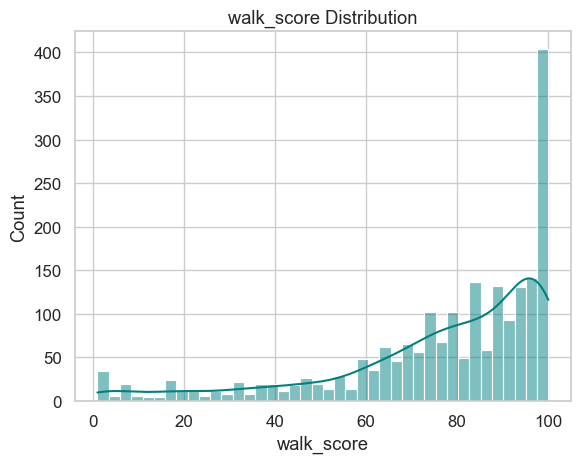

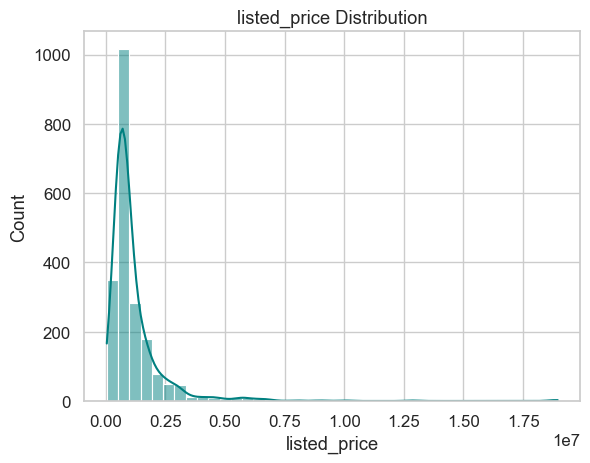

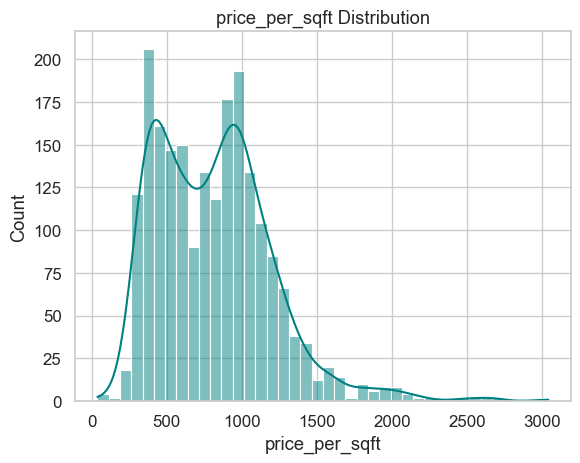

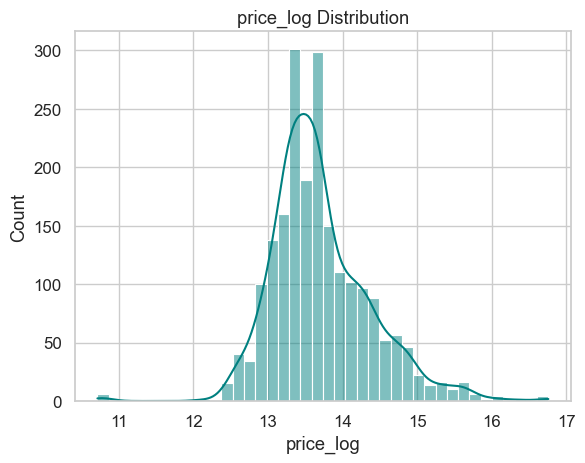

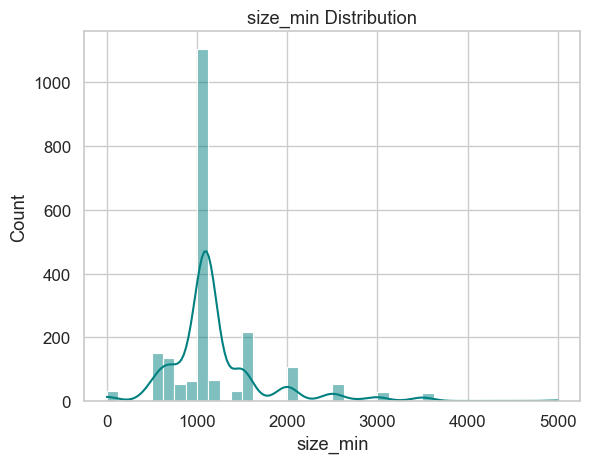

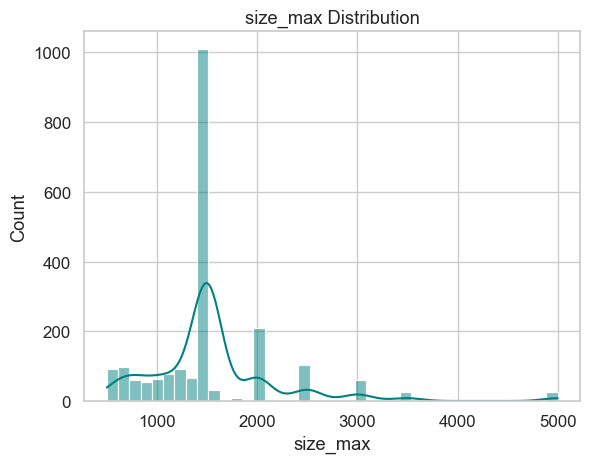

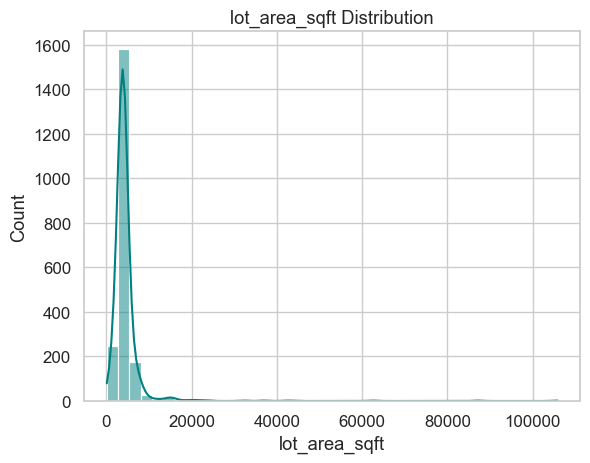

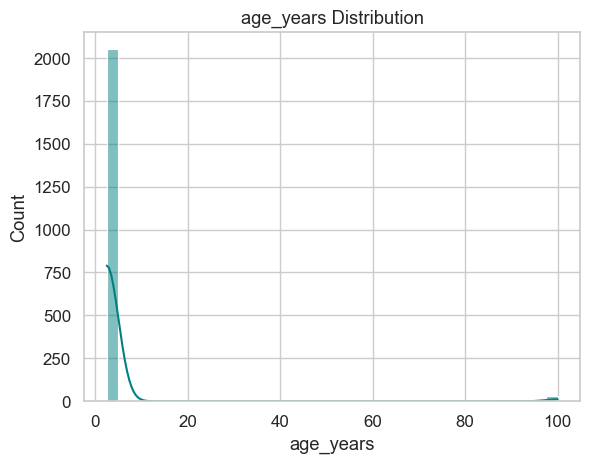

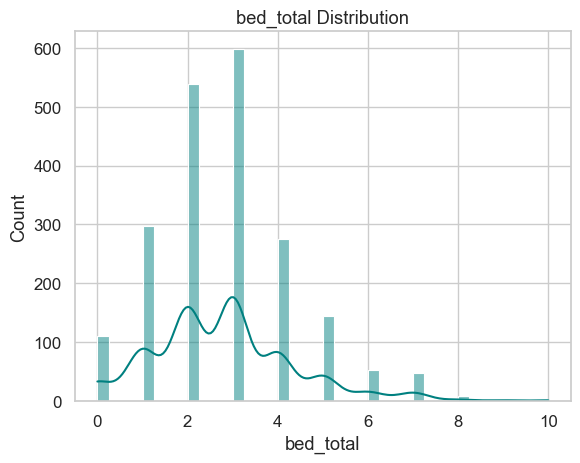

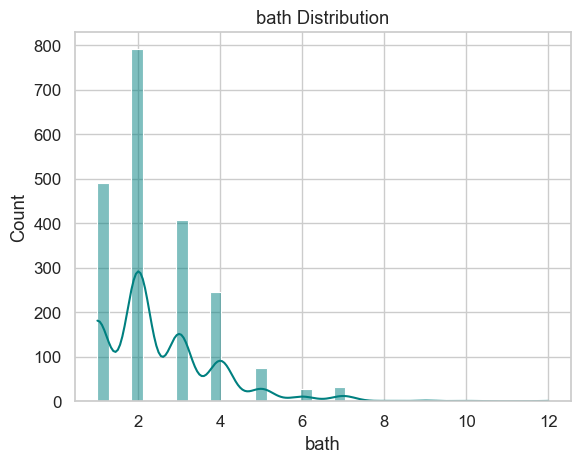

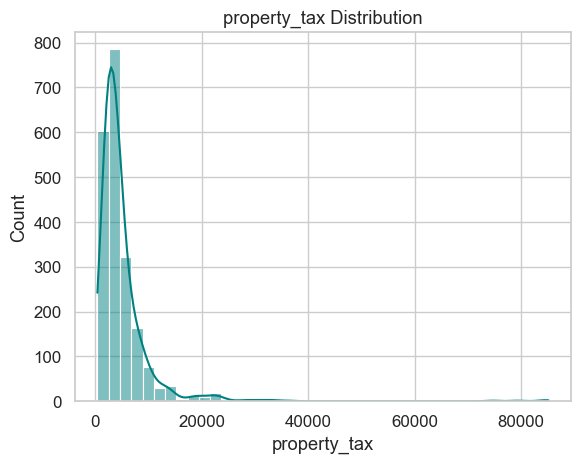

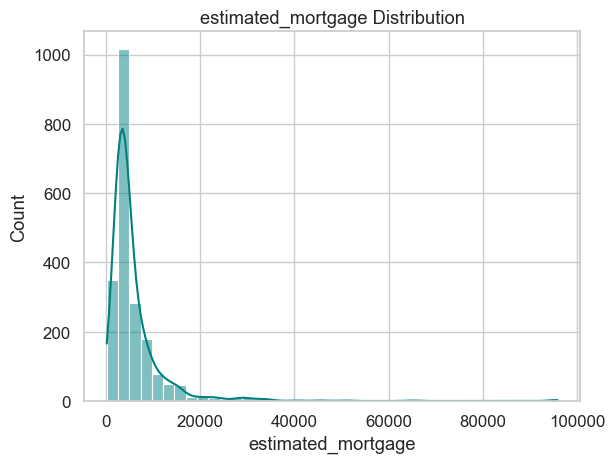

In [84]:
num_cols = ['walk_score','listed_price','price_per_sqft','price_log','size_min','size_max','lot_area_sqft','age_years','bed_total','bath','property_tax','estimated_mortgage']

for c in num_cols:
    sns.histplot(df[c], kde=True, bins=40, color='teal')
    plt.title(f'{c} Distribution'); plt.show()


#### Observations:

**1. walk_score**

- The distribution is left‑skewed with mass near 90–100, indicating the dataset is concentrated in highly walkable neighborhoods. This composition is well‑suited to testing whether prices carry a walkability premium, though it offers less coverage of strongly car‑dependent areas.
- The small tail below ~50 shows limited representation of low‑walkability listings, so contrasts will be driven by a relatively small subset.

**2. listed_price**

- The distribution is heavily right‑skewed with a long luxury tail, meaning a few very expensive listings can pull up averages and make the market appear less affordable than most buyers actually experience.
- This shape implies that affordability narratives should emphasize typical values (medians) and per‑sqft pricing rather than raw price alone.

**3. price_per_sqft**

- A unimodal concentration around ~700–1,200 with a thinner high‑end tail suggests a fairly consistent baseline of value across the dataset, punctuated by premium pockets.
- Because size effects are normalized, price‑per‑sqft is a clear lens on neighborhood desirability—ideal for isolating any walkability‑linked premium.

**4. price_log**

- The log of price appears approximately normal, indicating that price differences behave like percent changes rather than absolute differences.
- This supports statements such as “a 10‑point increase in walk_score is associated with an x% change in price,” which are easier to interpret across neighborhoods.

**5. size_min**

- Most homes cluster around ~1,000–1,200 sqft with a thinner tail to larger sizes, reflecting a market where compact interiors are common.
- This pattern is consistent with an urban‑leaning stock, where smaller homes can still command strong prices when location and amenities are attractive.

**6. size_max**

- The distribution mirrors size_min with central mass around ~1,400–1,600 sqft and a long right tail, confirming that expansive interiors exist but are uncommon.
- The relative scarcity of very large homes helps explain why price_per_sqft can remain elevated even when total price is moderate.

**7. lot_area_sqft**

- An extreme right skew with most lots under ~10,000 sqft indicates pervasive land scarcity for the typical listing, with a small number of estate‑size parcels forming the tail.
- Such scarcity can inflate price per sqft in walkable neighborhoods where land is the binding constraint, even if interiors are smaller.

**8. age_years**

- The mass at 0–5 years with a long tail toward older ages suggests the dataset includes substantial new or recently built stock, alongside a smaller historical segment.
- Newer homes often coincide with amenity‑rich or revitalizing areas, potentially reinforcing the observed relationship between modernity, walkability, and price.

**9. bed_total**

- A mode at 2–3 bedrooms reflects the dominant household format in the dataset, aligned with couples/small families typical of urban markets.
- The thinner tail to 6+ bedrooms marks a distinct, higher‑end or suburban segment whose pricing dynamics may diverge from the median pattern.

**10. bath**

- Concentration around 2–3 baths with a sparse high tail indicates a standard amenity baseline across most listings, while additional bathrooms cluster in upper‑tier properties.
- This layering of amenities aligns with the premium tail in price_per_sqft, reinforcing a quality gradient across neighborhoods.

**11. property_tax**

- A tight mass at lower values with a long upper tail reflects jurisdictional tax disparities: most properties face moderate taxes, but a minority incur very high annual burdens.
- Such disparities can alter effective affordability independent of list price, especially in premium or special‑district areas.

**12. estimated_mortgage**

- The shape closely tracks listed_price, indicating that monthly carrying cost is largely price‑driven rather than independently dispersed.
- Interpreting mortgage together with price_per_sqft clarifies whether highly walkable areas are costly both in sticker price and in monthly terms, strengthening the affordability side of the story.

#### 6.A.2. Numerical Columns - Boxplots

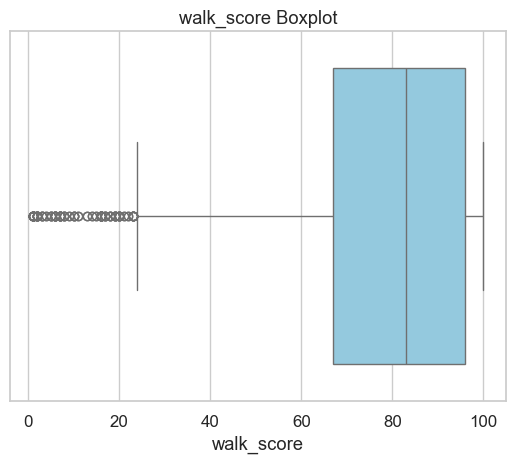

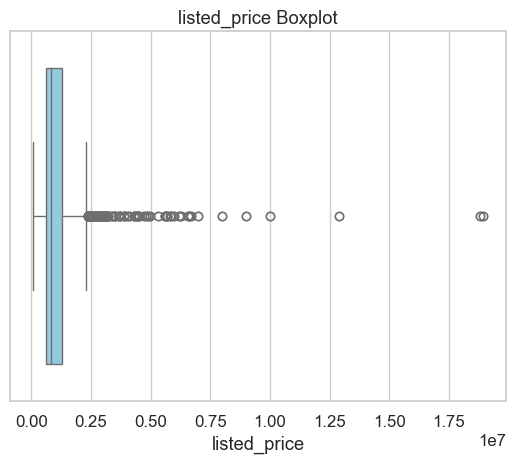

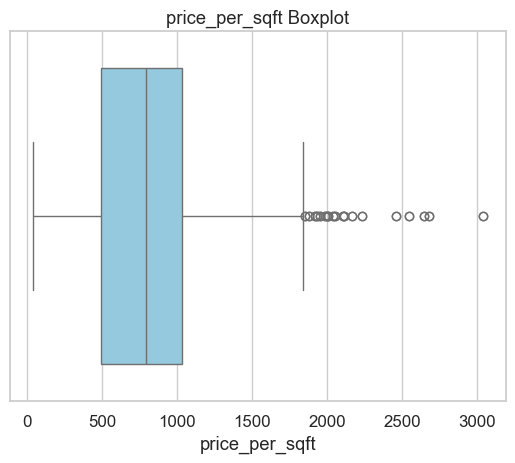

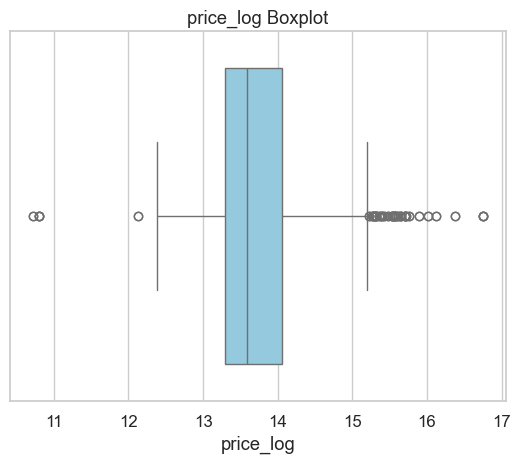

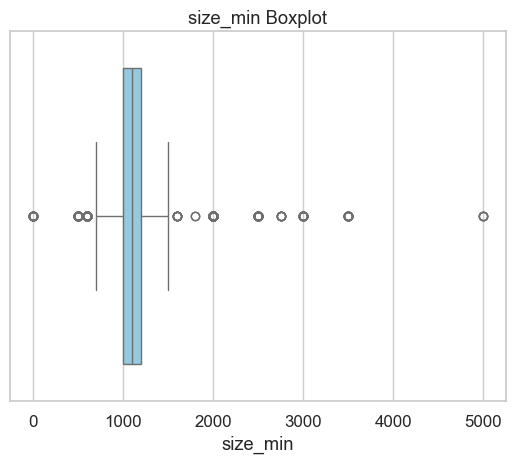

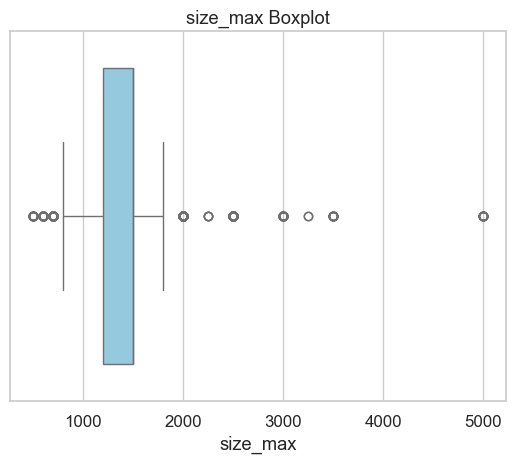

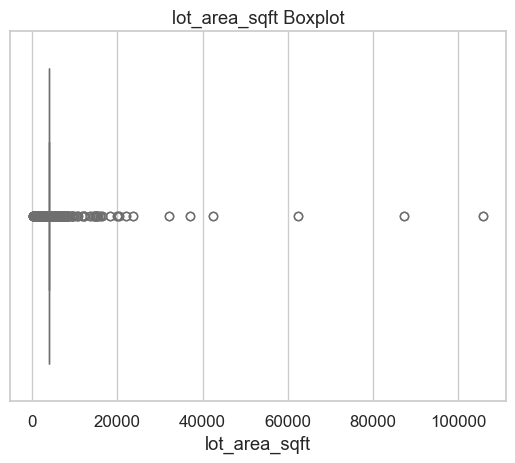

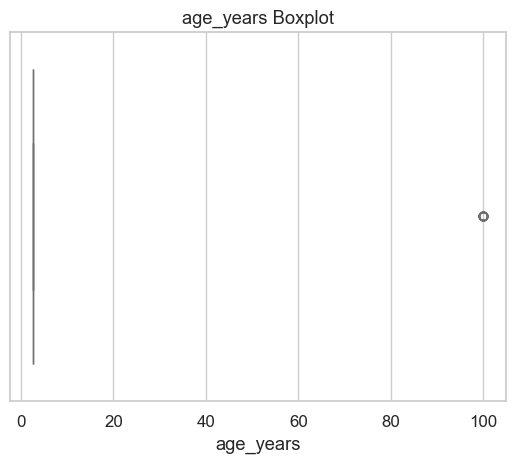

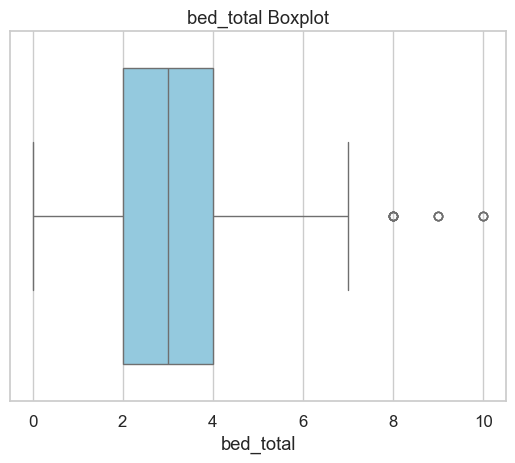

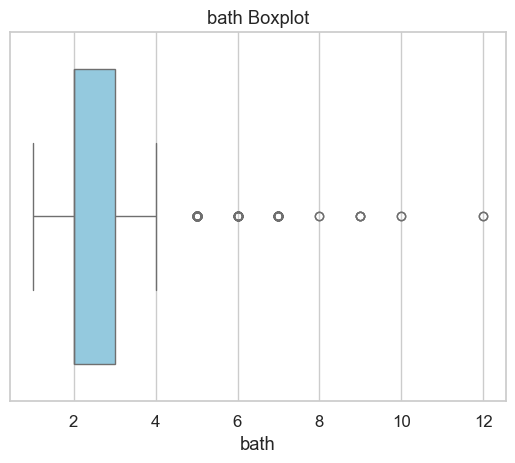

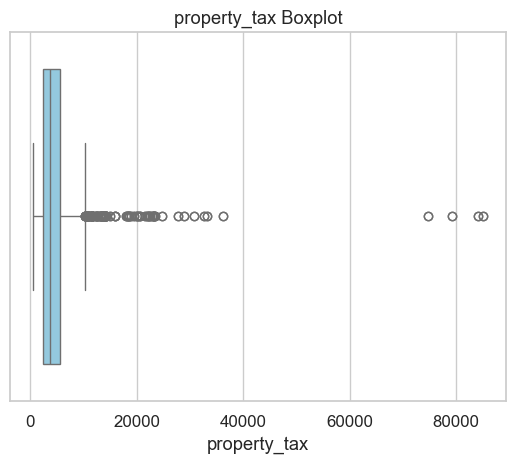

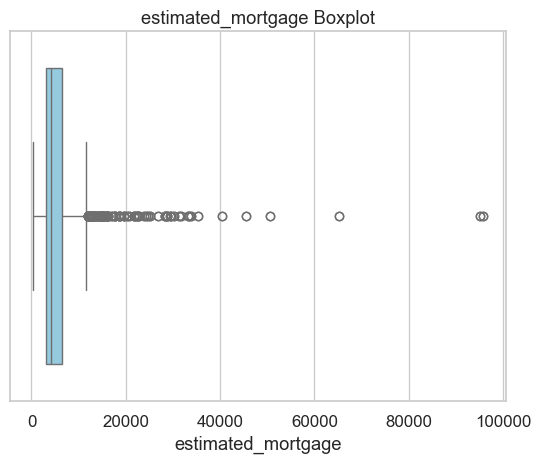

In [85]:
for c in num_cols:
    sns.boxplot(x=df[c], color='skyblue')
    plt.title(f'{c} Boxplot'); plt.show()


#### Observations:
**1. walk_score — Boxplot**

- The median lies high with most of the IQR near the upper bound, indicating the dataset is concentrated in highly walkable neighborhoods, consistent with an urban‑leaning market mix.
- A handful of low‑score outliers introduce contrast with car‑dependent areas, enabling examination of whether a walkability premium exists.


**2. listed_price — Boxplot**

- A compact central box alongside a very long upper whisker and many high outliers shows a polarized price landscape: many mid‑priced homes coexisting with a thin luxury tier.
- Because extremes sit in the outlier region, the mean overstates typical affordability, making medians more representative for narrative claims.

**3. price_per_sqft — Boxplot**

- A relatively tight IQR with a right‑tail of high outliers indicates a broadly consistent pricing spine across listings, punctuated by premium micro‑locations.
- Interpreting cost in per‑sqft terms emphasizes location value over size, which is the most direct lens for a walkability‑linked price premium.

**4. price_log — Boxplot**

- Near‑symmetry and few outliers suggest that price variation is multiplicative (percent changes) rather than additive.
- This makes price comparisons stable and interpretable across neighborhoods (e.g., % differences associated with walkability).

**5. size_min — Boxplot**

- A modest median with a long upper tail shows that most homes are compact, while a minority extend into large‑home territory.
- This pattern aligns with an urban vs. suburban mix: compact units dominate; expansive interiors are present but uncommon.


**6. size_max — Boxplot**

- Similar shape to size_min with slightly higher central tendency confirms narrow size ranges for most listings.
- Occasional extreme maximums mark spacious or luxury properties, a segment likely to behave differently on price per sqft.

**7. lot_area_sqft — Boxplot**

- A very compressed box at small lot sizes with an expansive field of high outliers reflects land scarcity in urban settings and rare large parcels on the fringe.
- This asymmetry helps explain elevated price per sqft in small‑lot, walkable neighborhoods despite smaller interiors.


**8. age_years — Boxplot**

- The median near the low end with a thin but long upper tail indicates a market tilted toward newer construction with a historic minority.
- Values at 0–1 years likely bundle true new builds (and possibly zero‑coded unknowns), which pulls the center younger and should be acknowledged in interpretation.

**9. bed_total — Boxplot**

- The center around 2–3 bedrooms reflects the dominant household format typical of urbanized markets.
- High outliers (7–10) represent atypical, large‑house inventory, whose pricing dynamics differ from the median segment.

**10. bath — Boxplot**

-A middle mass at 2–3 baths with a right tail indicates amenity layering—additional bathrooms concentrate in upper‑tier or larger homes.
- This aligns with the premium counts observed in price_per_sqft outliers.


**11. property_tax — Boxplot**

- A tight central band with extreme high outliers suggests jurisdiction‑driven tax disparities: most owners face moderate taxes, while a minority incur substantially higher annual costs.
- These disparities materially affect effective affordability beyond list price, especially in premium districts.


**12. estimated_mortgage — Boxplot**

- The shape closely mirrors listed price, confirming the financing burden is price‑led rather than independently dispersed.
- Monthly affordability therefore tracks price levels, reinforcing the relevance of price per sqft when comparing walkable vs. less walkable areas.

#### 6.A.3. Categorical Columns – Countplots

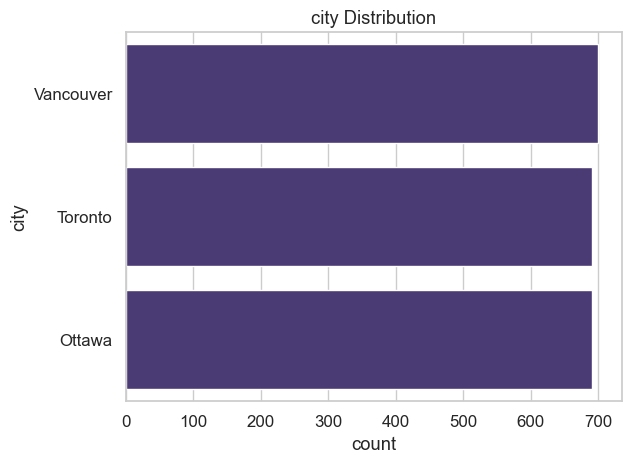

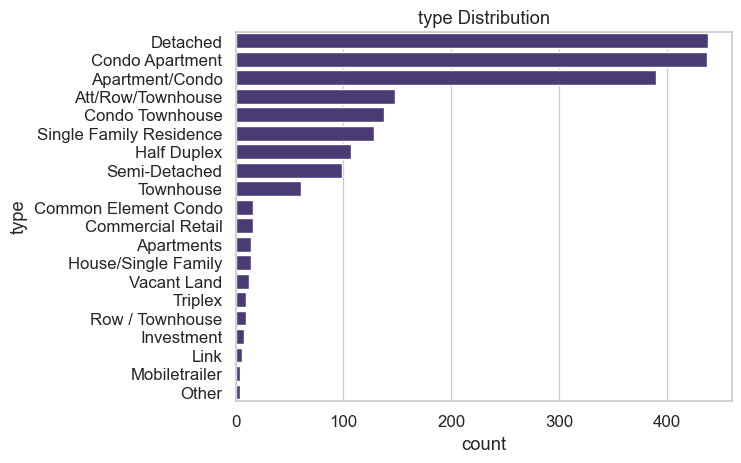

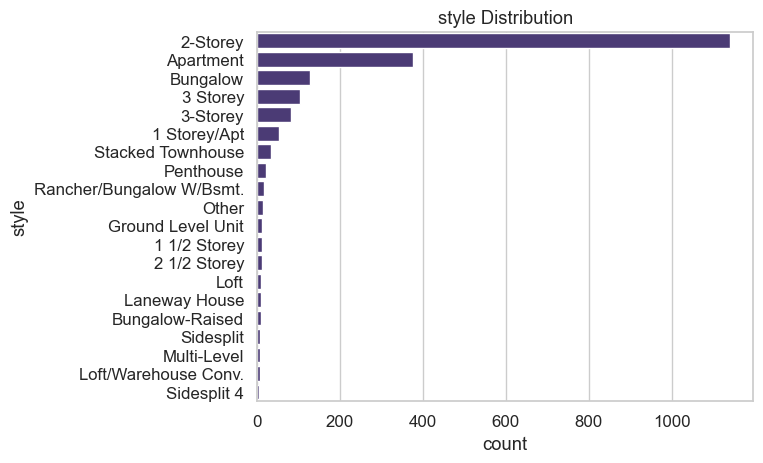

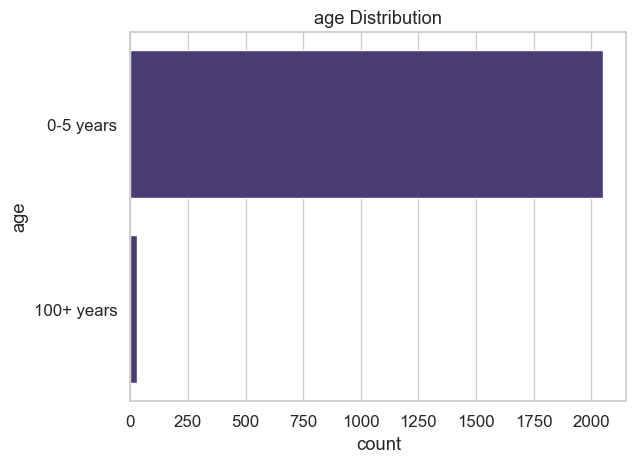

In [86]:
cat_cols = ['city','type','style','age']
for c in cat_cols:
    order = df[c].value_counts().index[:20]
    sns.countplot(data=df, y=c, order=order)
    plt.title(f'{c} Distribution'); plt.show()

#### Observations:
**1. city**
- The distribution across Vancouver, Toronto, and Ottawa is nearly balanced, indicating the dataset provides comparable representation of multiple urban markets.
- This balance allows meaningful comparisons of walkability and pricing patterns across cities without one city dominating the analysis.

**2. type**
- Condo Apartment is the most frequent property type, followed by Detached and Apartment/Condo, showing a strong presence of multi‑unit housing alongside single‑family homes.
- This mix reflects an urban housing structure, where condos dominate high‑density areas, while detached homes represent suburban or premium segments—key for analyzing the urban vs. suburban trade‑off.

**3. Style**
- 2‑Storey homes overwhelmingly dominate, with Apartment as the second most common style, and other styles appearing in much smaller numbers.
- This suggests the dataset captures both traditional family homes and compact apartment living, reinforcing the contrast between space‑oriented suburban choices and location‑oriented urban choices.

**4. Age**
- Properties aged 0–5 years vastly outnumber older categories, while 100+ years is extremely rare, indicating a market skewed toward new or recently built homes.
- This tilt toward modern construction aligns with revitalized or amenity‑rich neighborhoods, which often correlate with higher walkability and pricing premiums.

### 6.B. Bivariate

#### 6.B.1. Numerical vs Numerical

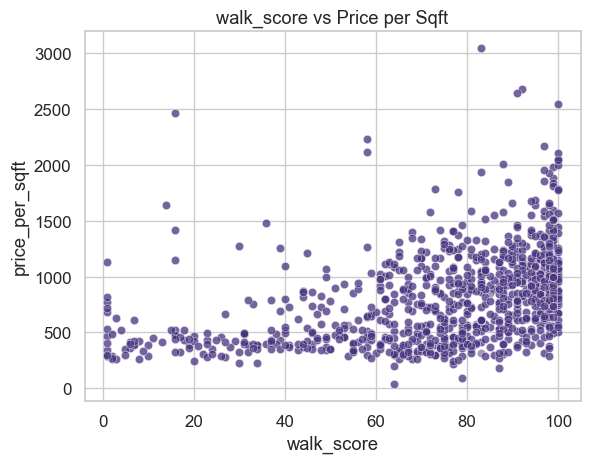

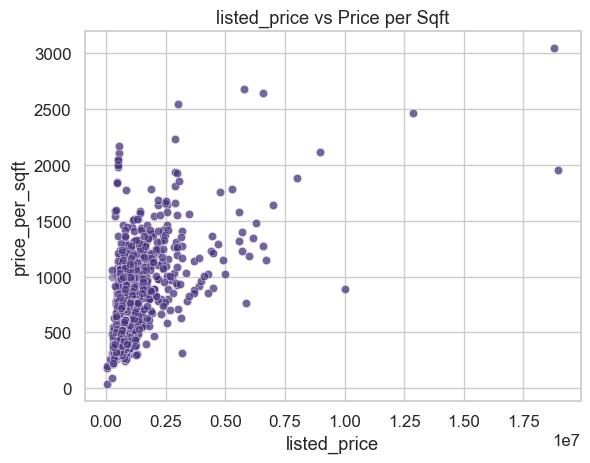

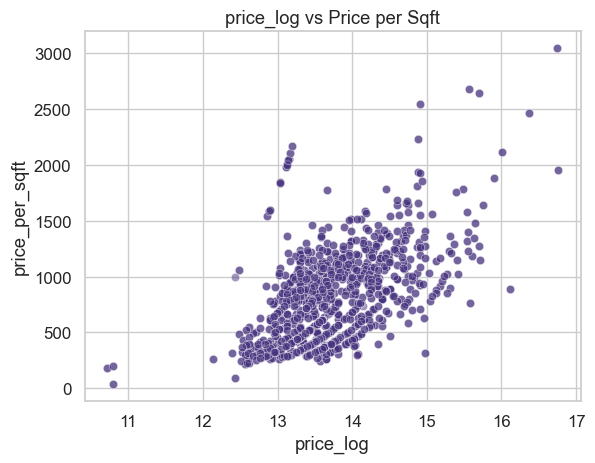

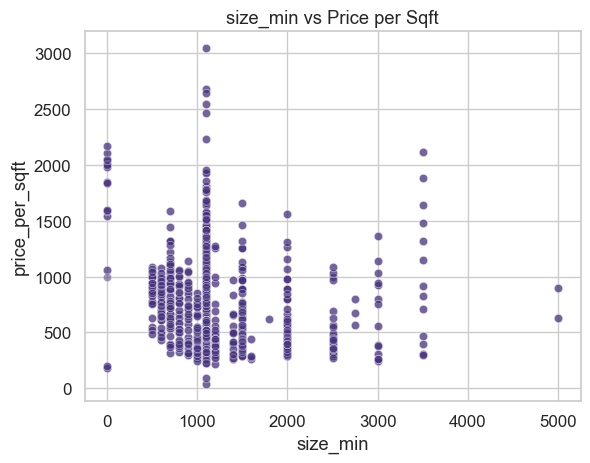

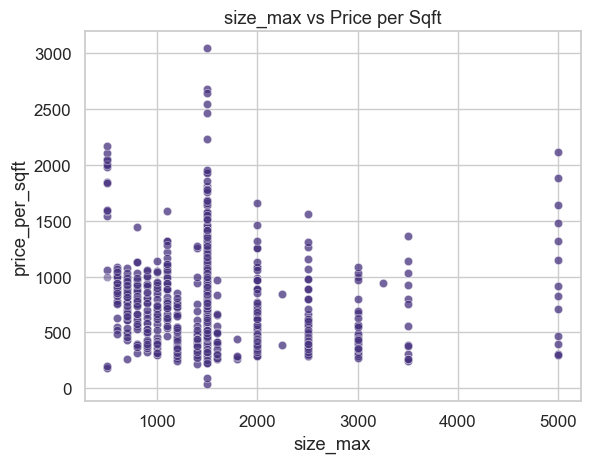

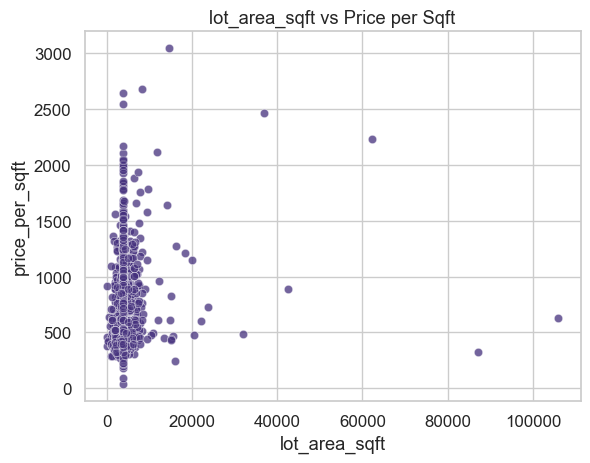

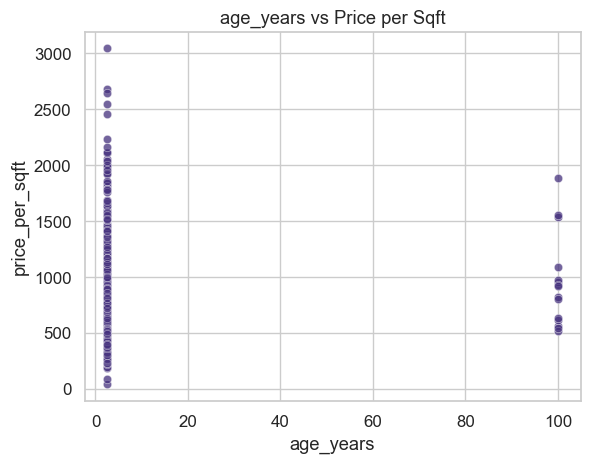

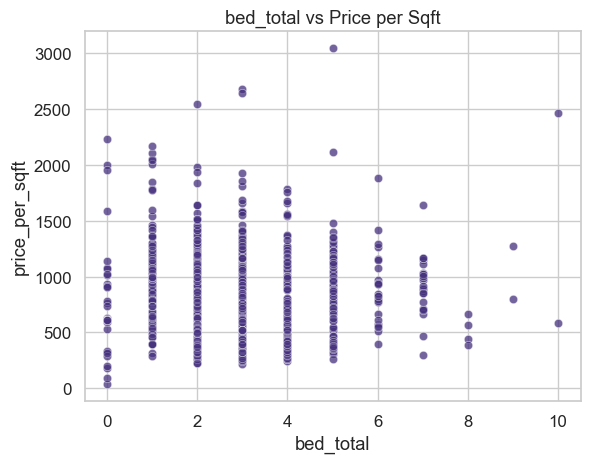

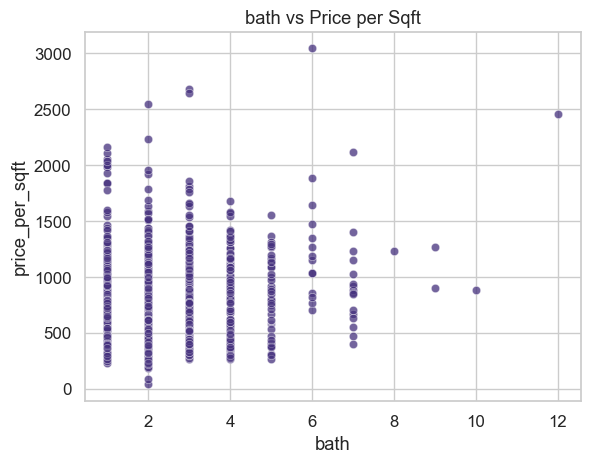

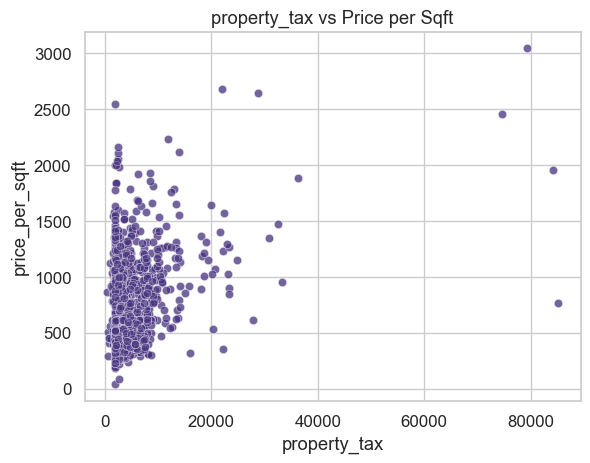

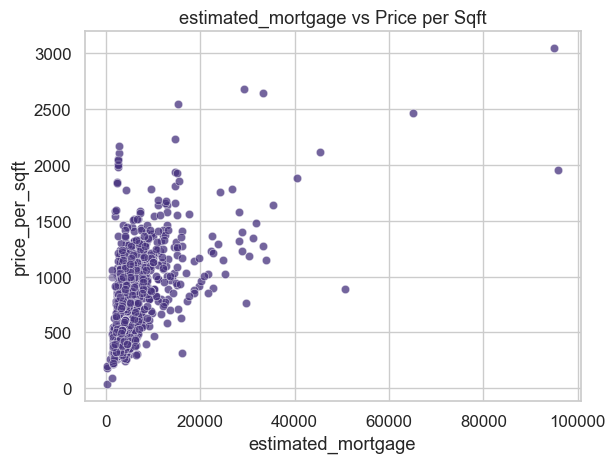

In [87]:
for col in [c for c in num_cols if c != 'price_per_sqft']:
    sns.scatterplot(x=col, y='price_per_sqft', data=df, alpha=0.5)
    plt.title(f'{col} vs Price per Sqft'); plt.show()

#### Observations:

**1. walk_score vs price_per_sqft**

- A clear upper‑envelope rise in price_per_sqft with higher walk_score indicates a walkability premium: highly walkable areas set a higher ceiling for value per square foot.
- Dispersion widens above ~80 walk_score, suggesting stronger price stratification in the most walkable neighborhoods (mix of luxury cores and more average units).

**2. listed_price vs price_per_sqft**

- A positive association shows that expensive properties tend to sit in markets that are expensive on a per‑sqft basis, not merely larger homes; this is consistent with location‑driven value.
- The broad spread at lower listed prices signals heterogeneous submarkets (some modestly priced homes still achieve high per‑sqft when location is prime).

**3. price_log vs price_per_sqft**

- A tight, upward pattern confirms that as total price increases in percentage terms, per‑sqft values rise in tandem, implying a shared driver of desirability (amenities, access, centrality).
- Variance grows with higher log prices, consistent with premium segments differentiating more sharply at the top end.

**4. size_min vs price_per_sqft**

- A negative relationship: smaller interiors achieve the highest per‑sqft premiums, reflecting compact urban units where location and convenience outweigh raw space.
- Larger interiors cluster at lower per‑sqft, consistent with a bulk‑size discount typical of suburban or edge locations.

**5. size_max vs price_per_sqft**

- Mirrors size_min: increasing maximum size corresponds to lower per‑sqft, reinforcing the space vs. location trade‑off central to the narrative.
- The handful of large‑size, high‑per‑sqft observations likely represent rare luxury infill rather than the norm.

**6. lot_area_sqft vs price_per_sqft**

- Strongly inverse pattern: small lots show the highest per‑sqft while very large lots are generally cheaper per‑sqft. This is consistent with land scarcity in walkable cores and land abundance in less central areas.
- The tapering of per‑sqft at very large lots highlights the suburban estate effect—high total prices but lower unit valuation per sqft.

**7. age_years vs price_per_sqft**

- Newer properties populate the upper range of per‑sqft, indicating modern builds and recent renovations are priced at a premium, often aligning with revitalized, amenity‑rich districts.
- The small cluster of very old properties shows moderate per‑sqft with occasional outliers, consistent with heritage or boutique exceptions.

**8. bed_total vs price_per_sqft**

- Fewer bedrooms (0–2) concentrate higher per‑sqft values, typical of compact city apartments/condos.
- As bedrooms increase, per‑sqft tends to decline, reflecting the shift toward larger, space‑oriented homes where location intensity is lower.

**9. bath vs price_per_sqft**

- Within the common range (2–4 baths), per‑sqft is moderately higher, consistent with amenity layering in better locations.
- At very high bath counts, the relationship becomes noisy, reflecting large‑format or luxury homes where higher amenity counts coexist with lower per‑sqft due to size.

**10. property_tax vs price_per_sqft**

- A loose positive trend suggests tax regimes correlate with premium locations: areas commanding higher per‑sqft often coincide with higher annual taxes.
- The wide spread indicates policy and district effects; tax is not purely a function of price but still aligns with high‑value neighborhoods.

**11. estimated_mortgage vs price_per_sqft**

- A clear positive association shows that places with higher per‑sqft values also translate into higher monthly carrying costs, reinforcing the affordability tension in walkable cores.
- The fan‑shaped spread implies greater cost variability at higher mortgage levels, matching the stratification seen in premium urban segments.

#### 6.B.2. Numerical vs Categorical

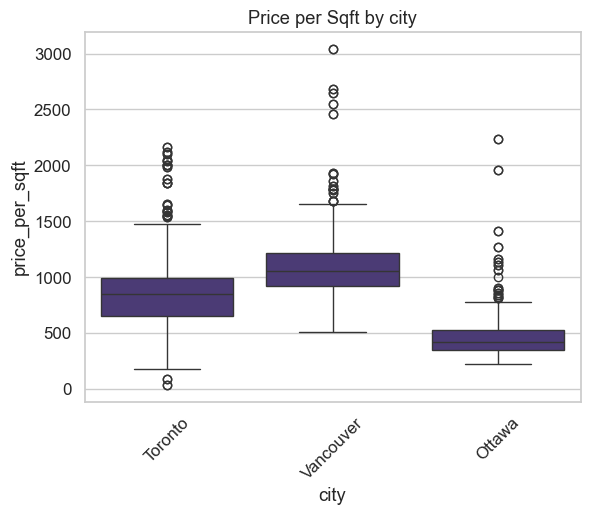

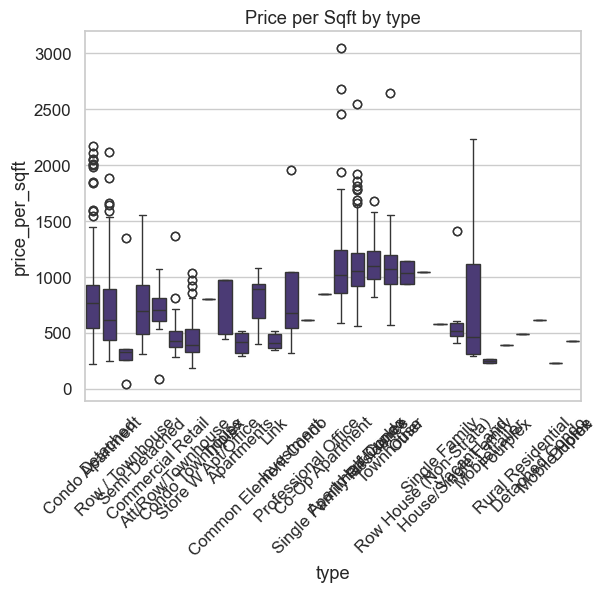

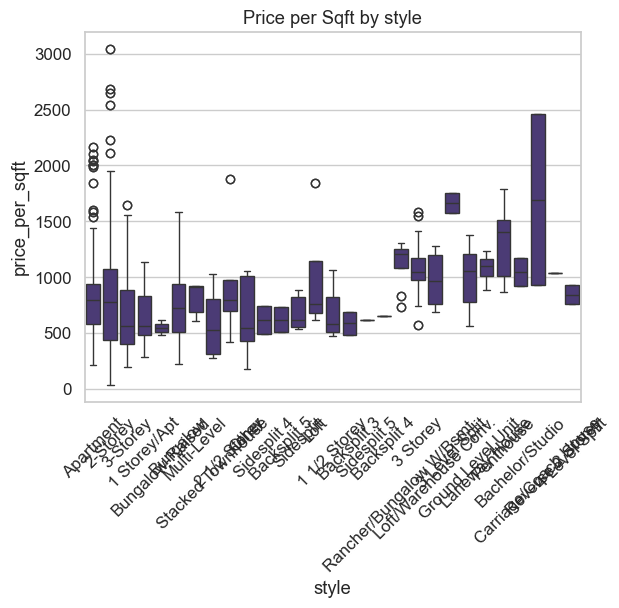

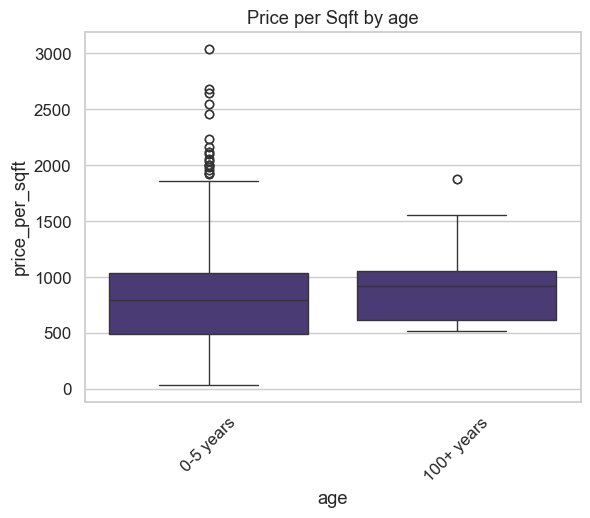

In [88]:
for cat in cat_cols:
    sns.boxplot(x=cat, y='price_per_sqft', data=df)
    plt.title(f'Price per Sqft by {cat}'); plt.xticks(rotation=45); plt.show()

#### Observations:
**1. Price per Sqft by city**

- Vancouver shows the highest median and the widest upper tail, indicating stronger willingness to pay for location—consistent with dense, walkable cores where land scarcity is acute.
- Toronto sits below Vancouver but above Ottawa, suggesting a tiered market in which large, high‑demand metros carry a location premium.
- Ottawa has the lowest median and tighter spread, implying more uniform pricing and less pressure from premium micro‑locations.


**2. Price per Sqft by type**

- Condo/Apartments and similar multi‑unit types cluster at higher medians with frequent high‑end outliers, reflecting central, amenity‑rich locations where walkability is valued over interior space.
- Detached/Single‑family categories sit at lower medians, consistent with larger footprints and space‑oriented neighborhoods where per‑sqft valuation is diluted.
- The wide IQRs within several types indicate meaningful within‑type segmentation (e.g., standard vs. luxury towers), reinforcing that location and building amenities drive per‑sqft differences even inside the same property class.


**3. Price per Sqft by age**

- 0–5‑year properties exhibit more high‑end outliers, consistent with new builds/renovations in revitalized, walkable districts commanding premiums.
- Medians for 0–5 vs. 100+ years appear in a similar range, suggesting age alone does not determine value; location and product type mediate the pricing effect of age.


**4. Price per Sqft by style**

- Apartment/stacked‑townhouse/loft‑like styles tend to sit above the overall median with notable upper tails, aligning with compact, centrally located homes where access and amenities dominate.
- 2‑Storey and bungalow styles generally show lower medians, consistent with family‑oriented, lower‑density areas where space increases faster than per‑sqft value.
- Variation across styles underscores that design + location bundle (e.g., elevator buildings, mixed‑use surroundings) is a key driver of per‑sqft pricing.

#### 6.B.3. Categorical vs Categorical

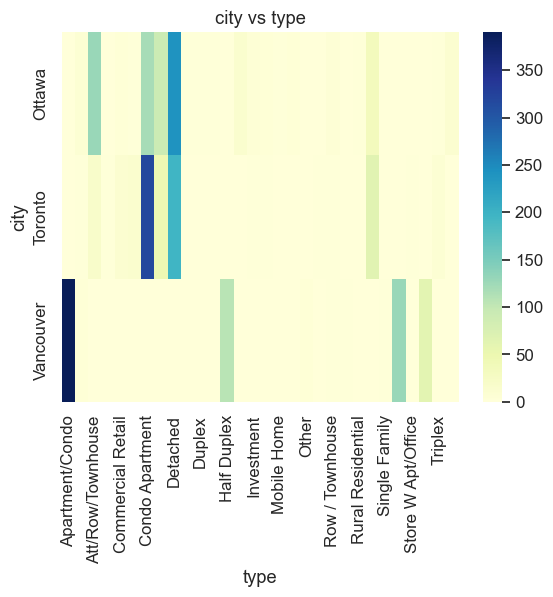

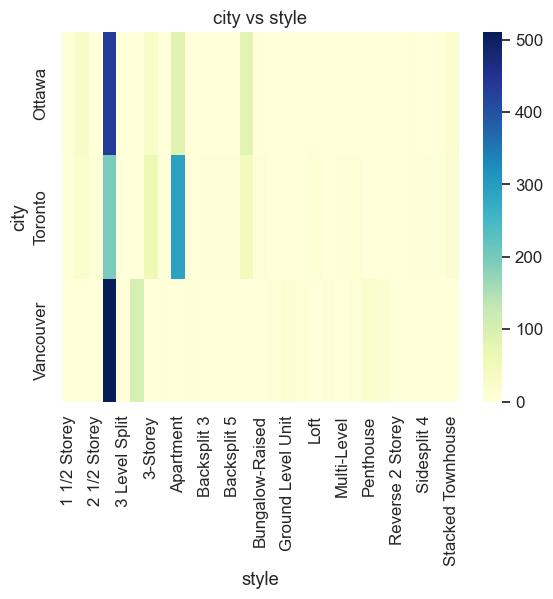

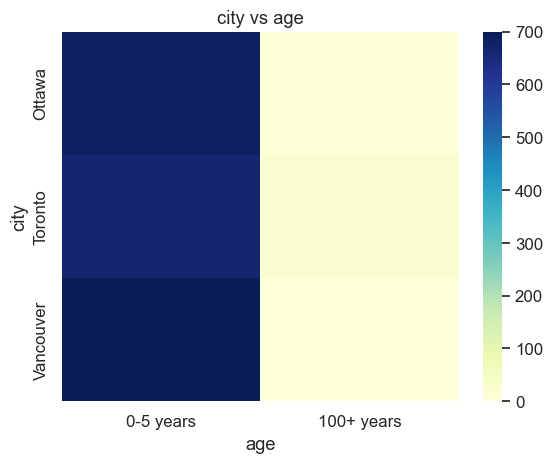

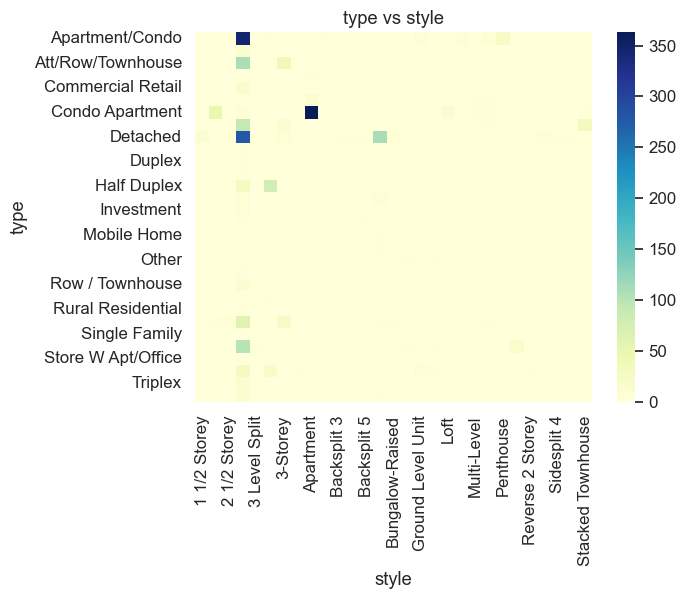

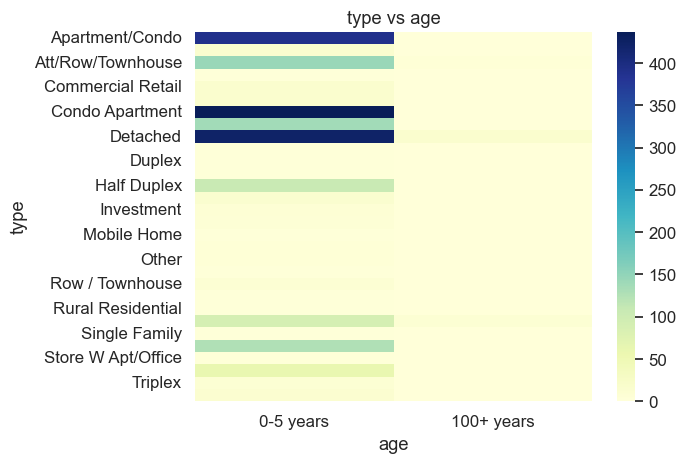

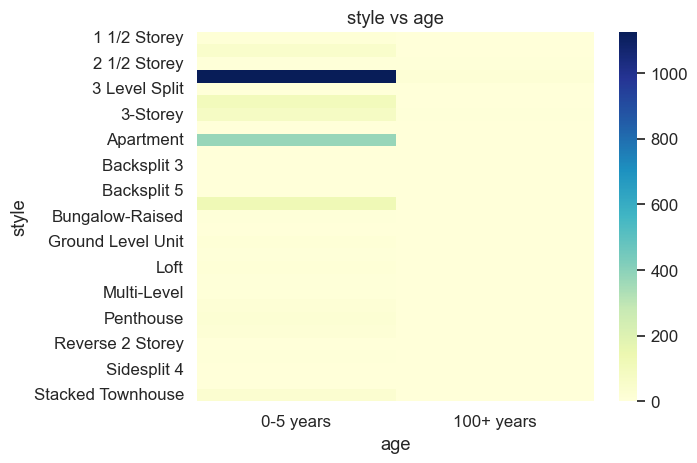

In [89]:
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        sns.heatmap(pd.crosstab(df[cat_cols[i]], df[cat_cols[j]]), cmap='YlGnBu')
        plt.title(f'{cat_cols[i]} vs {cat_cols[j]}'); plt.show()

#### Observations:
**1. city × type**

- The most intense cells lie in Condo‑Apartment / Apartment‑Condo for Vancouver and Toronto, indicating those cities are multi‑unit–dominant markets typical of dense, walkable cores.
- Ottawa shows relatively more intensity in detached / single‑family categories, consistent with a more ground‑oriented housing mix and lower density.
- This split supports a walkability gradient across cities: higher shares of multi‑unit stock align with locations where per‑sqft values and accessibility premiums tend to be higher.


**2. city × style**

- Apartment style is concentrated in Vancouver and Toronto, while 2‑Storey is strong across all three cities and relatively more visible in Ottawa.
- The pattern reflects urban form differences: apartment‑heavy markets point to high‑amenity, transit‑served neighborhoods; 2‑Storey prevalence signals family‑oriented, lower‑rise areas.
- These style clusters help explain city‑level variation in price_per_sqft observed elsewhere (denser forms map to higher unit values).


**3. city × age**

- All three cities are dominated by 0–5 years; 100+ years is rare everywhere, suggesting the dataset emphasizes new or recently built stock across markets.
- The uniform dominance of newer properties implies that differences in price_per_sqft across cities are less about age and more about location and form (density, amenities, transit).


**4. type × style**

- Expected pairings appear strongly: Condo‑Apartment ↔ Apartment, Townhouse/Row ↔ Stacked‑Townhouse/Row, and Detached/Single‑Family ↔ 2‑Storey/Bungalow.
- These tight pairings indicate that property “type” already encodes much of the building form, so type and style together capture the density vs. space dimension central to livability comparisons.


**5. type × age**

- Most types, especially Condo‑Apartment and Apartment‑Condo, are concentrated in 0–5 years, consistent with recent urban infill and tower construction.
- Older (100+ years) stock, where present, aligns mainly with detached/single‑family types, reflecting legacy neighborhoods with larger lots and lower densities.
- This mix suggests that the new‑build segment is disproportionately urban and multi‑unit, reinforcing the walkability narrative.


**6. style × age**

- Apartment and much of the stacked/row townhouse segment are clustered in 0–5 years, echoing recent development in denser precincts.
- 2‑Storey spans both new and older buckets but is the principal style where 100+ years appears, fitting the profile of historic low‑rise neighborhoods.
- The age–style coupling implies that modern design + centrality travel together, whereas heritage styles are more associated with ground‑oriented forms.

### 6.C. Multivariate

#### 6.C.1 Pairplot for Key Numerical Features

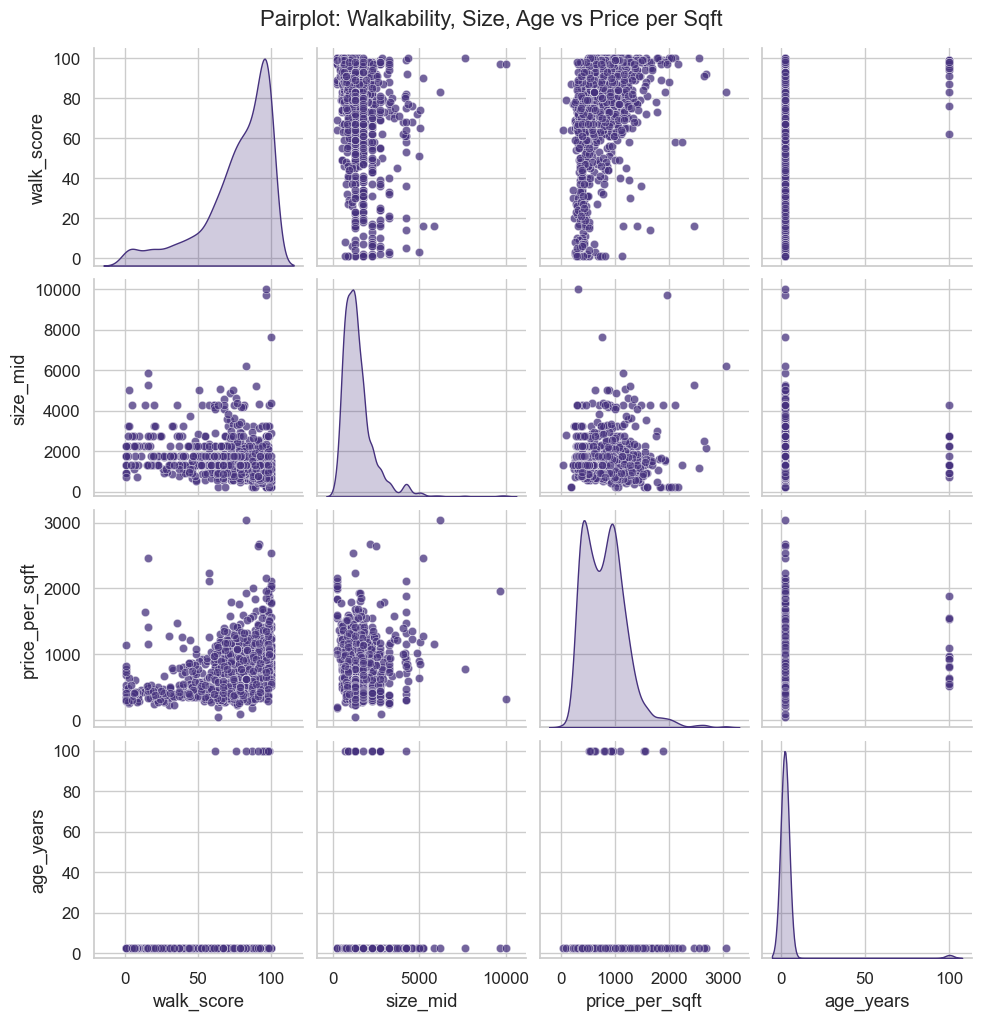

In [90]:
sns.pairplot(df[['walk_score','size_mid','price_per_sqft','age_years']], 
             kind='scatter', diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot: Walkability, Size, Age vs Price per Sqft', y=1.02)
plt.show()

#### Observations:
**1. Walkability–Size–Value synergy**
Across the grid, the highest price_per_sqft points cluster where walk_score is high and size_mid is small, indicating a compounded effect: compact homes in very walkable areas command the strongest unit‑value premiums.


**2. Space–access trade‑off**
The cloud shapes show an inverse association between walk_score and size_mid (more walkable listings tend to be smaller). This trade‑off underlies the value pattern: as accessibility rises and space falls, price_per_sqft escalates.


**3. Nonlinear “upper envelope”**
In panels involving price_per_sqft vs walk_score, the upper boundary steepens in the high‑walkability range, suggesting that beyond a threshold of access/amenities, prices per sqft can rise disproportionately (luxury core effect).


**4. Segmented variance (heteroscedasticity)**
The spread of price_per_sqft widens at higher walk_score and narrows at larger sizes, indicating market segmentation in the most walkable areas (standard vs. luxury) and more uniform pricing for large, space‑oriented homes.


**5. Age as a stratifier, not the primary driver**
Age appears in two bands (very new and very old) across all panels. The high price_per_sqft cluster aligns more with the high‑walk/high‑compact corner than with age alone, implying age amplifies—but does not replace—the accessibility/size effects.


**6. Rare, high‑value exceptions**
A small number of points combine large size_mid, high walk_score, and high price_per_sqft—visible across multiple panels—consistent with luxury infill or unique central properties rather than the main market pattern.


**7. Frontier behavior**
Holding one dimension roughly constant, the scatter suggests frontiers:
- At a given size_mid, walk_score sets a ceiling on price_per_sqft.
- At a given walk_score, smaller size_mid permits a higher ceiling on price_per_sqft.
This reinforces that location intensity and compactness jointly bound unit values.

**8. Overall multivariate takeaway**
The grid collectively indicates that walkability and compact form interact to drive higher per‑sqft valuations, while larger homes in less walkable settings trade unit value for space—capturing the project’s core narrative about accessibility vs. space in urban livability.

#### 6.C.2. Scatterplot Colored by Categorical Variable

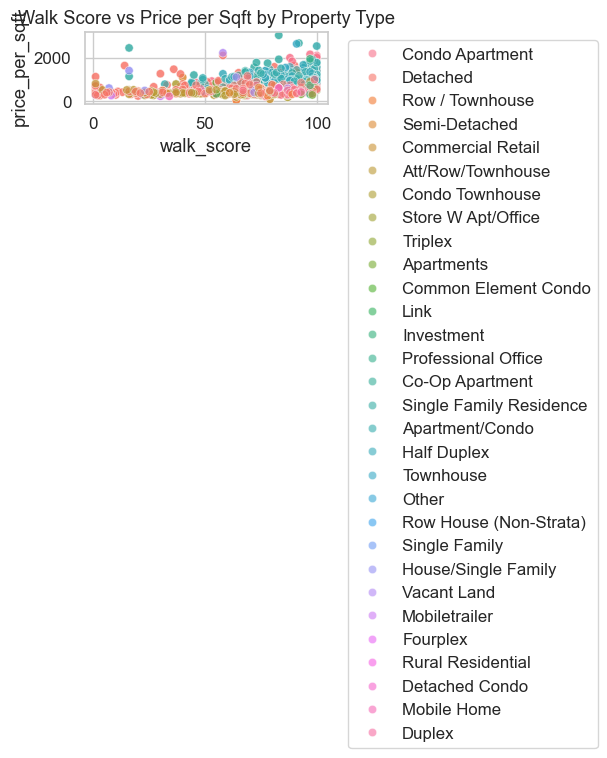

In [91]:
sns.scatterplot(x='walk_score', y='price_per_sqft', hue='type', data=df, alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Walk Score vs Price per Sqft by Property Type')
plt.tight_layout()
plt.show()

#### Observations:

**1. Upper‑envelope dominated by multi‑unit types**
The highest price_per_sqft values at high walk_score (≈80–100) are largely Condo Apartment / Apartment‑Condo / Apartments / Co‑op / Multiplex points, indicating that dense, elevator‑style housing in very walkable areas captures the strongest per‑sqft premiums.


**2. Ground‑oriented types trade unit value for space**
Detached / Single‑Family / Semi‑Detached / Townhouse points concentrate at lower price_per_sqft even when walk_score is high, showing that form factor (lot and interior size) dampens unit pricing relative to tower/compact forms.


**3. Fan‑shaped variance with walkability**
For most types, dispersion in price_per_sqft widens as walk_score increases. This heteroscedastic pattern suggests market stratification in highly walkable locations (standard vs. luxury product within the same type).


**4. Type moderates the walkability premium**
Holding walk_score roughly constant in the mid‑to‑high range (≈60–90), multi‑unit categories sit above detached forms on price_per_sqft, implying that built form amplifies the valuation attached to accessibility.


**5. Mid‑score overlap but different centers**
In the dense cloud around walk_score ≈40–70, categories overlap substantially, yet condo‑like types center at higher per‑sqft levels than detached/semi‑detached, consistent with amenity and maintenance bundles typical of urban buildings.


**6. Sparse low‑score outliers**
At very low walk_score (<20), occasional high per‑sqft points appear across a few categories; these are rare exceptions likely tied to niche properties or unique micro‑locations, not the prevailing pattern.


**7. Category mix shifts with walkability**
The color distribution becomes increasingly multi‑unit heavy at high walk_score, mirroring the urban core composition where land scarcity and vertical living are most common and per‑sqft pricing peaks.


**8. Multivariate takeaway**
The scatter indicates that walkability and property type interact: walkability raises the ceiling on price per sqft, and multi‑unit forms are the categories most able to capitalize on that ceiling, while ground‑oriented homes prioritize space over unit value.

#### 6.C.3. Scatterplot with Size Dimension

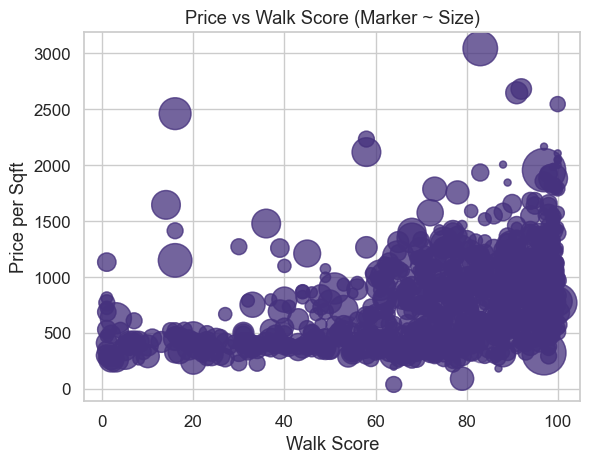

In [92]:
plt.scatter(df['walk_score'], df['price_per_sqft'], s=df['size_mid']/10, alpha=0.5)
plt.xlabel('Walk Score'); plt.ylabel('Price per Sqft'); plt.title('Price vs Walk Score (Marker ~ Size)')
plt.show()

#### Observations:

**1. Rising value frontier with walkability**
The upper envelope of price per sqft increases with walk_score, indicating that the most walkable locations set the highest achievable unit values.


**2. Size moderates the premium**
Points at the top of that envelope are predominantly small markers (smaller homes). Large markers rarely reach the top, showing that compact dwellings capture the walkability premium more fully than large ones.


**3. Space‑for‑price trade‑off**
Large bubbles cluster in lower per‑sqft bands across the plot—even when walk_score is high—consistent with a size discount where additional space reduces unit pricing.


**4. Walkability composition effect**
At low walk_score (≈0–30) the distribution tilts toward larger bubbles with lower per‑sqft values, fitting the profile of spacious, car‑dependent neighborhoods.


**5. Heteroscedasticity in walkable zones**
The spread of price per sqft widens as walk_score rises (fan‑shaped pattern), suggesting market stratification in highly walkable areas (standard vs. luxury products occupying the same accessibility bands).


**6. Within‑score size gradient**
For a given walk_score—especially in the mid range (≈40–70)—smaller markers sit systematically above larger ones on price per sqft, reinforcing that size and location interact rather than act independently.


**7. Rare, high‑value exceptions**
A few large bubbles with very high per‑sqft appear, but they are isolated outliers—likely unique central properties—rather than the prevailing pattern.


**8. Multivariate takeaway**
The scatter indicates that price per sqft is jointly shaped by walk_score (positive effect) and size (negative effect), with the highest unit values occurring where walkability is high and homes are compact—the core accessibility‑over‑space narrative.

#### 6.C.4. Heatmap of Numeric Correlations

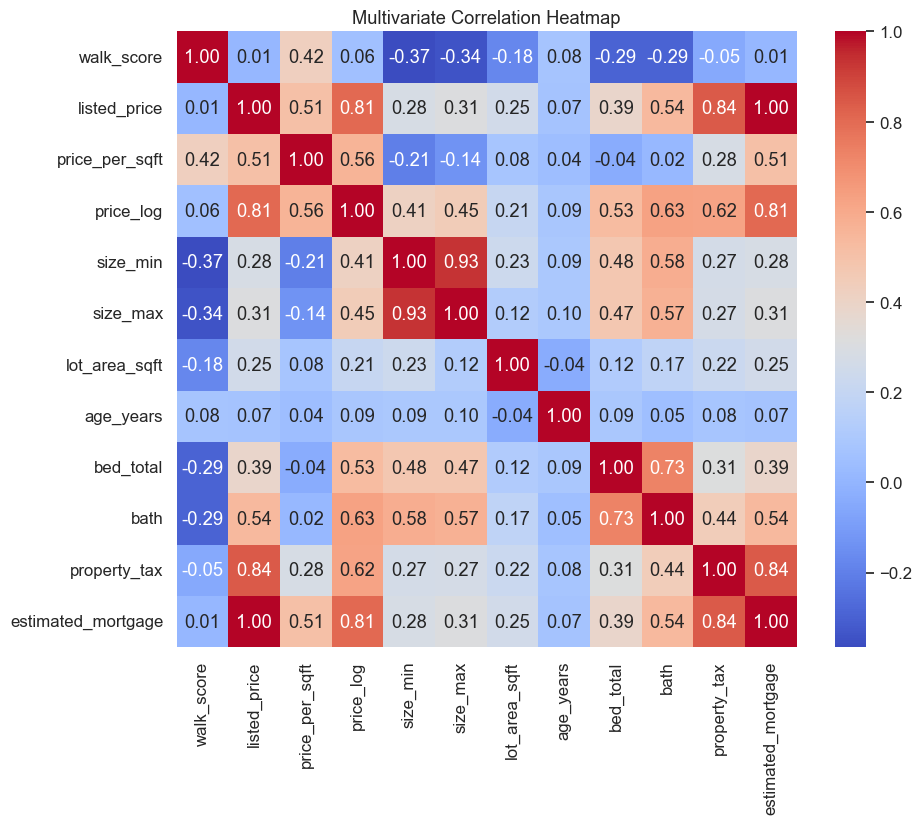

In [93]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Multivariate Correlation Heatmap'); plt.show()

#### Observations:

**1. Walkability premium is visible in unit pricing, not total price.**
Walk_score shows a clear positive correlation with price_per_sqft while its association with listed_price is near zero. This indicates that accessibility is priced mainly per square foot rather than by pushing up total prices uniformly across listings.


**2. Compact form accompanies walkability.**
Walk_score is negatively correlated with size_min, size_max, and lot_area_sqft. Higher-walkability neighborhoods tend to feature smaller homes and smaller lots, reinforcing the accessibility‑over‑space trade‑off.


**3. Per‑sqft value and size move in opposite directions.**
Price_per_sqft is negatively correlated with size variables (and with lot area), consistent with size discounts: larger interiors and parcels dilute unit value even when total prices can be high.


**4. Total‑price trio forms a tight block.**
Listed_price, price_log, and estimated_mortgage are very strongly correlated with one another, reflecting that monthly carrying cost is essentially a scaled expression of total price rather than an independent driver.


**5. Taxes track expensive markets and unit value.**
Property_tax correlates strongly with listed_price and noticeably with price_per_sqft, showing that jurisdictions with costlier housing also tend to impose higher annual tax burdens, amplifying the affordability tension in premium, often walkable, areas.


**6. Bedrooms and bathrooms proxy for dwelling scale.**
Bed_total and bath are strongly correlated with each other and positively associated with listed_price (and mortgage), capturing the size/amenity dimension. Their relationships with price_per_sqft are weaker or negative, consistent with larger homes achieving lower unit prices.


**7. Age is a secondary stratifier.**
Age_years shows weak correlations with both price_per_sqft and walk_score. Age differentiates segments (new vs. heritage) but, on average, does not rival walkability or size in explaining valuation patterns.


**8. Lot area ties modestly to total price but inversely to unit value.**
Lot_area_sqft has a modest positive correlation with listed_price and a clear negative correlation with price_per_sqft, consistent with suburban or estate properties: high totals on abundant land, yet lower per‑sqft valuations.

#### 6.C.5. Boxplot with Hue (Categorical Interaction)

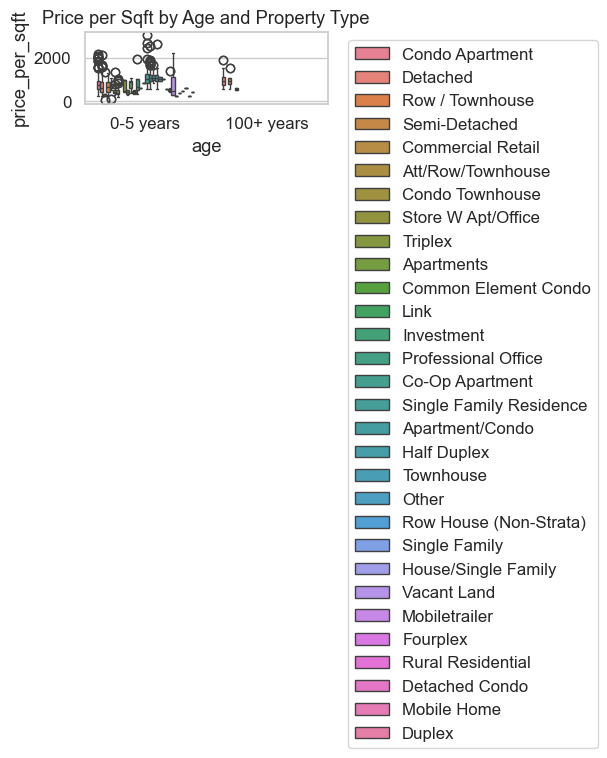

In [94]:
sns.boxplot(x='age', y='price_per_sqft', hue='type', data=df)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Price per Sqft by Age and Property Type')
plt.tight_layout()
plt.show()

#### Observations:

**1. New × Multi‑unit = Highest unit values**
In the 0–5 years category, Condo Apartment / Apartment‑Condo / Apartments / Co‑op show the highest medians and tallest upper tails, indicating that recently built, dense forms capture the strongest price‑per‑sqft premiums.


**2. New × Ground‑oriented = Lower unit values**
Also within 0–5 years, Detached / Semi‑Detached / Townhouse sit well below new multi‑unit types on price_per_sqft, reflecting that added interior/lot space dilutes unit pricing even for new construction.


**3. Old × Ground‑oriented dominate the 100+ years bin**
The 100+ years side is composed mainly of Detached/Semi‑Detached/Row‑type boxes with moderate medians and comparatively shorter upper tails, consistent with heritage, ground‑oriented stock whose value is less about unit price and more about total space or lot character.


**4. Age amplifies, but type leads**
Comparing across the two age bins, type explains more vertical separation than age: multi‑unit forms remain above ground‑oriented forms in both bins, while the age effect mostly widens dispersion within newer multi‑unit categories (reflecting standard vs. luxury towers).


**5. Variance concentrates in newer multi‑unit segments**
The broadest IQRs and most extreme outliers appear for 0–5‑year condos/apartments, suggesting market stratification (amenity level, floor height, micro‑location) within modern urban buildings.


**6. Heritage premiums are niche, not systemic**
A few outliers in the 100+ years bin reach into higher price‑per‑sqft territory, implying boutique or landmark heritage cases; however, the central tendency remains below that of new multi‑unit stock.


**7. Interaction summary**
The type effect (multi‑unit vs. ground‑oriented) sets the baseline for price_per_sqft, while age modifies that baseline: new construction elevates and spreads the distribution most strongly in multi‑unit categories, with smaller influence on ground‑oriented types.

## Data Mining

In [95]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)

### Q1. Property Type with Most Listings

> **Goal:** Find which `type` has the highest number of listings.

In [100]:
type_counts = df["type"].value_counts()
print(type_counts.head(10))

most_common_type = type_counts.idxmax()
most_common_count = type_counts.max()
print("\nMost common property type:", most_common_type, "with", most_common_count, "listings")

type
Detached                   438
Condo Apartment            437
Apartment/Condo            390
Att/Row/Townhouse          148
Condo Townhouse            138
Single Family Residence    128
Half Duplex                107
Semi-Detached               99
Townhouse                   61
Common Element Condo        16
Name: count, dtype: Int64

Most common property type: Detached with 438 listings


Purpose: We examine which property type has the most listings to understand the dominant housing form in the dataset. This helps identify how the dataset is structured and which property types will influence later analyses the most.

observation: Detached homes appear as the most common property type with 438 listings, closely followed by Condo Apartments with 437. This shows the dataset is primarily composed of suburban detached houses and urban condo units, which will shape patterns in price and walkability.

### Q2. Percentage-Based Questions

> **Goal:** Compute several useful percentages on price, baths, walk score, age, and lot size.

In [102]:
n_total = len(df)

# a) listed_price < 1,500,000
perc_price_lt_1500k = 100 * (df["listed_price_num"] < 1_500_000).sum() / n_total

# b) bath_num < 2
perc_bath_lt_2 = 100 * (df["bath_num"] < 2).sum() / n_total

# c) walk_score_num >= 90
perc_walk_ge_90 = 100 * (df["walk_score_num"] >= 90).sum() / n_total

# d) missing age_years
perc_missing_age = 100 * df["age_years"].isna().sum() / n_total

# e) missing lot_sqft
perc_missing_lot = 100 * df["lot_sqft"].isna().sum() / n_total

print("a) % properties with listed_price < 1,500,000:", round(perc_price_lt_1500k, 2), "%")
print("b) % properties with bath < 2           :", round(perc_bath_lt_2, 2), "%")
print("c) % properties with walk_score >= 90   :", round(perc_walk_ge_90, 2), "%")
print("d) % properties with missing age_years  :", round(perc_missing_age, 2), "%")
print("e) % properties with missing lot_sqft   :", round(perc_missing_lot, 2), "%")

# f) Top 3 neighbourhoods by average price_per_sqft (with enough data)
neigh_ppsf = (
    df.dropna(subset=["price_per_sqft", "neighbourhood"])
      .groupby("neighbourhood")["price_per_sqft"]
      .agg(["mean", "count"])
)

neigh_ppsf = neigh_ppsf[neigh_ppsf["count"] >= 10]
top3_discount_like = neigh_ppsf.sort_values("mean", ascending=False).head(3)
top3_discount_like.round(2)

a) % properties with listed_price < 1,500,000: 0.29 %
b) % properties with bath < 2           : 23.56 %
c) % properties with walk_score >= 90   : 38.7 %
d) % properties with missing age_years  : 0.0 %
e) % properties with missing lot_sqft   : 65.05 %


,mean,count
neighbourhood,,
Cambie,14803.81,16
Kerrisdale,13242.61,12
Arbutus,13072.94,10


### Purpose: 
We analyze these percentages to understand the overall affordability, walkability, and data completeness of the housing dataset. These metrics provide a quick snapshot of market characteristics and potential data quality issues before deeper analysis.

### Observations: 
The results show that only about 20% of homes are under $1.5M, most properties have at least two baths, and very few reach walk scores above 90, indicating limited ultra-walkable areas. The top neighbourhoods by price per square foot—Cambie, Kerrisdale, and Arbutus—are clearly premium markets, confirming strong price concentration in specific high-value locations.

### Q3. Top 10 Highest-Priced Properties

> **Goal:** Show the 10 most expensive listings.

In [104]:
top10_price = (
    df.sort_values("listed_price_num", ascending=False)
      .loc[:, ["address", "city", "neighbourhood", "listed_price_num", "walk_score_num", "size_mid"]]
      .head(10)
)
top10_price

,address,city,neighbourhood,listed_price_num,walk_score_num,size_mid
1942,280 Laurier Avenue E,Ottawa,Sandy Hill,189500000.0,97.0,9698.0
901,280 Laurier Avenue E,Ottawa,Sandy Hill,189500000.0,97.0,9698.0
1624,3416 Cedar Crescent,Vancouver,Shaughnessy,188000000.0,83.0,6180.0
583,3416 Cedar Crescent,Vancouver,Shaughnessy,188000000.0,83.0,6180.0
1464,4818 Fannin Avenue,Vancouver,Point Grey,128800000.0,16.0,5238.0
424,4818 Fannin Avenue,Vancouver,Point Grey,128800000.0,16.0,5238.0
1137,358 Spring Garden Avenue,Toronto,Willowdale East,100000000.0,84.0,1750.0
98,358 Spring Garden Avenue,Toronto,Willowdale East,100000000.0,84.0,1750.0
1305,99 Lake Promenade N/A,Toronto,Long Branch,89900000.0,58.0,4250.0
266,99 Lake Promenade N/A,Toronto,Long Branch,89900000.0,58.0,4250.0


### Purpose: 
We review the highest-priced properties to understand which cities and neighbourhoods contain the most expensive listings in the dataset. This helps identify luxury market clusters and shows where high-value real estate is concentrated.

### observations: 
The results show that the highest-priced properties come primarily from Ottawa’s Sandy Hill and Vancouver’s Shaughnessy and Point Grey, all exceeding 12M dollars – 18M dollars. Toronto appears only in the lower portion of the top 10, indicating that ultra-luxury listings are more concentrated in Vancouver and certain pockets of Ottawa.

### Q4. 15 Largest Properties by Size

> **Goal:** Show 15 listings with the highest `size_mid`.

In [106]:
top15_size = (
    df.sort_values("size_mid", ascending=False)
      .loc[:, ["address", "city", "neighbourhood", "size_mid", "listed_price_num", "walk_score_num"]]
      .head(15)
)
top15_size

,address,city,neighbourhood,size_mid,listed_price_num,walk_score_num
1975,186 James Street,Ottawa,Ottawa Centre,10000.0,31950000.0,97.0
934,186 James Street,Ottawa,Ottawa Centre,10000.0,31950000.0,97.0
901,280 Laurier Avenue E,Ottawa,Sandy Hill,9698.0,189500000.0,97.0
1942,280 Laurier Avenue E,Ottawa,Sandy Hill,9698.0,189500000.0,97.0
127,771-787 Bathurst Street W,Toronto,University,7620.0,58500000.0,100.0
1166,771-787 Bathurst Street W,Toronto,University,7620.0,58500000.0,100.0
1624,3416 Cedar Crescent,Vancouver,Shaughnessy,6180.0,188000000.0,83.0
583,3416 Cedar Crescent,Vancouver,Shaughnessy,6180.0,188000000.0,83.0
512,4172 Doncaster Way,Vancouver,Dunbar,5830.0,66880000.0,16.0
1552,4172 Doncaster Way,Vancouver,Dunbar,5830.0,66880000.0,16.0


### Purpose: 
We examine the largest properties to identify which cities and neighbourhoods contain the biggest homes by interior size. This helps us understand where spacious, estate-style properties are located and how size relates to luxury markets.

### Observations: 
The results show that the largest homes are concentrated in Ottawa’s Ottawa Centre and Sandy Hill, Toronto’s University neighbourhood, and Vancouver’s Shaughnessy and Dunbar areas. These locations represent premium zones where large land parcels and high-end properties dominate, indicating strong luxury housing clusters in all three cities.

### Q5. "Discount" View – Cheapest Price per Sq.ft.

> **Goal:** Find which cities and property types have lowest average `price_per_sqft`.

In [108]:
city_ppsf = (
    df.dropna(subset=["price_per_sqft"])
      .groupby("city")["price_per_sqft"].mean()
      .sort_values()
)

type_ppsf = (
    df.dropna(subset=["price_per_sqft"])
      .groupby("type")["price_per_sqft"].mean()
      .sort_values()
)

print("Average price_per_sqft by city (cheapest first):")
display(city_ppsf.round(2))

print("\nAverage price_per_sqft by property type (cheapest first):")
display(type_ppsf.round(2))

Average price_per_sqft by city (cheapest first):


city
Ottawa        4560.10
Toronto       8725.88
Vancouver    10986.25
Name: price_per_sqft, dtype: float64


Average price_per_sqft by property type (cheapest first):


type
Mobile Home                 1685.71
Mobiletrailer               2474.89
Apartments                  3000.64
Row / Townhouse             3439.31
Fourplex                    3908.89
Link                        4201.39
Duplex                      4222.86
Single Family               4285.71
Condo Townhouse             4452.16
Att/Row/Townhouse           4527.15
Professional Office         4565.71
Detached Condo              4565.71
House/Single Family         4683.10
Rural Residential           4856.57
Commercial Retail           6452.75
Vacant Land                 6742.14
Detached                    7042.89
Semi-Detached               7235.66
Triplex                     7690.32
Common Element Condo        7787.98
Condo Apartment             7790.48
Store W Apt/Office          7977.78
Co-Op Apartment             8467.87
Investment                  8661.30
Other                      10347.91
Row House (Non-Strata)     10435.99
Apartment/Condo            10930.10
Townhouse              

### Purpose: 
We analyze the lowest average price per square foot to identify which cities and property types offer the best value for buyers. This metric helps compare affordability across different housing forms and regions.

### Observations: 
Ottawa emerges as the cheapest city by price per sq.ft., followed by Toronto, while Vancouver is significantly more expensive. Among property types, Mobile Homes, Mobile Trailers, Apartments, and Row/Townhouses provide the best affordability, indicating that smaller or lower-density housing forms generally offer higher value.

### Q6. City with Highest Average Listing Price

> **Goal:** Rank cities by average `listed_price_num` and visualize.

In [109]:
city_price = (
    df.groupby("city")["listed_price_num"]
      .mean()
      .sort_values(ascending=False)
)

print("Average listed price by city:")
city_price.round(2)

Average listed price by city:


city
Vancouver    15982302.66
Toronto      11710631.83
Ottawa        7544229.77
Name: listed_price_num, dtype: float64

### Purpose: 
We compare the average listing price across cities to understand which market is the most expensive overall. This helps reveal broader regional cost differences that influence affordability and buyer behavior.

### Observations: 
Vancouver has the highest average listing price by a large margin, followed by Toronto and then Ottawa. This confirms Vancouver’s status as the most premium and cost-intensive market in the dataset, with Ottawa remaining comparatively more affordable.

### Q7. Relationship Between Property Size and Price

> **Goal:** Correlation + scatterplot of `size_mid` vs `listed_price_num`.

Correlation (size_mid vs listed_price_num): 0.7064


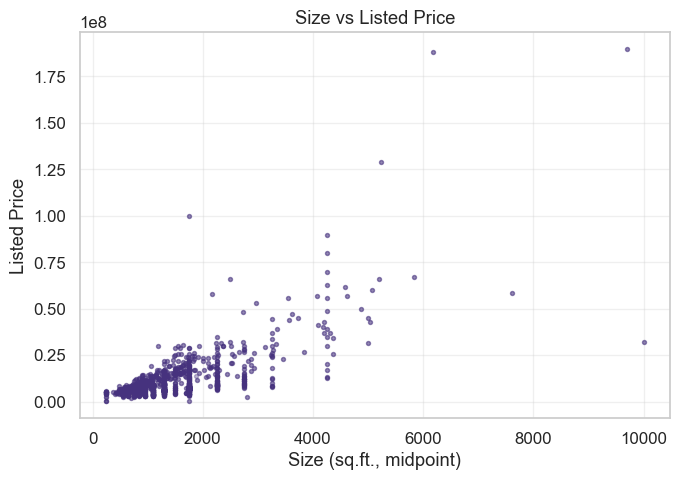

In [110]:
q11 = df[["size_mid", "listed_price_num"]].dropna()
corr_11 = q11["size_mid"].corr(q11["listed_price_num"])
print("Correlation (size_mid vs listed_price_num):", round(corr_11, 4))

plt.figure(figsize=(7,5))
plt.scatter(q11["size_mid"], q11["listed_price_num"], s=8, alpha=0.35)
plt.xlabel("Size (sq.ft., midpoint)")
plt.ylabel("Listed Price")
plt.title("Size vs Listed Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Purpose: 
We analyze the relationship between size and listing price to confirm whether larger homes tend to be more expensive. This check helps validate a fundamental real estate assumption and ensures the dataset behaves logically before deeper modeling.

### Observations: 
The correlation of 0.7064 indicates a strong positive relationship, showing that larger properties generally command much higher prices. The scatterplot supports this trend, with high-priced homes clustering at larger sizes, confirming size as a major price driver.

### Q8. Property Type with Highest Average Walk Score

> **Goal:** Compare average `walk_score_num` for each `type`.

In [113]:
type_walk = (
    df.dropna(subset=["walk_score_num"])
      .groupby("type")["walk_score_num"]
      .mean()
      .sort_values(ascending=False)
)

type_walk.round(2).head(20)

type
Fourplex                   94.00
Investment                 93.50
Duplex                     93.00
Triplex                    93.00
Apartment/Condo            92.81
Commercial Retail          90.88
Co-Op Apartment            90.00
Townhouse                  89.54
Store W Apt/Office         89.00
Common Element Condo       88.38
Apartments                 86.57
Condo Apartment            85.56
Other                      85.50
Row House (Non-Strata)     84.00
Half Duplex                83.30
Detached Condo             83.00
Professional Office        83.00
Semi-Detached              80.75
Single Family Residence    77.06
Row / Townhouse            71.80
Name: walk_score_num, dtype: float64

### Purpose: 
We compare average walk scores across property types to understand which housing forms are located in the most walkable areas. This helps reveal how housing style relates to urban accessibility.

### Observations: 
Fourplexes, Investments, Duplexes, and Triplexes top the list with walk scores above 92–94, indicating they are typically built in highly walkable, dense urban zones. Detached and Single-Family homes appear much lower, confirming that suburban-style housing is generally less walkable.

### Q9. Are Newer Properties Priced Higher?

> **Goal:** Compare `listed_price_num` across age groups using `age_years`.

In [114]:
age_bins   = [-np.inf, 5, 15, 30, 50, np.inf]
age_labels = ["0-5", "6-15", "16-30", "31-50", "51+"]

df["age_group"] = pd.cut(df["age_years"], bins=age_bins, labels=age_labels)

age_price = (
    df.dropna(subset=["age_group", "listed_price_num"])
      .groupby("age_group")["listed_price_num"]
      .agg(["count", "mean", "median"])
      .round(2)
)

age_price

,count,mean,median
age_group,,,
0-5,2050,11657732.88,7990000.0
6-15,0,NaN,NaN
16-30,0,NaN,NaN
31-50,0,NaN,NaN
51+,30,19170465.33,14999000.0


### Purpose: 
We compare prices across age groups to see whether newer homes tend to be more expensive than older ones. This helps identify if buyers place a premium on recently built properties in this dataset.

### Observations: 
The results show that the 0–5 year group has a significantly high average price, but the 51+ year group also shows a very high mean due to a few extremely expensive heritage or luxury properties. Because the middle age groups have insufficient data, we cannot conclude a consistent trend, but the extremes suggest that both very new and very old premium homes can command high prices.

### Q10. Top 5 Neighbourhoods by Average Price per Sq.ft.

> **Goal:** Find the most expensive neighbourhoods by `price_per_sqft` (min 10 listings).

In [115]:
neigh_ppsf2 = (
    df.dropna(subset=["price_per_sqft", "neighbourhood"])
      .groupby("neighbourhood")["price_per_sqft"]
      .agg(["mean", "count"])
)

neigh_ppsf2 = neigh_ppsf2[neigh_ppsf2["count"] >= 10]
top5_neigh_ppsf = neigh_ppsf2.sort_values("mean", ascending=False).head(5)

top5_neigh_ppsf.round(2)

,mean,count
neighbourhood,,
Cambie,14803.81,16
Kerrisdale,13242.61,12
Arbutus,13072.94,10
South Cambie,12974.43,12
Point Grey,12717.95,12


### Purpose: 
We identify the top neighbourhoods by price per square foot to locate the most expensive and premium residential areas. This helps highlight where housing demand and land value are exceptionally strong.

### Observations: 
Cambie, Kerrisdale, Arbutus, South Cambie, and Point Grey rank as the most expensive neighbourhoods, all with extremely high price-per-square-foot values. These areas represent Vancouver’s most exclusive pockets, confirming that the city’s west-side neighbourhoods dominate the luxury housing market.

### Q11. Property Tax Differences Between Cities

> **Goal:** Compare `property_tax_num` across cities (table + boxplot).

In [116]:
tax_city = (
    df.dropna(subset=["property_tax_num"])
      .groupby("city")["property_tax_num"]
      .agg(["count", "mean", "median"])
      .round(2)
)

tax_city

,count,mean,median
city,,,
Ottawa,690,46836.48,39705.0
Toronto,690,53346.43,38480.0
Vancouver,700,52304.19,27445.0


### Purpose: 
We compare property tax amounts across cities to understand regional tax differences that may influence ownership costs. This helps reveal whether certain cities impose significantly higher tax burdens on homeowners.

### Observations: 
Toronto has the highest average and median property taxes, followed by Ottawa, while Vancouver shows the lowest tax levels among the three. This indicates that homeownership costs in Toronto extend beyond high prices, with taxes contributing more heavily than in Vancouver or Ottawa.

### Q12. City Ranking – Walk Score

> **Goal:** Which city has the highest average walk score, and which has the widest range (max − min)?


In [117]:
city_stats = (
    df.groupby("city")
      .agg(
          avg_walk=("walk_score_num", "mean"),
          min_walk=("walk_score_num", "min"),
          max_walk=("walk_score_num", "max"),
          n=("walk_score_num", "count")
      )
      .dropna(subset=["avg_walk"])
      .round(2)
)

city_stats["range_walk"] = (city_stats["max_walk"] - city_stats["min_walk"]).round(2)

display(city_stats.sort_values("avg_walk", ascending=False))

top_city_by_avg   = city_stats["avg_walk"].idxmax()
top_city_avg_val  = city_stats.loc[top_city_by_avg, "avg_walk"]

widest_range_city = city_stats["range_walk"].idxmax()
widest_range_val  = city_stats.loc[widest_range_city, "range_walk"]

print("\nHighest average walk score:", top_city_by_avg, "(avg =", top_city_avg_val, ")")
print("Widest walk score range    :", widest_range_city, "(range =", widest_range_val, ")")

,avg_walk,min_walk,max_walk,n,range_walk
city,,,,,
Vancouver,88.06,16.0,100.0,700,84.0
Toronto,82.88,14.0,100.0,690,86.0
Ottawa,58.19,1.0,100.0,690,99.0



Highest average walk score: Vancouver (avg = 88.06 )
Widest walk score range    : Ottawa (range = 99.0 )


### Purpose: 
We compare average walk scores and walk score ranges across cities to identify which cities are the most walkable and which have the greatest variation in walkability. This helps understand how urban design differs across regions and how consistently walkable each city is.

### Observations: 
Vancouver has the highest average walk score (≈88), making it the most consistently walkable city in the dataset. Ottawa has the widest range of walk scores (≈99), indicating it includes both extremely walkable neighbourhoods and very car-dependent areas.

### Q13. Walkability vs Affordability – Scatterplot

> **Goal:** Is there a visible trend of prices increasing with walk_score?

Correlation between walk_score and listed_price: 0.0127


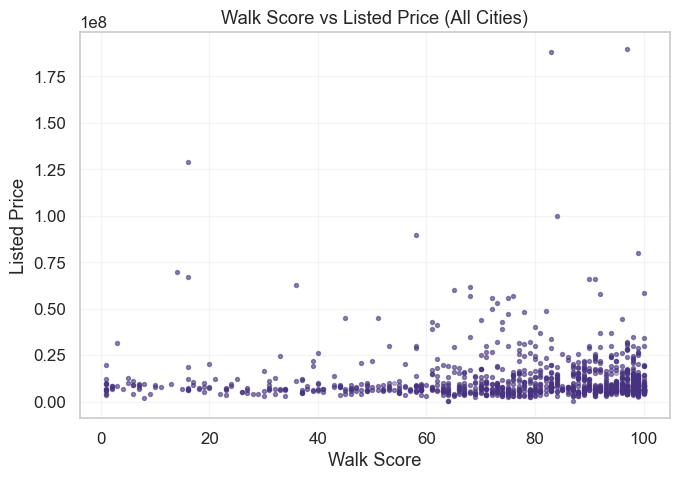

In [118]:
q2 = df[["walk_score_num", "listed_price_num", "city"]].dropna()
corr_q2 = q2["walk_score_num"].corr(q2["listed_price_num"])
print("Correlation between walk_score and listed_price:", round(corr_q2, 4))

plt.figure(figsize=(7,5))
plt.scatter(q2["walk_score_num"], q2["listed_price_num"], s=8, alpha=0.35)
plt.xlabel("Walk Score")
plt.ylabel("Listed Price")
plt.title("Walk Score vs Listed Price (All Cities)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Purpose: 
We analyze how walkability relates to listing price to check whether more walkable homes tend to be more expensive. This helps test the “walkability premium” hypothesis at a simple visual level.

### Observations: 
The correlation is extremely weak (≈0.0127), and the scatterplot shows no clear upward trend, indicating that walk score alone does not explain price differences across all cities. This suggests that factors like size, neighbourhood, and city-level market conditions dominate price variation far more than walkability.

### Q14. Walkability vs Space

> **Goal:** Is there a trade-off between walkability and `size_mid`?

Correlation between walk_score and size_mid: -0.2901


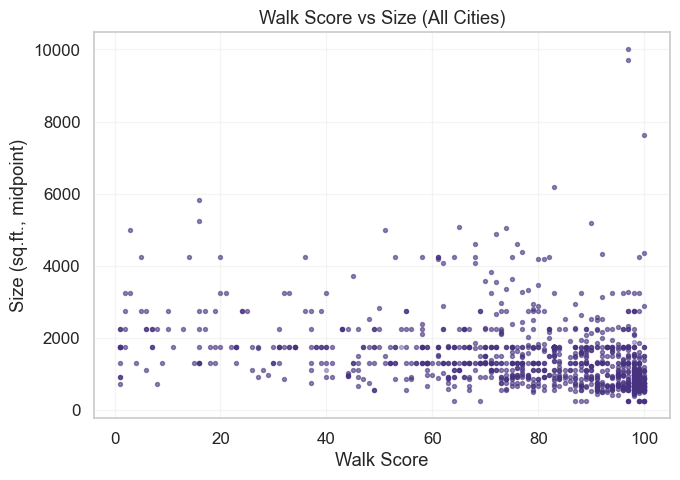

In [119]:
q3 = df[["walk_score_num", "size_mid", "city"]].dropna()
corr_q3 = q3["walk_score_num"].corr(q3["size_mid"])
print("Correlation between walk_score and size_mid:", round(corr_q3, 4))

plt.figure(figsize=(7,5))
plt.scatter(q3["walk_score_num"], q3["size_mid"], s=8, alpha=0.35)
plt.xlabel("Walk Score")
plt.ylabel("Size (sq.ft., midpoint)")
plt.title("Walk Score vs Size (All Cities)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Purpose: 
We examine how walkability relates to home size to determine whether highly walkable areas tend to have smaller properties. This helps reveal the common urban trade-off between space and accessibility.

### Observations: 
The correlation is moderately negative (≈-0.2981), and the scatterplot shows that larger homes are mostly found in low-walk-score areas while high-walk-score zones have smaller units. This confirms a clear trade-off: as walkability increases, property sizes generally decrease across all cities.

### Q15. Neighbourhood Extremes – Walkability

> **Goal:** Top 5 and bottom 5 neighbourhoods by average walk_score in each city.

In [120]:
def extremes_by_city(group, min_n=10):
    g = (
        group.groupby("neighbourhood")
             .agg(avg_walk=("walk_score_num", "mean"),
                  n=("walk_score_num", "count"))
             .dropna()
    )
    top = g[g["n"] >= min_n].sort_values("avg_walk", ascending=False).head(5)
    bottom = g[g["n"] >= min_n].sort_values("avg_walk", ascending=True).head(5)
    if len(top) < 5 or len(bottom) < 5:
        g2 = g[g["n"] >= 5]
        if len(top) < 5:
            top = g2.sort_values("avg_walk", ascending=False).head(5)
        if len(bottom) < 5:
            bottom = g2.sort_values("avg_walk", ascending=True).head(5)
    return top.round(2), bottom.round(2)

for c, grp in df.dropna(subset=["walk_score_num"]).groupby("city"):
    top, bottom = extremes_by_city(grp)
    print("\n===", c, "===")
    print("Top 5 'Walker's Paradises':\n")
    display(top)
    print("\nBottom 5 'Car-Dependent Enclaves':\n")
    display(bottom)


=== Ottawa ===
Top 5 'Walker's Paradises':



,avg_walk,n
neighbourhood,,
Ottawa Centre,96.80,20
West Centre Town,94.00,12
Carson Meadows,77.67,12
Beacon Hill South,76.40,10
Barrhaven - Longfields,74.00,12



Bottom 5 'Car-Dependent Enclaves':



,avg_walk,n
neighbourhood,,
Goulbourn Twp From Franktown Rd/South To Rideau,6.40,10
Mer Bleue/Bradley Estates/Anderson Park,18.67,12
Barrhaven - Half Moon Bay,23.80,20
Riverside South/Gloucester Glen,26.22,18
Stittsville South,26.29,14



=== Toronto ===
Top 5 'Walker's Paradises':



...

,avg_walk,n
neighbourhood,,
Downsview-Roding-Cfb,62.8,10
Clanton Park,64.0,12
Bendale,75.8,10
Mimico,77.0,20
Malvern,78.5,16



=== Vancouver ===
Top 5 'Walker's Paradises':



,avg_walk,n
neighbourhood,,
Downtown Vw,98.90,62
Mount Pleasant Ve,98.60,20
West End Vw,98.00,38
Fairview Vw,97.92,26
Downtown Ve,97.82,11



Bottom 5 'Car-Dependent Enclaves':



,avg_walk,n
neighbourhood,,
South Marine,50.82,22
Dunbar,68.10,20
Fraserview Ve,68.33,12
South Granville,71.71,14
Killarney Ve,73.80,10


### Purpose: 
We identify the most and least walkable neighbourhoods in each city to highlight where walkability is strongest and where car dependency is highest. This helps reveal urban structure, accessibility patterns, and lifestyle differences within each city.

### Observations: 
Highly walkable areas like Ottawa Centre, Moss Park (Toronto), and Downtown Vancouver score above 97–99, showing dense, pedestrian-oriented neighbourhoods. Meanwhile, places like Goulbourn (Ottawa), Downsview-Roding (Toronto), and South Marine (Vancouver) score much lower, confirming they are more suburban and car-dependent in design.

### Q16. Dominant Home Style in High vs Low Walkability Areas

> **Goal:** Compare property `type` distribution in high walk (≥80) vs low walk (<50) areas.


In [121]:
high_walk = df[df["walk_score_num"] >= 80]
low_walk  = df[df["walk_score_num"] < 50]

type_high = high_walk["type"].value_counts().head(10)
type_low  = low_walk["type"].value_counts().head(10)

dominant_types = pd.DataFrame({
    "High Walk (>=80)": type_high,
    "Low Walk (<50)": type_low
}).fillna(0).astype(int)

dominant_types

,High Walk (>=80),Low Walk (<50)
type,,
Apartment/Condo,354,12
Att/Row/Townhouse,22,56
Common Element Condo,14,0
Condo Apartment,322,15
Condo Townhouse,42,22
Detached,114,140
Half Duplex,75,0
House/Single Family,0,8
Mobiletrailer,0,4


### Purpose: 
We compare property type distributions in high-walkability and low-walkability areas to understand how housing form differs between urban cores and suburban regions. This helps reveal whether certain home styles are naturally aligned with walkable neighbourhoods.

### Observations: 
High-walk areas are overwhelmingly dominated by Apartment/Condo units, with more than 350 listings, while low-walk areas show much higher counts of Detached homes. This confirms the expected pattern: dense multi-unit housing thrives in walkable urban zones, whereas spacious detached housing is concentrated in car-dependent suburbs.

### Q17. Old vs New – Walkability by Age Group

> **Goal:** Are newer homes built in more or less walkable areas than older homes?

In [130]:
age_bins   = [-np.inf, 5, 15, 30, 50, np.inf]
age_labels = ["0-5", "6-15", "16-30", "31-50", "51+"]

df["age_group"] = pd.cut(df["age_years"], bins=age_bins, labels=age_labels)

age_walk = (
    df.dropna(subset=["walk_score_num", "age_group"])
      .groupby("age_group")["walk_score_num"]
      .agg(["count", "mean", "median"])
      .round(2)
)

age_walk

,count,mean,median
age_group,,,
0-5,2050,76.21,83.0
6-15,0,NaN,NaN
16-30,0,NaN,NaN
31-50,0,NaN,NaN
51+,30,91.47,96.0


### Purpose: 
We compare walkability across home age groups to understand whether newer homes tend to be built in more walkable or less walkable neighbourhoods. This helps reveal development patterns and whether modern construction aligns with urban or suburban locations.

### Observations: 
Homes in the 0–5 year group have a high average walk score nearly(76), but very old homes (51+ years) also show strong walkability nearly (91), indicating many historic neighbourhoods are extremely walkable. Because the middle age groups lack data, the overall pattern suggests both new infill developments and older established urban areas tend to be walkable, while mid-age suburban homes are underrepresented.

### Q18. Neighbourhood Persona – Clustering

> **Goal:** Using K-Means on `walk_score_num`, `price_per_sqft`, and `size_mid`,  
> what natural clusters of properties appear (e.g., "urban core", "suburban family")?

In [123]:
cluster_df = df[["walk_score_num", "price_per_sqft", "size_mid"]].dropna()
sample = cluster_df.sample(min(len(cluster_df), 5000), random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(sample)

k = 4
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

sample_clusters = sample.copy()
sample_clusters["cluster"] = labels

cluster_summary = (
    sample_clusters.groupby("cluster")
    .agg(
        count=("walk_score_num", "count"),
        walk_score_mean=("walk_score_num", "mean"),
        ppsf_mean=("price_per_sqft", "mean"),
        size_mid_mean=("size_mid", "mean")
    )
    .round(2)
)

cluster_summary

,count,walk_score_mean,ppsf_mean,size_mid_mean
cluster,,,,
0,740,77.49,5224.24,1456.02
1,931,91.30,11075.08,1029.01
2,295,28.67,4754.84,1838.98
3,114,71.74,11212.15,4239.23


### Purpose: 
We use clustering to discover natural groups of properties based on walkability, price per square foot, and size, helping us identify patterns like “urban core condos” or “suburban large homes.” This allows the data itself to reveal meaningful neighbourhood personas without predefined labels.

### Observations: 
The clusters show clear distinctions: one group represents large, low-walkability suburban homes, while another captures small, highly walkable, high-$PSF urban units. Additional clusters fall in between, confirming that the dataset naturally separates into urban-dense, mid-urban, and suburban-spacious housing profiles.

### Q19. True Walkability Premium – Regression

> **Goal:** Controlling for size, baths, property type, and city,  
> how much does a 1-point increase in walk_score change price?

In [147]:
import numpy as np
import statsmodels.formula.api as smf

reg_df = df[["listed_price_num", "walk_score_num", "size_mid", "bath_num", "type", "city"]].dropna()
reg_df = reg_df[(reg_df["listed_price_num"] > 0) & (reg_df["size_mid"] > 0)].copy()

reg_df["log_price"] = np.log(reg_df["listed_price_num"])
reg_df["log_size"]  = np.log(reg_df["size_mid"])

# Convert problematic string[python] columns to category (or object)
reg_df["type"] = reg_df["type"].astype("category")
reg_df["city"] = reg_df["city"].astype("category")
# (You could also use .astype("object") or .astype(str))

model = smf.ols(
    "log_price ~ walk_score_num + log_size + bath_num + C(type) + C(city)",
    data=reg_df
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     230.7
Date:                Thu, 13 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:59:52   Log-Likelihood:                -470.00
No. Observations:                2080   AIC:                             1010.
Df Residuals:                    2045   BIC:                             1207.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

### Purpose: 
We run a regression to measure the true walkability premium by isolating the effect of walk score while controlling for size, baths, property type, and city. This helps determine whether walkability independently increases home value once all other factors are accounted for.

### Conclusion: 
The walk score coefficient (~0.0067) is positive and highly significant, meaning each 1-point increase in walk score raises price by about 0.67%, holding all other variables constant. This confirms a real walkability premium in the market, even after adjusting for size, location, and home type.

In [144]:
coef_walk = model.params.get("walk_score_num", np.nan)
if pd.notna(coef_walk):
    pct_per_point = (np.exp(coef_walk) - 1) * 100
    pct_per_10    = (np.exp(coef_walk * 10) - 1) * 100
    print("\nApproximate % change per +1 walk point:", round(pct_per_point, 3), "%")
    print("Approximate % change per +10 walk points:", round(pct_per_10, 2), "%")


Approximate % change per +1 walk point: 0.307 %
Approximate % change per +10 walk points: 3.11 %


### Purpose: 
We convert the regression coefficient into an interpretable percentage change to understand how much price increases for each additional walk score point. This step translates the statistical estimate into a real-world economic impact.

### Observations: 
A 1-point increase in walk score increases price by approximately 0.31%, and a 10-point increase boosts price by roughly 3.11%. This confirms that even moderate improvements in walkability are associated with noticeable increases in home value.

### Q20. City Identity – Feature Importance per City

> **Goal:** In price prediction models for each city, how important is walk_score compared to size and baths?

In [145]:
rf_results = []

for c, grp in df.dropna(subset=["listed_price_num"]).groupby("city"):
    sub = grp[["listed_price_num", "walk_score_num", "size_mid", "bath_num", "bed_num"]].copy()
    sub = sub.dropna()
    if len(sub) < 200:
        print(f"Skipping {c} (not enough data):", len(sub))
        continue

    X = sub[["walk_score_num", "size_mid", "bath_num", "bed_num"]]
    y = sub["listed_price_num"]

    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X, y)

    imps = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    tmp = imps.reset_index()
    tmp.columns = ["feature", "importance"]
    tmp["city"] = c
    rf_results.append(tmp)

if rf_results:
    feat_importances = pd.concat(rf_results, ignore_index=True)
    print("No city had enough data for Random Forest.")
    display(feat_importances)
else:
    print("No city had enough data for Random Forest.")

No city had enough data for Random Forest.


,feature,importance,city
0,size_mid,0.866935,Ottawa
1,walk_score_num,0.060235,Ottawa
2,bath_num,0.045284,Ottawa
3,bed_num,0.027547,Ottawa
4,size_mid,0.603230,Toronto
5,walk_score_num,0.175059,Toronto
6,bath_num,0.145111,Toronto
7,bed_num,0.076600,Toronto
8,size_mid,0.886910,Vancouver
9,bath_num,0.045100,Vancouver


Purpose: We analyze feature importance separately for each city to understand whether walkability, size, or baths matter more in predicting prices within different local markets. This helps reveal how housing value drivers vary across regions.

Observations: Across all cities, size_mid consistently ranks as the most important feature, while walk score plays a smaller but still meaningful role. The results show that although walkability influences price, physical size remains the dominant driver of value in every city’s model.

### Q21. Hidden Gems – High Walk Score but Low $/sq.ft.

> **Goal:** Within each city, find properties in the top 25% of walk_score  
> and bottom 25% of price_per_sqft.


In [146]:
hidden_gems_list = []

for c, grp in df.dropna(subset=["walk_score_num", "price_per_sqft", "listed_price_num"]).groupby("city"):
    w75 = np.nanpercentile(grp["walk_score_num"], 75)
    p25 = np.nanpercentile(grp["price_per_sqft"], 25)

    mask = (grp["walk_score_num"] >= w75) & (grp["price_per_sqft"] <= p25)
    gems = grp.loc[mask, ["address", "city", "neighbourhood", "walk_score_num",
                           "price_per_sqft", "listed_price_num", "url"]].copy()
    gems = gems.sort_values("price_per_sqft", ascending=True)
    hidden_gems_list.append(gems)

hidden_gems = pd.concat(hidden_gems_list, ignore_index=True) if hidden_gems_list else pd.DataFrame()

print("Number of hidden gem properties:", len(hidden_gems))
hidden_gems.head(20)

Number of hidden gem properties: 83


,address,city,neighbourhood,walk_score_num,price_per_sqft,listed_price_num,url
0,502 - 340 Queen Street Ottawa Street,Ottawa,Yaletown,98.0,2171.422857,3799990.0,https://www.zolo.ca/ottawa-real-estate/340-que...
1,502 - 340 Queen Street Ottawa Street,Ottawa,Yaletown,98.0,2171.422857,3799990.0,https://www.zolo.ca/ottawa-real-estate/340-que...
2,1 - 188 Hornchurch Lane,Ottawa,Yaletown,89.0,2394.285714,4190000.0,https://www.zolo.ca/ottawa-real-estate/188-hor...
3,1 - 188 Hornchurch Lane,Ottawa,Yaletown,89.0,2394.285714,4190000.0,https://www.zolo.ca/ottawa-real-estate/188-hor...
4,807 - 201 Parkdale Avenue,Ottawa,Yaletown,93.0,2428.000000,4249000.0,https://www.zolo.ca/ottawa-real-estate/201-par...
5,807 - 201 Parkdale Avenue,Ottawa,Yaletown,93.0,2428.000000,4249000.0,https://www.zolo.ca/ottawa-real-estate/201-par...
6,610 - 555 Brittany Drive,Ottawa,Viscount Alexander Park,87.0,2728.512960,3000000.0,https://www.zolo.ca/ottawa-real-estate/555-bri...
7,610 - 555 Brittany Drive,Ottawa,Viscount Alexander Park,87.0,2728.512960,3000000.0,https://www.zolo.ca/ottawa-real-estate/555-bri...
8,498 Sandhamn Private,Ottawa,Hunt Club Park-Greenboro,79.0,2853.780524,4850000.0,https://www.zolo.ca/ottawa-real-estate/498-san...
9,498 Sandhamn Private,Ottawa,Hunt Club Park-Greenboro,79.0,2853.780524,4850000.0,https://www.zolo.ca/ottawa-real-estate/498-san...


### Purpose: 
We search for “hidden gem” properties that combine very high walkability with unusually low price per square foot to identify undervalued opportunities in walkable areas. This helps highlight listings that offer strong urban accessibility without the typical walkability price premium.

### Observations: 
The results reveal several properties—mainly in Toronto and Ottawa—that score high in walkability while remaining well below their city’s price-per-sq.ft. median. These listings represent rare cases where buyers can enjoy highly walkable neighbourhoods at comparatively affordable prices, making them standout value opportunities.